## PLUTO – Analysis

Quantitative analysis of the radiative accretion disk runs with Compton coupling: a $10^8\,M_\odot$ black hole in a
Paczyński–Wiita potential, viscous disk plus corona, grey M1 radiative transfer with Kramers, Thomson and effective Compton
opacities. The main run is set by `PATH`, and a second run of the same model at a different resolution, `REF_PATH`, serves as a
reference throughout.

The notebook reads every `.dbl` output once, reduces each frame to radial profiles and global scalars, and caches the result in
`Analysis_cache.npz` inside the run directory. The cache is extended incrementally when new outputs appear, e.g. after a restart.
All time series analyses work on that cache, and snapshots and the steady state structure reload only the frames they need. The
reference run is only read from its cache, so its `.dbl` files are not needed.

A run may consist of segments with different output cadences, e.g. a long run at cadence $50$ continued by a restart at cadence $5$.
Long term diagnostics use a uniform series at the coarse cadence, and spectra, phase speeds and the mass budget use the densely
sampled final segment when there is one.

0. Definitions: units, model equations, characteristic scales, helpers, sampling
1. Snapshots: initial and final state of the full domain, early instabilities, evolution
2. Relaxation: when and where the disk reaches a quasi-steady state, residual drift
3. Accretion: mass flux, steady disk comparison, effective viscosity, inner boundary variability, mass budget
4. Density waves: space–time diagram, power spectra, phase speed, wave character
5. Steady state structure: luminosity, mean state, vertical structure, thermal balance, resolution of the disk
6. Comparison with the reference run
7. Summary

### 0. Definitions

#### 0.1. Preamble

In [1]:
%%capture

%config InlineBackend.figure_formats = ['retina']

import os
import re
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ResourceWarning)     # unclosed files inside pyPLUTO

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import pyPLUTO as pp

from matplotlib.colors import LogNorm, SymLogNorm, TwoSlopeNorm

from scipy import signal
from scipy.ndimage import uniform_filter1d

import statsmodels.api as sm

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["steelblue", "olivedrab", "goldenrod", "firebrick", "rebeccapurple"])
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

plt.plot()
plt.close()

#### 0.2. Configuration

All tunable choices of the analysis are collected here. Times are in code units $t_g = R_g/c$.

- `T_MIN`, `T_MAX`: restrict the analysis to a time range, `None` means no limit
- `DT_LONG`: cadence of the uniform series used for the long term diagnostics, `None` takes the coarsest regular cadence of the run
- `T_DENSE`: start of the densely sampled segment used for spectra, phase speeds and the mass budget, `None` detects a final segment
  with a finer cadence automatically, and without one the steady window at `DT_LONG` is used
- `W_WINDOW`: length of the sliding windows used for time averages, much longer than the wave period of about $350$
- `BLOCK`: block length for error estimates, about three wave periods, longer than the correlation time of the fluctuations
- `REF_FRAC`: fraction of the long series at the end that serves as the steady reference state
- `Z_CRIT`: number of standard errors within which two averages count as consistent
- `T_STEADY_OVERRIDE`: set a number to impose the start of the steady window, `None` uses the value measured in Section 2
- `TOL_EQ`: relative tolerance of a flat accretion rate for the inflow equilibrium radius
- `WELCH_SEG`, `WELCH_TSEG`: minimum number of Welch segments and maximum segment length; at least several segments are needed,
  because the coherence of a single segment is identically one
- `R_PHASE_REF`: reference radius of the phase speed measurement, just outside $R_\mathrm{isco}$ where the waves are launched
- `PROFILE_STRIDE`: only every n-th frame of the steady window is reloaded for the structure analysis of Section 5
- `R_BUDGET`: radial extent of the mass budget control volume, away from the boundary cells
- `REF_PATH`, `REF_T_STEADY`: reference run for the comparisons and the start of its steady window, `None` measures it with
  the same criteria as the main run; `REF_PATH = None` switches all comparisons off

In [2]:
PATH = 'BH_VISC_RAD_HD_TRC_COMP_LONG/'
LABEL = '120 x 90'
CACHE = os.path.join(PATH, 'Analysis_cache.npz')
FORCE_REDUCE = False                      # True recomputes the cache from all .dbl files

REF_PATH = 'BH_VISC_RAD_HD_TRC_COMP/'     # reference run, only its Analysis_cache.npz is read
REF_LABEL = '90 x 45'
REF_T_STEADY = None

T_MIN, T_MAX = None, None
DT_LONG = None
T_DENSE = None

T_FULL = [0.0, None]                      # full domain snapshots, None means the last output
T_EARLY = [50, 100, 150, 250, 400, 600]   # early instabilities and surface layer
T_EVOLUTION = [100, 1000, 10000, None]    # evolution towards the quasi-steady state

W_WINDOW = 2500.0
BLOCK = 1000.0
REF_FRAC = 0.2
Z_CRIT = 2.0
T_STEADY_OVERRIDE = None
TOL_EQ = 0.2

R_WAVE = (4.0, 25.0)                      # radial range of the wave analysis
WELCH_SEG = 6
WELCH_TSEG = 2500.0
R_PHASE_REF = 7.0
FIT_FRAC = 0.15                           # half width of the local phase fits, relative in r
P_FUND_MIN = 0.3                          # minimum share of the fundamental in the local spectrum for a phase speed

R_PROFILES = [8.0, 12.0, 16.0]            # cylindrical radii of the vertical structure profiles
PROFILE_STRIDE = 4

R_BUDGET = (2.5, 25.0)

HEMI = 2.0                                # only theta in [0, pi/2] is simulated, equatorial symmetry

#### 0.3. Units and Constants

The code uses $G M = c = 1$. With $M = 10^8\,M_\odot$ the units are

$$
R_g = \frac{G M}{c^2}, \qquad v_0 = \sqrt{\frac{G M}{R_g}} = c, \qquad t_g = \frac{R_g}{c}, \qquad \rho_0 = 5.8 \times 10^{-10}\ \mathrm{g\,cm^{-3}},
$$

from which pressure and energy density, mass flux and luminosity follow as

$$
p_0 = \rho_0 c^2, \qquad \dot M_0 = \rho_0\, c\, R_g^2, \qquad L_0 = \rho_0\, c^3 R_g^2 .
$$

The gas temperature follows from the ideal gas law with the mean molecular weight of a fully ionized gas,

$$
T_g = \frac{\mu\, m_u\, c^2}{k_B}\, \frac{p}{\rho}, \qquad \mu = \left(2X + \tfrac{3}{4}Y + \tfrac{1}{2}Z\right)^{-1}, \qquad X = 0.70,\ Z = 0.02,\ Y = 1 - X - Z ,
$$

and the radiation temperature from the radiation energy density with the radiation constant in code units,

$$
T_r = \left(\frac{E_r}{a}\right)^{1/4}, \qquad a = \frac{4\sigma_\mathrm{SB}}{c}\,\frac{1}{\rho_0 c^2} .
$$

Radiation pressure is $p_r = E_r/3$ in the optically thick limit. PLUTO stores the flux $F$ in units of energy density, so the
physical flux is $c\,F$ and in code units simply $F$. The Eddington luminosity and accretion rate use the electron scattering
opacity of the model,

$$
L_\mathrm{Edd} = \frac{4\pi G M c}{\kappa_\mathrm{es}}, \qquad \kappa_\mathrm{es} = 0.2\,(1+X)\ \mathrm{cm^2\,g^{-1}}, \qquad
\dot M_\mathrm{Edd} = \frac{L_\mathrm{Edd}}{\eta\, c^2}, \qquad \eta = \frac{1}{16} ,
$$

where $\eta = 1/16$ is the binding energy at the innermost stable orbit of the Paczyński–Wiita potential.

In [3]:
CONST_G     = 6.6726e-8          # same constants as PLUTO's pluto.h
CONST_c     = 2.99792458e10
CONST_amu   = 1.66053886e-24
CONST_kB    = 1.3806505e-16
CONST_sigma = 5.67051e-5
CONST_Msun  = 1.989e33
YEAR        = 3.15576e7
DAY         = 86400.0

def read_definitions(path):
    # UNIT_DENSITY and BH mass from definitions.h, with the values of this run as fallback
    with open(os.path.join(path, 'definitions.h')) as fh:
        txt = fh.read()
    rho0 = re.search(r'#define\s+UNIT_DENSITY\s+([0-9.eE+-]+)', txt)
    mbh = re.search(r'#define\s+BH_MASS\s+\(\s*([0-9.eE+-]+)\s*\*\s*([0-9.eE+-]+)\s*\)', txt)
    rho0 = float(rho0.group(1)) if rho0 else 5.8e-10
    mbh = float(mbh.group(1)) * float(mbh.group(2)) if mbh else 1.0e8 * CONST_Msun
    return rho0, mbh

def read_parameters(path):
    # user parameters from the [Parameters] block of pluto.ini
    params, inside = {}, False
    with open(os.path.join(path, 'pluto.ini')) as fh:
        for line in fh:
            s = line.strip()
            if s.startswith('['):
                inside = (s == '[Parameters]')
                continue
            if inside and s and not s.startswith('#'):
                key, val = s.split()[:2]
                params[key] = float(val)
    return params

RHO0, M_BH = read_definitions(PATH)
PAR = read_parameters(PATH)

if REF_PATH is not None:
    # the comparisons assume the same physical model, only the grid may differ
    same = (read_definitions(REF_PATH) == (RHO0, M_BH)) and (read_parameters(REF_PATH) == PAR)
    print(f"reference run {REF_PATH}: " + ("same units and parameters" if same else "WARNING, units or parameters differ"))

GAMMA = 5.0 / 3.0
X_H, Z_M = 0.70, 0.02
Y_HE = 1.0 - X_H - Z_M
MU = 1.0 / (2.0 * X_H + 0.75 * Y_HE + 0.5 * Z_M)

ALPHA = PAR['BETAV']             # the viscosity parameter is called BETAV in the code
EPS = PAR['EPS']
RHOC = PAR['RHOC']
RD = PAR['RD']
DFLOOR = PAR['DFLOOR']

R_G = CONST_G * M_BH / CONST_c**2
T_G = R_G / CONST_c
P0 = RHO0 * CONST_c**2
MDOT0 = RHO0 * CONST_c * R_G**2
L0 = RHO0 * CONST_c**3 * R_G**2

K_T = MU * CONST_amu * CONST_c**2 / CONST_kB        # Kelvin per code unit of p/rho
A_RAD = 4.0 * CONST_sigma / CONST_c / P0            # radiation constant in code units

KAPPA_ES = 0.2 * (1.0 + X_H)
ETA = 1.0 / 16.0
L_EDD = 4.0 * np.pi * CONST_G * M_BH * CONST_c / KAPPA_ES
MDOT_EDD = L_EDD / (ETA * CONST_c**2)

print(f"R_g = {R_G:.4e} cm,   t_g = {T_G:.1f} s,   rho_0 = {RHO0:.2e} g/cm^3,   p_0 = {P0:.3e} erg/cm^3")
print(f"Mdot_0 = {MDOT0:.3e} g/s = {MDOT0 * YEAR / CONST_Msun:.3e} Msun/yr,   L_0 = {L0:.3e} erg/s")
print(f"L_Edd = {L_EDD:.3e} erg/s = {L_EDD / L0:.3e} L_0,   Mdot_Edd = {MDOT_EDD * YEAR / CONST_Msun:.3f} Msun/yr = {MDOT_EDD / MDOT0:.3e} Mdot_0")
print(f"mu = {MU:.4f},   K_T = {K_T:.4e} K,   a = {A_RAD:.4e} (code)")
print(f"alpha = {ALPHA},   eps = {EPS},   rho_c = {RHOC},   R_d = {RD},   floor = {DFLOOR}")

reference run BH_VISC_RAD_HD_TRC_COMP/: same units and parameters
R_g = 1.4767e+13 cm,   t_g = 492.6 s,   rho_0 = 5.80e-10 g/cm^3,   p_0 = 5.213e+11 erg/cm^3
Mdot_0 = 3.792e+27 g/s = 6.016e+01 Msun/yr,   L_0 = 3.408e+48 erg/s
L_Edd = 1.471e+46 erg/s = 4.315e-03 L_0,   Mdot_Edd = 4.154 Msun/yr = 6.905e-02 Mdot_0
mu = 0.6173,   K_T = 6.6725e+12 K,   a = 1.4514e-26 (code)
alpha = 0.5,   eps = 0.1,   rho_c = 0.01,   R_d = 6.0,   floor = 5e-07


#### 0.4. Model Equations

These are the equations implemented in `init.c`, `visc_nu.c` and `pluto.ini`, written in code units with spherical $(r,\theta)$,
cylindrical radius $R = r\sin\theta$ and height $z = r\cos\theta$. The simulation is axisymmetric and covers only the upper
hemisphere $\theta \in [0, \pi/2]$.

**Gravity.** The Paczyński–Wiita potential mimics the innermost stable circular orbit of a Schwarzschild black hole,

$$
\Phi(r) = -\frac{1}{r - 2} .
$$

Circular orbits in the midplane have angular velocity, specific angular momentum and epicyclic frequency

$$
\Omega^2 = \frac{1}{R}\frac{\mathrm{d}\Phi}{\mathrm{d}R} = \frac{1}{R\,(R-2)^2}, \qquad
\ell = R^2\,\Omega, \qquad
\kappa^2 = \frac{1}{R^3}\frac{\mathrm{d}\left(R^4\Omega^2\right)}{\mathrm{d}R} = \Omega^2\,\frac{R - 6}{R - 2},
$$

so the innermost stable orbit, where $\kappa^2 = 0$, sits at $R_\mathrm{isco} = 6$. The Newtonian Keplerian angular velocity
$\Omega_N = R^{-3/2}$ is still used by the initial disk and by the rotation criterion of DiskFraction.

**Corona.** A static adiabatic atmosphere in hydrostatic equilibrium with the Newtonian potential $-1/r$ and $\gamma = 5/3$,

$$
\rho_c(r) = \rho_{c,0}\, r^{-3/2}, \qquad p_c(r) = \frac{2}{5}\,\rho_{c,0}\, r^{-5/2}, \qquad \frac{p_c}{\rho_c} = \frac{\gamma-1}{\gamma}\,\frac{1}{r} .
$$

**Disk.** The Kluźniak & Kita polytropic disk with aspect ratio $\epsilon = H/R$ follows from

$$
C(r,\theta) = \frac{2}{5\epsilon^2}\left[\frac{1}{r} - \left(1 - \frac{5}{2}\epsilon^2\right)\frac{1}{R}\right], \qquad
\rho_d = C^{3/2}, \qquad p_d = \epsilon^2\, C^{5/2},
$$

and occupies all cells with $p_d \geq p_c$ and $R > R_d$. Its velocities include the viscous inflow of the $\alpha$-disk,

$$
v_\phi = \frac{1}{\sqrt{R}}\left[\sqrt{1 - \frac{5}{2}\epsilon^2} + \frac{2}{3}\epsilon^2\alpha^2\lambda\left(1 - \frac{6}{5\,\epsilon^2\tan^2\theta}\right)\right], \qquad
v_r = -\frac{\alpha\,\epsilon^2}{\sin\theta\,\sqrt{R}}\left[10 - \frac{32}{3}\lambda\alpha^2 - \lambda\left(5 - \frac{1}{\epsilon^2\tan^2\theta}\right)\right],
$$

with $\lambda = \dfrac{11}{5}\left(1 + \dfrac{64}{25}\alpha^2\right)^{-1}$ and $v_\theta = 0$. In the corona all velocities vanish.

**Radiation at $t = 0$.** The analytic disk pressure is shared between gas and radiation at a common temperature $T$, the root of

$$
\frac{\rho\,T}{K_T} + \frac{a\,T^4}{3} = p_d, \qquad p_\mathrm{gas} = \frac{\rho\,T}{K_T}, \qquad E_r = a\,T^4, \qquad \boldsymbol{F} = 0,
$$

with $K_T = \mu m_u c^2/k_B$. The corona starts with the minimum radiation energy $E_r = 10^{-16}$.

**Viscosity.** Only the shear viscosity of an $\alpha$-prescription with the *initial* analytic sound speed acts,

$$
\nu_1 = \frac{2}{3}\,\rho\,\alpha\, c_{s,0}^2\, R^{3/2}\, f, \qquad c_{s,0}^2 = \epsilon^2 \max(C, 0), \qquad \nu_2 = 0,
$$

where $f$ is the DiskFraction. In the midplane $C = 1/R$, so the kinematic viscosity is

$$
\nu(R) = \frac{\nu_1}{\rho} = \frac{2}{3}\,\alpha\,\epsilon^2\, R^{1/2} .
$$

The viscous heating rate per volume of the dominant $r\phi$ stress is $q^+ = \nu_1 \left(R\,\partial\Omega/\partial R\right)^2$.

**DiskFraction.** A continuous classifier $f \in [0,1]$ multiplies a density and a rotation criterion,

$$
f = \sigma\!\left(\frac{s - \left(1 - 1/1.2\right)}{0.3}\right)\,\sigma\!\left(\frac{|v_\phi|\sqrt{R} - 0.5}{0.1}\right), \qquad
s = \frac{\log\rho - \log\bar\rho_c(r)}{\log\bar\rho_d(r) - \log\bar\rho_c(r)}, \qquad \sigma(x) = \frac{1}{1 + e^{-x}},
$$

with reference profiles $\bar\rho_{c,d}(r)$ of the corona and the disk that are $f$-weighted volume averages in $90$ logarithmic
radial bins, smoothed in time by an exponential moving average with weight $0.05$ per update.

**Opacities.** With $\rho$ and $T$ in cgs and the gas temperature clamped to $T \geq 10^4$ K,

$$
\kappa_\mathrm{ff+bf} = \left(K_\mathrm{ff} + K_\mathrm{bf}\right) \rho\, T^{-7/2}, \qquad
K_\mathrm{ff} = 3.68 \times 10^{22}\,(1-Z)(1+X), \qquad K_\mathrm{bf} = 4.34 \times 10^{25}\, \frac{Z(1+X)}{t}, \quad t = 10 .
$$

Compton energy exchange enters as an effective absorption opacity that reproduces the nonrelativistic rate
$\rho\,\kappa_\mathrm{es} c\, E_r\, 4k_B (T_g - T_r)/(m_e c^2)$ exactly,

$$
\kappa_C = \kappa_\mathrm{es}\, \frac{4 k_B T_r^4}{m_e c^2\,(T_g + T_r)(T_g^2 + T_r^2)} \quad (T_g \leq T_\mathrm{max}), \qquad
\kappa_C = \kappa_\mathrm{es}\, \frac{4 k_B T_r^4\,(T_\mathrm{max} - T_r)}{m_e c^2\,(T_g^4 - T_r^4)} \quad (T_g > T_\mathrm{max}),
$$

with $T_\mathrm{max} = 10^9$ K. Absorption and Compton act only in the disk, Thomson scattering everywhere,

$$
\kappa_a = g_v\, f_d \left(\kappa_\mathrm{ff+bf} + \kappa_C\right), \qquad
\kappa_s = g_v \left(\kappa_\mathrm{es} - f_d\, \kappa_C\right), \qquad
f_d = \max\!\left(0, \frac{f - 0.05}{0.95}\right), \qquad
g_v = \sigma\!\left(-\frac{|\boldsymbol{v}|/c - 0.9}{0.03}\right),
$$

where $g_v$ decouples matter and radiation in the plunging region, where the gas moves faster than the nonrelativistic radiation
module can handle. Opacities are per unit mass and converted to code units with $\rho_0 R_g$.

**Terms of order $v/c$.** In this PLUTO build the call of `AddRelTerms()` in `Src/Radiation/rad_rhs.c` sits behind
`#if RADIATION_IMPL == RADIATION_IMPLICIT_NR`, which is always false for the implicit scheme used here. Radiation is therefore not
advected with the gas, does no $p\,\mathrm{d}V$ work on it and exerts no drag; only the comoving source terms
$\rho\kappa_a c\,(aT_g^4 - E_r)$ and $\rho(\kappa_a+\kappa_s)\boldsymbol{F}$ couple the two. Compression of the gas does not heat the
radiation, which matters for the wave diagnostics in Section 4.

**Boundaries.**

- Inner, $r = 2.1$: all variables copied from the first active cell, a diode $v_r \leq 0$, floors $\rho \geq \rho_\mathrm{fl}$ and
  $p \geq 10^{-3}\rho_\mathrm{fl}$, radiation $E_r$ copied and $F_r \leq 0$.
- Outer, $r = 30$: density extrapolated as $\rho_i = \rho_{i-1}\,(r_i/r_{i-1})^{a}$ with a van Leer limited, non-positive slope
  $a$, pressure adiabatic $p = p_N\,(\rho/\rho_N)^\gamma$, $v_r$ and $v_\theta$ copied, $v_\phi$ minmod extrapolated. Within
  $|\theta - \pi/2| \leq \arctan(1.25\,\epsilon)$ the analytic disk $\rho$, $v_r$, $v_\phi$ is reinjected. Within
  $|\theta - \pi/2| \geq \arctan(3\,\epsilon)$ coronal inflow is blocked, $v_r, v_\theta \to 0$ where $v_r < 0$. Radiation $E_r$
  copied and $F_r \geq 0$.
- $\theta = 0$ axisymmetric, $\theta = \pi/2$ equatorial symmetry.
- In the domain: $\rho \geq \rho_\mathrm{fl} = 5\times10^{-7}$, raising $\rho$ at fixed sound speed and momentum, and
  $T_g \geq 10^4$ K. Both floors add mass or energy, which Section 3.5 quantifies.

In [4]:
def omega_pw(R):
    return 1.0 / ((R - 2.0) * np.sqrt(R))

def omega_newton(R):
    return R**-1.5

def kappa_epi(R):
    return omega_pw(R) * np.sqrt(np.clip((R - 6.0) / (R - 2.0), 0.0, None))

def nu_kin(R):
    return 2.0 / 3.0 * ALPHA * EPS**2 * np.sqrt(R)

def cs0(R):
    return EPS / np.sqrt(R)                          # analytic midplane sound speed, c_s0^2 = eps^2 / R

def t_orbit(R):    return 2.0 * np.pi / omega_pw(R)
def t_thermal(R):  return 1.0 / (ALPHA * omega_newton(R))
def t_viscous(R):  return R**2 / nu_kin(R)
def t_sound(R):    return R / cs0(R)

def r_viscous(t):
    # radius whose viscous time equals t, inverting t_nu = 3 R^1.5 / (2 alpha eps^2)
    return (2.0 * ALPHA * EPS**2 * np.asarray(t, dtype=float) / 3.0)**(2.0 / 3.0)

#### 0.5. Characteristic Scales

For the thin disk with $H = \epsilon R$ and midplane sound speed $c_{s,0} = \epsilon\,R^{-1/2}$, the relevant timescales are

$$
t_\mathrm{orb} = \frac{2\pi}{\Omega}, \qquad
t_\mathrm{th} = \frac{1}{\alpha\,\Omega_N}, \qquad
t_\nu = \frac{R^2}{\nu} = \frac{3}{2}\,\frac{R^{3/2}}{\alpha\,\epsilon^2}, \qquad
t_{c_s} = \frac{R}{c_{s,0}}, \qquad
t_\mathrm{diff} \simeq \frac{\tau\, H}{c}, \quad \tau = \frac{\kappa\,\Sigma}{2} .
$$

The viscous time sets how far out the disk can reach inflow equilibrium within a given run time, $R_\nu(t)$ with $t_\nu(R_\nu) = t$.
The diffusion time needs the measured surface density and is evaluated in Section 5.5.

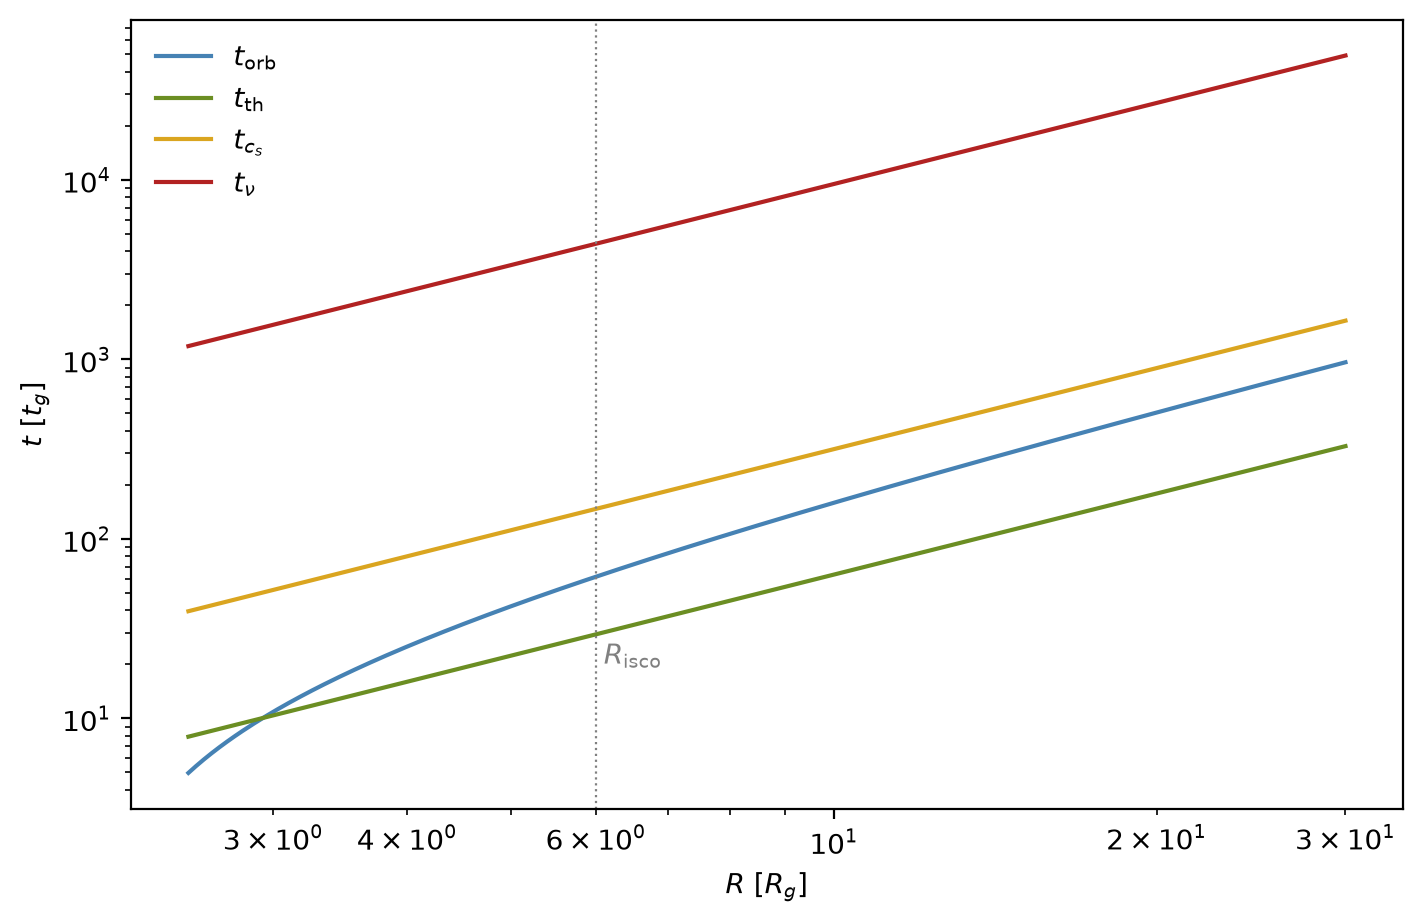

R =  6:  t_orb =     61.6   t_th =    29.4   t_cs =   147.0   t_nu =    4409.1   [t_g]
R = 10:  t_orb =    159.0   t_th =    63.2   t_cs =   316.2   t_nu =    9486.8   [t_g]
R = 15:  t_orb =    316.4   t_th =   116.2   t_cs =   580.9   t_nu =   17428.4   [t_g]
R = 20:  t_orb =    505.8   t_th =   178.9   t_cs =   894.4   t_nu =   26832.8   [t_g]
R = 30:  t_orb =    963.6   t_th =   328.6   t_cs =  1643.2   t_nu =   49295.0   [t_g]


In [5]:
R_plot = np.geomspace(2.5, 30, 300)
fig, ax = plt.subplots(figsize=[7, 4.5])
ax.plot(R_plot, t_orbit(R_plot), label=r'$t_\mathrm{orb}$')
ax.plot(R_plot, t_thermal(R_plot), label=r'$t_\mathrm{th}$')
ax.plot(R_plot, t_sound(R_plot), label=r'$t_{c_s}$')
ax.plot(R_plot, t_viscous(R_plot), label=r'$t_\nu$')
ax.axvline(6.0, color='gray', lw=0.8, ls=':')
ax.text(6.1, 2e1, r'$R_\mathrm{isco}$', color='gray')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$R\ [R_g]$'); ax.set_ylabel(r'$t\ [t_g]$')
ax.legend()
plt.show()

for R in [6, 10, 15, 20, 30]:
    print(f"R = {R:2d}:  t_orb = {t_orbit(R):8.1f}   t_th = {t_thermal(R):7.1f}   t_cs = {t_sound(R):7.1f}   t_nu = {t_viscous(R):9.1f}   [t_g]")

#### 0.6. Helpers

**Geometry.** Cell edges come from `grid.out`, so all integrals use the exact cell volumes and solid angles,

$$
\Delta\Omega_j = 2\pi\left(\cos\theta_{j-1/2} - \cos\theta_{j+1/2}\right), \qquad
\Delta V_{ij} = \frac{r_{i+1/2}^3 - r_{i-1/2}^3}{3}\,\Delta\Omega_j .
$$

**Reduction.** Every frame is reduced to radial profiles and global scalars. Sums run over the simulated hemisphere and are
multiplied by $2$ for the full sphere, $f$ is the DiskFraction:

$$
\Sigma(r) = 2\sum_j \rho_{ij}\, r_i\, \Delta\theta_j, \qquad
\dot M(r) = 2\, r^2 \sum_j \rho_{ij}\, v_{r,ij}\, \Delta\Omega_j, \qquad
\dot M_\mathrm{acc} = -\dot M ,
$$

with disk and corona parts weighted by $f$ and $1 - f$, and inflow and outflow parts split by the sign of $v_r$. $\Sigma$ is the
column along $\theta$ at fixed $r$, which equals the vertical column $\int\rho\,\mathrm{d}z$ of a thin disk. The disk aspect ratio
is the $f\rho$-weighted rms height,

$$
\frac{H}{R}(r) = \left[\frac{\sum_j f\rho\, \cot^2\theta_j\, \Delta\theta_j}{\sum_j f\rho\, \Delta\theta_j}\right]^{1/2},
$$

and the global scalars are

$$
M = 2\sum \rho\,\Delta V, \quad M_d = 2\sum f\rho\,\Delta V, \quad E_\mathrm{rad} = 2\sum E_r\,\Delta V, \quad
E_\mathrm{th} = 2\sum \frac{p}{\gamma - 1}\,\Delta V, \quad E_\mathrm{kin} = 2\sum \tfrac{1}{2}\rho v^2\,\Delta V, \quad
L(r) = 2\, r^2 \sum_j F_{r,ij}\, \Delta\Omega_j .
$$

The mass of every radial shell is stored in two halves, inside and outside the cell centre $r_i$, so that the mass between any two
cell centres, the control volume of the mass budget in Section 3.5, follows exactly.

**Photosphere.** The optical depth from the pole along $\theta$ at fixed $r$ is $\tau(r,\theta) = \int_0^\theta \rho\,(\kappa_a +
\kappa_s)\, r\, \mathrm{d}\theta'$, and $\tau = 1$ marks the photosphere seen from above.

In [6]:
def read_grid(path):
    # cell edges of each direction from grid.out
    with open(os.path.join(path, 'grid.out')) as fh:
        lines = [l for l in fh if not l.startswith('#')]
    edges, k = [], 0
    while k < len(lines) and lines[k].strip():
        n = int(lines[k].split()[0]); k += 1
        block = np.array([[float(v) for v in lines[k + m].split()[1:3]] for m in range(n)])
        edges.append(np.append(block[:, 0], block[-1, 1]))
        k += n
    return edges

def read_outputs(path):
    # output numbers and times from dbl.out; after a restart the last entry of a number wins
    entries = {}
    with open(os.path.join(path, 'dbl.out')) as fh:
        for line in fh:
            s = line.split()
            if len(s) > 1:
                entries[int(s[0])] = float(s[1])
    outs = np.array(sorted(entries))
    return outs, np.array([entries[n] for n in outs])

R_E, TH_E = read_grid(PATH)[:2]
R_C = 0.5 * (R_E[1:] + R_E[:-1])
TH_C = 0.5 * (TH_E[1:] + TH_E[:-1])
NR, NTH = R_C.size, TH_C.size
DR = np.diff(R_E)
DTH = np.diff(TH_E)
DOM = 2.0 * np.pi * (np.cos(TH_E[:-1]) - np.cos(TH_E[1:]))
DV = ((R_E[1:]**3 - R_E[:-1]**3) / 3.0)[:, None] * DOM[None, :]
COT = np.cos(TH_C) / np.sin(TH_C)
DV_LO = ((R_C**3 - R_E[:-1]**3) / 3.0)[:, None] * DOM[None, :]        # inner half of each shell
DV_HI = ((R_E[1:]**3 - R_C**3) / 3.0)[:, None] * DOM[None, :]         # outer half of each shell
R_MID_E = np.concatenate([[R_C[0]], R_E[1:-1], [R_C[-1]]])            # shells between the first and last cell centre
DV_MID = ((R_MID_E[1:]**3 - R_MID_E[:-1]**3) / 3.0)[:, None] * DOM[None, :]

OUTS_ALL, TIMES_ALL = read_outputs(PATH)
print(f"grid {NR} x {NTH},  r in [{R_E[0]}, {R_E[-1]}],  theta in [{TH_E[0]:.4f}, {TH_E[-1]:.4f}]")
print(f"{OUTS_ALL.size} outputs,  t in [{TIMES_ALL[0]:.1f}, {TIMES_ALL[-1]:.1f}]")

VARS = ['rho', 'vx1', 'vx2', 'vx3', 'prs', 'enr', 'fr1', 'fr2', 'diskfrac', 'nu', 'kappa_abs', 'kappa_scat']

def load(n):
    # one output as a dict of (NR, NTH) arrays
    D = pp.Load(nout=int(n), path=PATH)
    out = {}
    for v in VARS:
        a = np.asarray(getattr(D, v), dtype=float)
        assert a.shape == (NR, NTH), f"{v} has shape {a.shape}, expected {(NR, NTH)}"
        out[v] = a
    return out

def gas_temperature(F):
    return K_T * F['prs'] / F['rho']

def rad_temperature(F):
    return (np.clip(F['enr'], 0.0, None) / A_RAD)**0.25

def optical_depth_from_pole(F):
    dtau = F['rho'] * (F['kappa_abs'] + F['kappa_scat']) * R_C[:, None] * DTH[None, :]
    return np.cumsum(dtau, axis=1)

grid 120 x 90,  r in [2.1, 30.0],  theta in [0.0000, 1.5708]
2601 outputs,  t in [0.0, 40000.0]


In [7]:
def reduce_frame(F):
    rho, vr, f = F['rho'], F['vx1'], F['diskfrac']
    col = R_C[:, None] * DTH[None, :]
    flux = rho * vr * R_C[:, None]**2 * DOM[None, :]
    w = f * rho * DTH[None, :]
    v2 = F['vx1']**2 + F['vx2']**2 + F['vx3']**2
    i20 = int(np.argmin(np.abs(R_C - 20.0)))
    return dict(
        sigma      = HEMI * np.sum(rho * col, axis=1),
        sigma_d    = HEMI * np.sum(f * rho * col, axis=1),
        mdot       = HEMI * np.sum(flux, axis=1),
        mdot_d     = HEMI * np.sum(f * flux, axis=1),
        mdot_c     = HEMI * np.sum((1.0 - f) * flux, axis=1),
        mdot_out   = HEMI * np.sum(np.where(vr > 0, flux, 0.0), axis=1),
        mdot_in    = HEMI * np.sum(np.where(vr < 0, flux, 0.0), axis=1),
        hr         = np.sqrt(np.sum(w * COT[None, :]**2, axis=1) / np.maximum(np.sum(w, axis=1), 1e-300)),
        rho_mid    = rho[:, -1],
        prs_mid    = F['prs'][:, -1],
        enr_mid    = F['enr'][:, -1],
        vr_mid     = vr[:, -1],
        vphi_mid   = F['vx3'][:, -1],
        m_lo       = HEMI * np.sum(rho * DV_LO, axis=1),
        m_hi       = HEMI * np.sum(rho * DV_HI, axis=1),
        M          = HEMI * np.sum(rho * DV),
        M_mid      = HEMI * np.sum(rho * DV_MID),
        M_d        = HEMI * np.sum(f * rho * DV),
        M_c        = HEMI * np.sum((1.0 - f) * rho * DV),
        E_rad      = HEMI * np.sum(F['enr'] * DV),
        E_th       = HEMI * np.sum(F['prs'] / (GAMMA - 1.0) * DV),
        E_kin      = HEMI * np.sum(0.5 * rho * v2 * DV),
        L_out      = HEMI * R_C[-1]**2 * np.sum(F['fr1'][-1, :] * DOM),
        L_20       = HEMI * R_C[i20]**2 * np.sum(F['fr1'][i20, :] * DOM),
    )

CACHE_KEYS = set(reduce_frame({v: np.ones((NR, NTH)) for v in VARS}))

def read_cache():
    # previous cache, or None when it is missing, forced to be rebuilt, or lacks quantities of this version
    if FORCE_REDUCE or not os.path.exists(CACHE):
        return None
    with np.load(CACHE) as Z:
        old = {key: Z[key] for key in Z.files}
    if not CACHE_KEYS <= set(old) or old['r'].size != NR:
        print("cache incomplete for this notebook version, rebuilding it from all outputs")
        return None
    return old

def update_cache():
    # reduce only the outputs that are not in the cache yet, matched by output number and time
    old = read_cache()
    index = {}
    if old is not None:
        index = {int(n): k for k, n in enumerate(old['outs'])}
    rows, n_new = [], 0
    for n, t in zip(OUTS_ALL, TIMES_ALL):
        k = index.get(int(n))
        if k is not None and np.isclose(old['t'][k], t, rtol=1e-9, atol=1e-6):
            rows.append({key: old[key][k] for key in CACHE_KEYS})
        else:
            rows.append(reduce_frame(load(n)))
            n_new += 1
            if n_new % 100 == 0:
                print(f"reduced {n_new} new outputs, now at {n} (t = {t:.0f})")
    C = {key: np.array([row[key] for row in rows]) for key in CACHE_KEYS}
    C['t'], C['outs'], C['r'] = TIMES_ALL, OUTS_ALL, R_C
    if n_new > 0 or old is None or old['outs'].size != OUTS_ALL.size:
        np.savez_compressed(CACHE, **C)
    print(f"cache {CACHE}: {OUTS_ALL.size} outputs, {n_new} newly reduced")
    return C

C_ALL = update_cache()

reduced 100 new outputs, now at 700 (t = 30500)
reduced 200 new outputs, now at 800 (t = 31000)
reduced 300 new outputs, now at 900 (t = 31500)
reduced 400 new outputs, now at 1000 (t = 32000)
reduced 500 new outputs, now at 1100 (t = 32500)
reduced 600 new outputs, now at 1200 (t = 33000)
reduced 700 new outputs, now at 1300 (t = 33500)
reduced 800 new outputs, now at 1400 (t = 34000)
reduced 900 new outputs, now at 1500 (t = 34500)
reduced 1000 new outputs, now at 1600 (t = 35000)
reduced 1100 new outputs, now at 1700 (t = 35500)
reduced 1200 new outputs, now at 1800 (t = 36000)
reduced 1300 new outputs, now at 1900 (t = 36500)
reduced 1400 new outputs, now at 2000 (t = 37000)
reduced 1500 new outputs, now at 2100 (t = 37500)
reduced 1600 new outputs, now at 2200 (t = 38000)
reduced 1700 new outputs, now at 2300 (t = 38500)
reduced 1800 new outputs, now at 2400 (t = 39000)
reduced 1900 new outputs, now at 2500 (t = 39500)
reduced 2000 new outputs, now at 2600 (t = 40000)
cache BH_VIS

#### 0.7. Sampling

The run may mix output cadences, so two series are built from the cache, both restricted to `T_MIN` $\leq t \leq$ `T_MAX`:

- The **long series** contains the outputs at integer multiples of `DT_LONG`, a uniform sampling of the whole run. Relaxation, time
  averages and the snapshots of the evolution use it.
- The **dense series** is the final segment with a finer cadence, if there is one, starting at `T_DENSE`. It lies in the steady
  state, and the spectra, phase speeds and the mass budget use it. Without a dense segment they use the steady window of the long
  series instead.

The reference run is sampled the same way.

In [8]:
def cadences(t):
    # regular output intervals that occur at least ten times, rounded to three digits
    dts = np.diff(t)
    dts = dts[dts > 0]
    rounded = np.array([float(f"{x:.3g}") for x in dts])
    values, counts = np.unique(rounded, return_counts=True)
    frequent = values[counts >= 10]
    return frequent if frequent.size else np.array([np.median(dts)])

def long_indices(t, dt_long):
    # outputs on the grid of multiples of dt_long, one per grid point
    phase = t / dt_long
    on_grid = np.abs(phase - np.round(phase)) < 0.02
    idx = np.nonzero(on_grid)[0]
    _, first = np.unique(np.round(phase[idx]).astype(int), return_index=True)
    return idx[first]

def dense_indices(t, dt_long, t_dense=None):
    # final segment with a cadence finer than dt_long, or None
    fine = cadences(t).min()
    if t_dense is None:
        if fine > 0.5 * dt_long:
            return None
        jumps = np.nonzero(np.diff(t) > 1.5 * fine)[0]
        t_dense = t[jumps[-1] + 1] if jumps.size else t[0]
    idx = np.nonzero(t >= t_dense)[0]
    return idx if idx.size > 20 else None

def slice_cache(Cx, idx):
    n = Cx['t'].size
    return {key: (val[idx] if (np.ndim(val) > 0 and val.shape[0] == n and key != 'r') else val) for key, val in Cx.items()}

def make_series(Cx, label, dt_long=None, t_dense=None, t_min=None, t_max=None):
    t_all = Cx['t']
    keep = np.ones(t_all.size, dtype=bool)
    if t_min is not None: keep &= t_all >= t_min
    if t_max is not None: keep &= t_all <= t_max
    Cx = slice_cache(Cx, np.nonzero(keep)[0])
    t_all = Cx['t']
    dt_long = dt_long or cadences(t_all).max()
    il = long_indices(t_all, dt_long)
    gaps = np.diff(t_all[il]) > 1.5 * dt_long
    if gaps.any():
        print(f"WARNING {label}: {gaps.sum()} gaps in the long series, e.g. after t = {t_all[il][:-1][gaps][0]:.0f}")
    idn = dense_indices(t_all, dt_long, t_dense)
    run = dict(label=label, r=Cx['r'], all=Cx, C=slice_cache(Cx, il), dt=dt_long,
               D=None if idn is None else slice_cache(Cx, idn),
               dt_d=None if idn is None else float(np.median(np.diff(t_all[idn]))))
    run['t'] = run['C']['t']
    msg = f"{label}: long series {run['t'].size} frames at cadence {dt_long:g}, t in [{run['t'][0]:.0f}, {run['t'][-1]:.0f}]"
    if run['D'] is not None:
        msg += f";  dense segment {run['D']['t'].size} frames at cadence {run['dt_d']:g} from t = {run['D']['t'][0]:.0f}"
    print(msg)
    return run

RUN = make_series(C_ALL, LABEL, DT_LONG, T_DENSE, T_MIN, T_MAX)
C, T, DT_OUT = RUN['C'], RUN['t'], RUN['dt']

REF = None
if REF_PATH is not None:
    with np.load(os.path.join(REF_PATH, 'Analysis_cache.npz')) as Z:
        C_REF = {key: Z[key] for key in Z.files}
    REF = make_series(C_REF, REF_LABEL)
    REF['dth_mid'] = np.diff(read_grid(REF_PATH)[1])[-1]
RUN['dth_mid'] = DTH[-1]
RUN['ls'], RUN['color'] = '-', 'steelblue'
if REF is not None:
    REF['ls'], REF['color'] = '--', 'firebrick'
RUNS = [RUN] + ([REF] if REF is not None else [])

120 x 90: long series 801 frames at cadence 50, t in [0, 40000];  dense segment 2001 frames at cadence 5 from t = 30000
90 x 45: long series 1001 frames at cadence 50, t in [0, 50000]


### 1. Snapshots

All maps show the density in code units on a common logarithmic scale. The white contour marks the disk surface $f = 0.5$, the
dashed cyan contour the photosphere $\tau = 1$ seen from the pole. Snapshots use the output closest to the requested time and are
labeled with its actual time; requested times outside the analysed range are skipped.

In [9]:
SNAP_NORM = LogNorm(vmin=DFLOOR, vmax=0.2)
T_RANGE = RUN['all']['t']
O_RANGE = RUN['all']['outs']

def nearest_out(t):
    # output number closest to time t, None means the last one
    k = T_RANGE.size - 1 if t is None else int(np.argmin(np.abs(T_RANGE - t)))
    return O_RANGE[k], T_RANGE[k]

def edges_mesh():
    return (R_E[:, None] * np.sin(TH_E)[None, :], R_E[:, None] * np.cos(TH_E)[None, :])

def centers_mesh():
    return (R_C[:, None] * np.sin(TH_C)[None, :], R_C[:, None] * np.cos(TH_C)[None, :])

def draw_map(ax, F, field, norm, cmap='magma', xlim=(0, 20), ylim=(0, 10), contours=True):
    Xe, Ze = edges_mesh()
    im = ax.pcolormesh(Xe, Ze, field, norm=norm, cmap=cmap, shading='flat', rasterized=True)
    if contours:
        Xc, Zc = centers_mesh()
        ax.contour(Xc, Zc, F['diskfrac'], levels=[0.5], colors='w', linewidths=0.8)
        tau = optical_depth_from_pole(F)
        if np.nanmax(tau) > 1.0:
            ax.contour(Xc, Zc, tau, levels=[1.0], colors='c', linewidths=0.8, linestyles='--')
    ax.add_patch(plt.Circle((0, 0), R_E[0], color='k', zorder=3))
    ax.set_facecolor('k' if xlim[1] <= R_E[-1] else '0.85')   # grey outside the grid in the full domain view
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
    ax.set_xlabel(r'$R\ [R_g]$'); ax.set_ylabel(r'$z\ [R_g]$')
    return im

def snapshot_row(times, field='rho', norm=SNAP_NORM, cmap='magma', label=r'$\rho$', xlim=(0, 20), ylim=(0, 10), ncol=3):
    times = [t for t in times if t is None or (T_RANGE[0] - DT_OUT <= t <= T_RANGE[-1] + DT_OUT)]
    if not times:
        print("no requested time lies in the analysed range")
        return
    ncol = min(ncol, len(times))
    nrow = int(np.ceil(len(times) / ncol))
    width = 5.2 * ncol
    height = width / ncol * (ylim[1] - ylim[0]) / (xlim[1] - xlim[0]) * nrow + 0.6 * nrow
    fig, axs = plt.subplots(nrow, ncol, figsize=[width, height], squeeze=False)
    for ax, t_req in zip(axs.flat, times):
        n, t = nearest_out(t_req)
        F = load(n)
        data = {'rho': F['rho'], 'Tg': gas_temperature(F), 'ratio': gas_temperature(F) / np.maximum(rad_temperature(F), 1.0)}[field]
        im = draw_map(ax, F, data, norm, cmap=cmap, xlim=xlim, ylim=ylim)
        ax.text(0.97, 0.93, f"t = {t:.0f}", color='w', ha='right', va='top', transform=ax.transAxes)
    for ax in axs.flat[len(times):]:
        ax.axis('off')
    fig.colorbar(im, ax=axs, label=label, shrink=0.9)
    plt.show()

#### 1.1. Full Domain: Initial Setup and Final State

The full computational domain, $r \in [2.1, 30]$ and $\theta \in [0, \pi/2]$. At $t = 0$ the analytic disk is truncated at $R_d = 6$
and embedded in the hydrostatic corona.

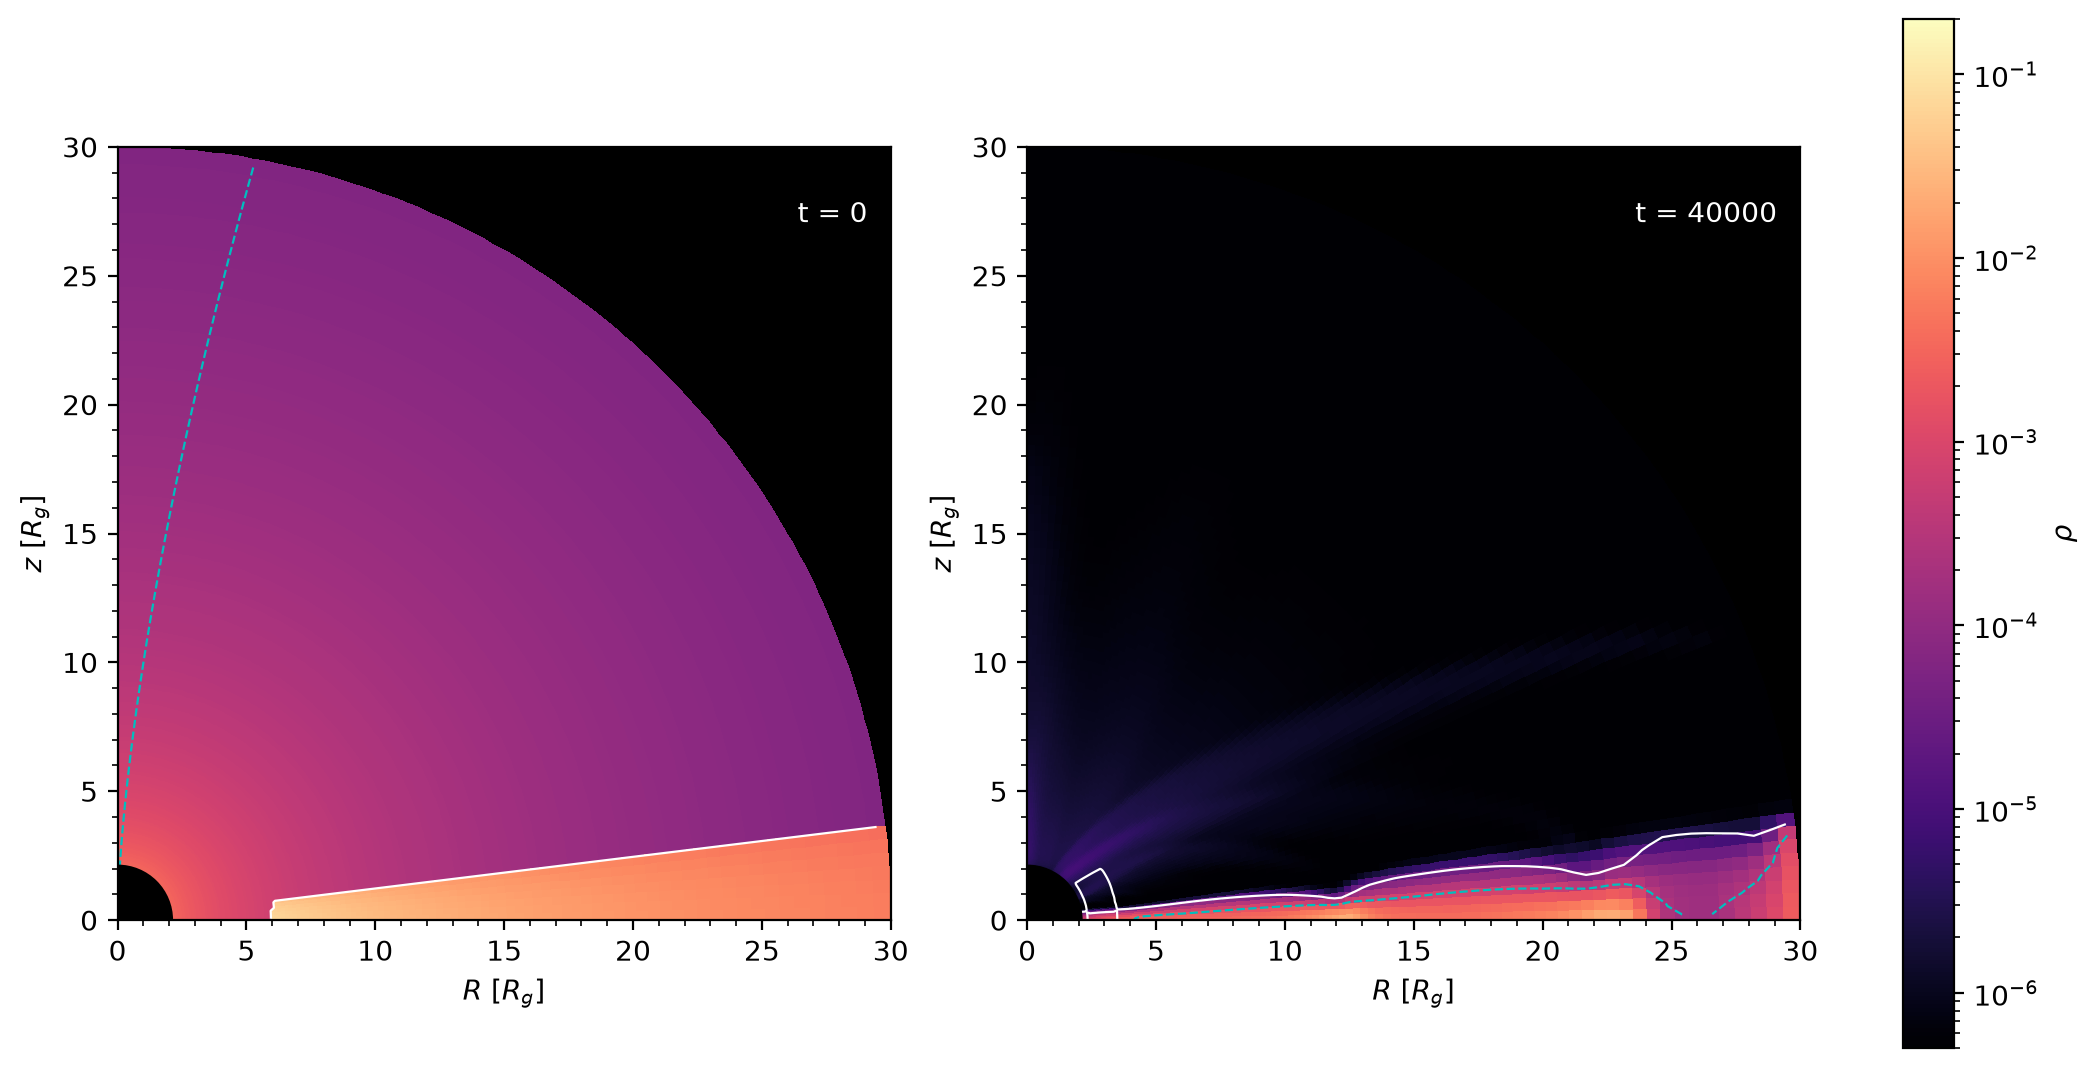

In [10]:
snapshot_row(T_FULL, xlim=(0, 30), ylim=(0, 30), ncol=2)

#### 1.2. Early Instabilities and Surface Layer

The first few hundred $t_g$: the inner edge plunges inside $R_\mathrm{isco}$, the radiation supported interior inflates and the dense
surface layer forms and breaks up. With the output cadence of the run, $50\,t_g$ is the earliest frame after $t = 0$.

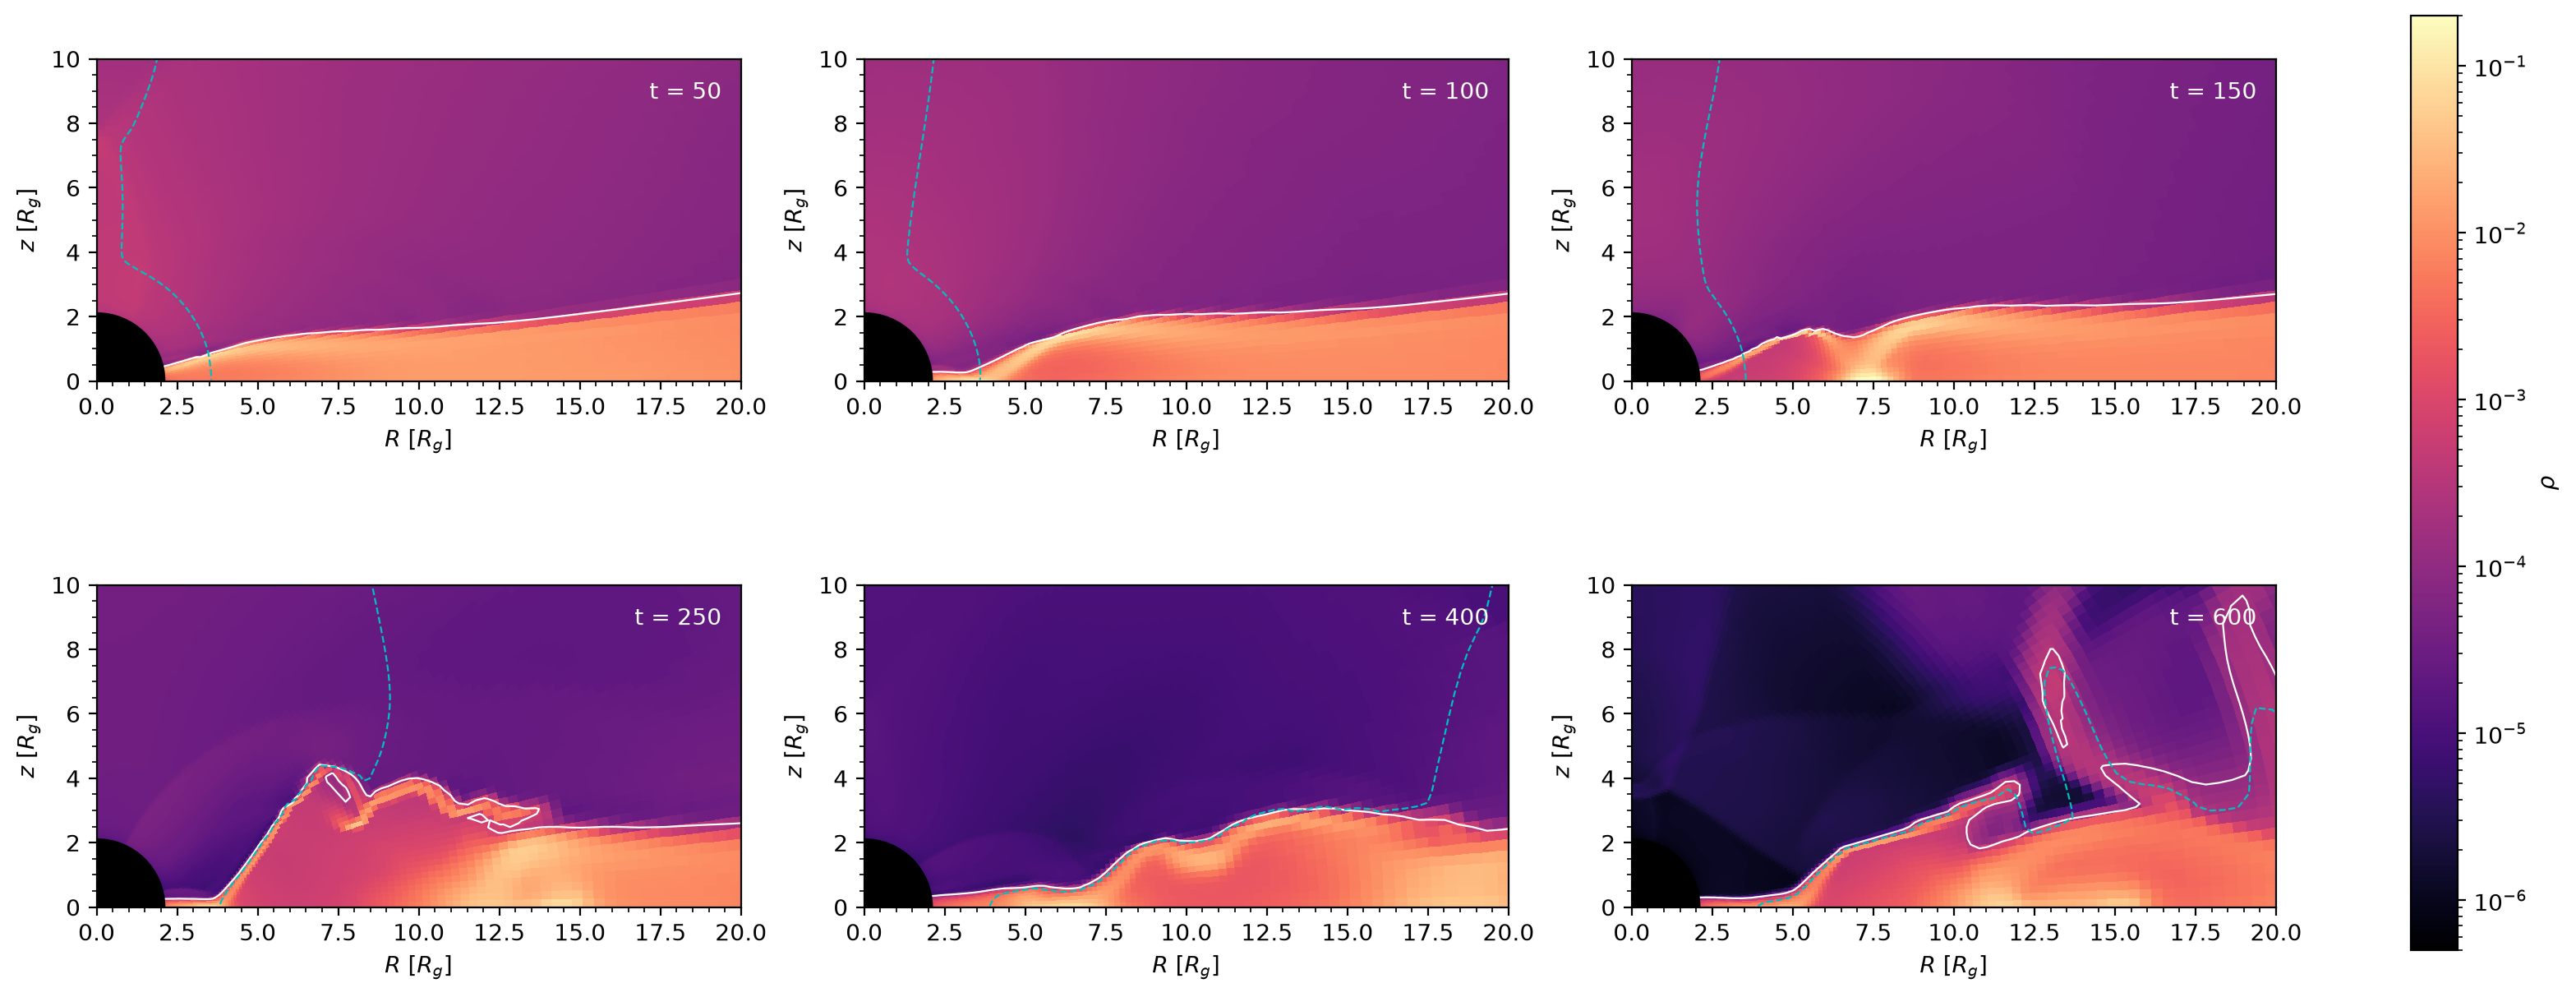

In [11]:
snapshot_row(T_EARLY)

#### 1.3. Evolution Towards the Quasi-Steady State

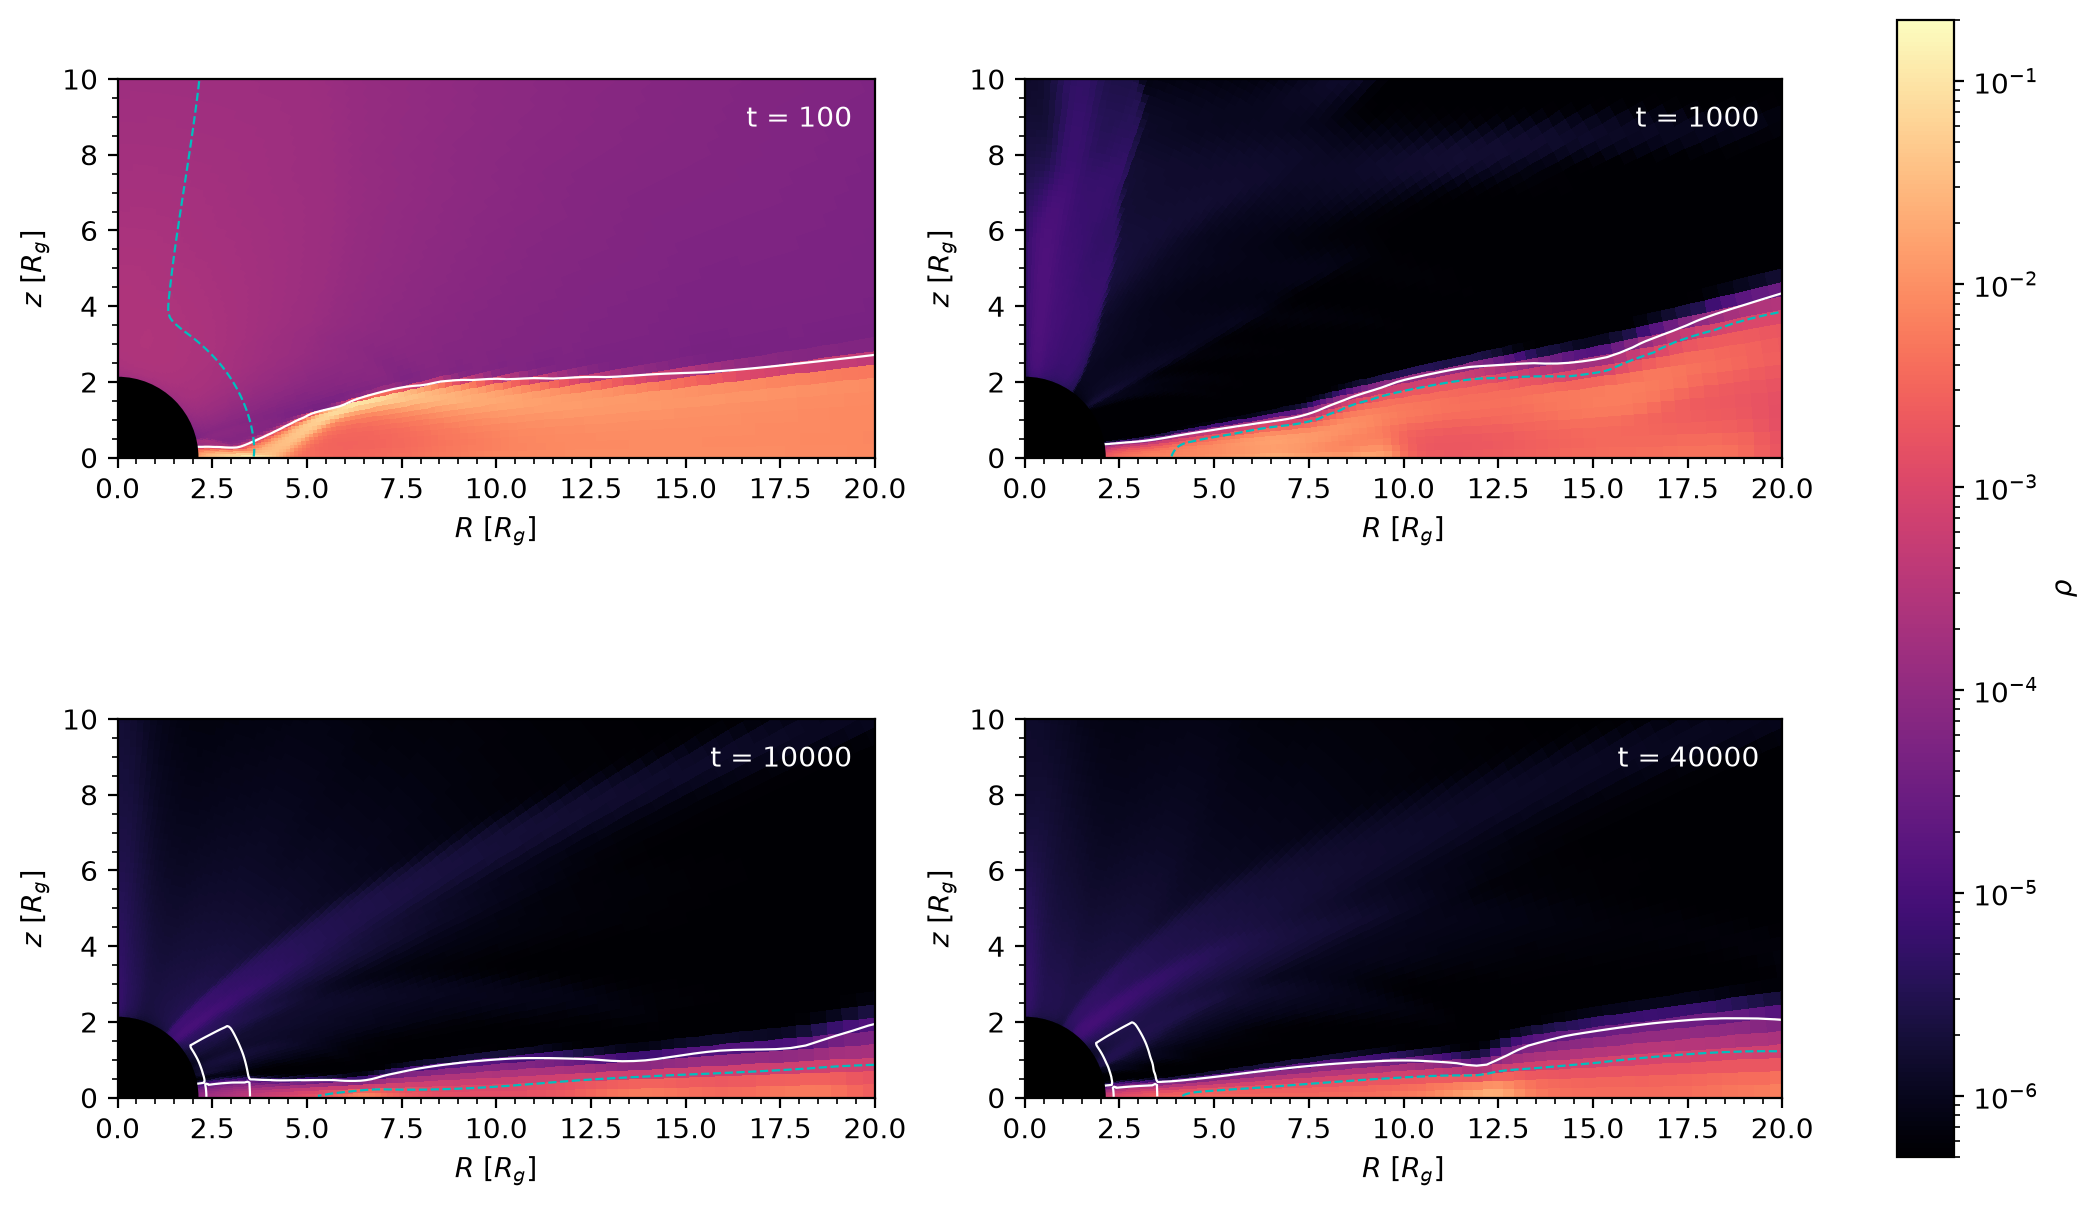

In [12]:
snapshot_row(T_EVOLUTION, ncol=2)

The same times for the gas temperature in Kelvin, and for the ratio $T_g/T_r$, which is close to unity where Compton and absorption
keep gas and radiation coupled.

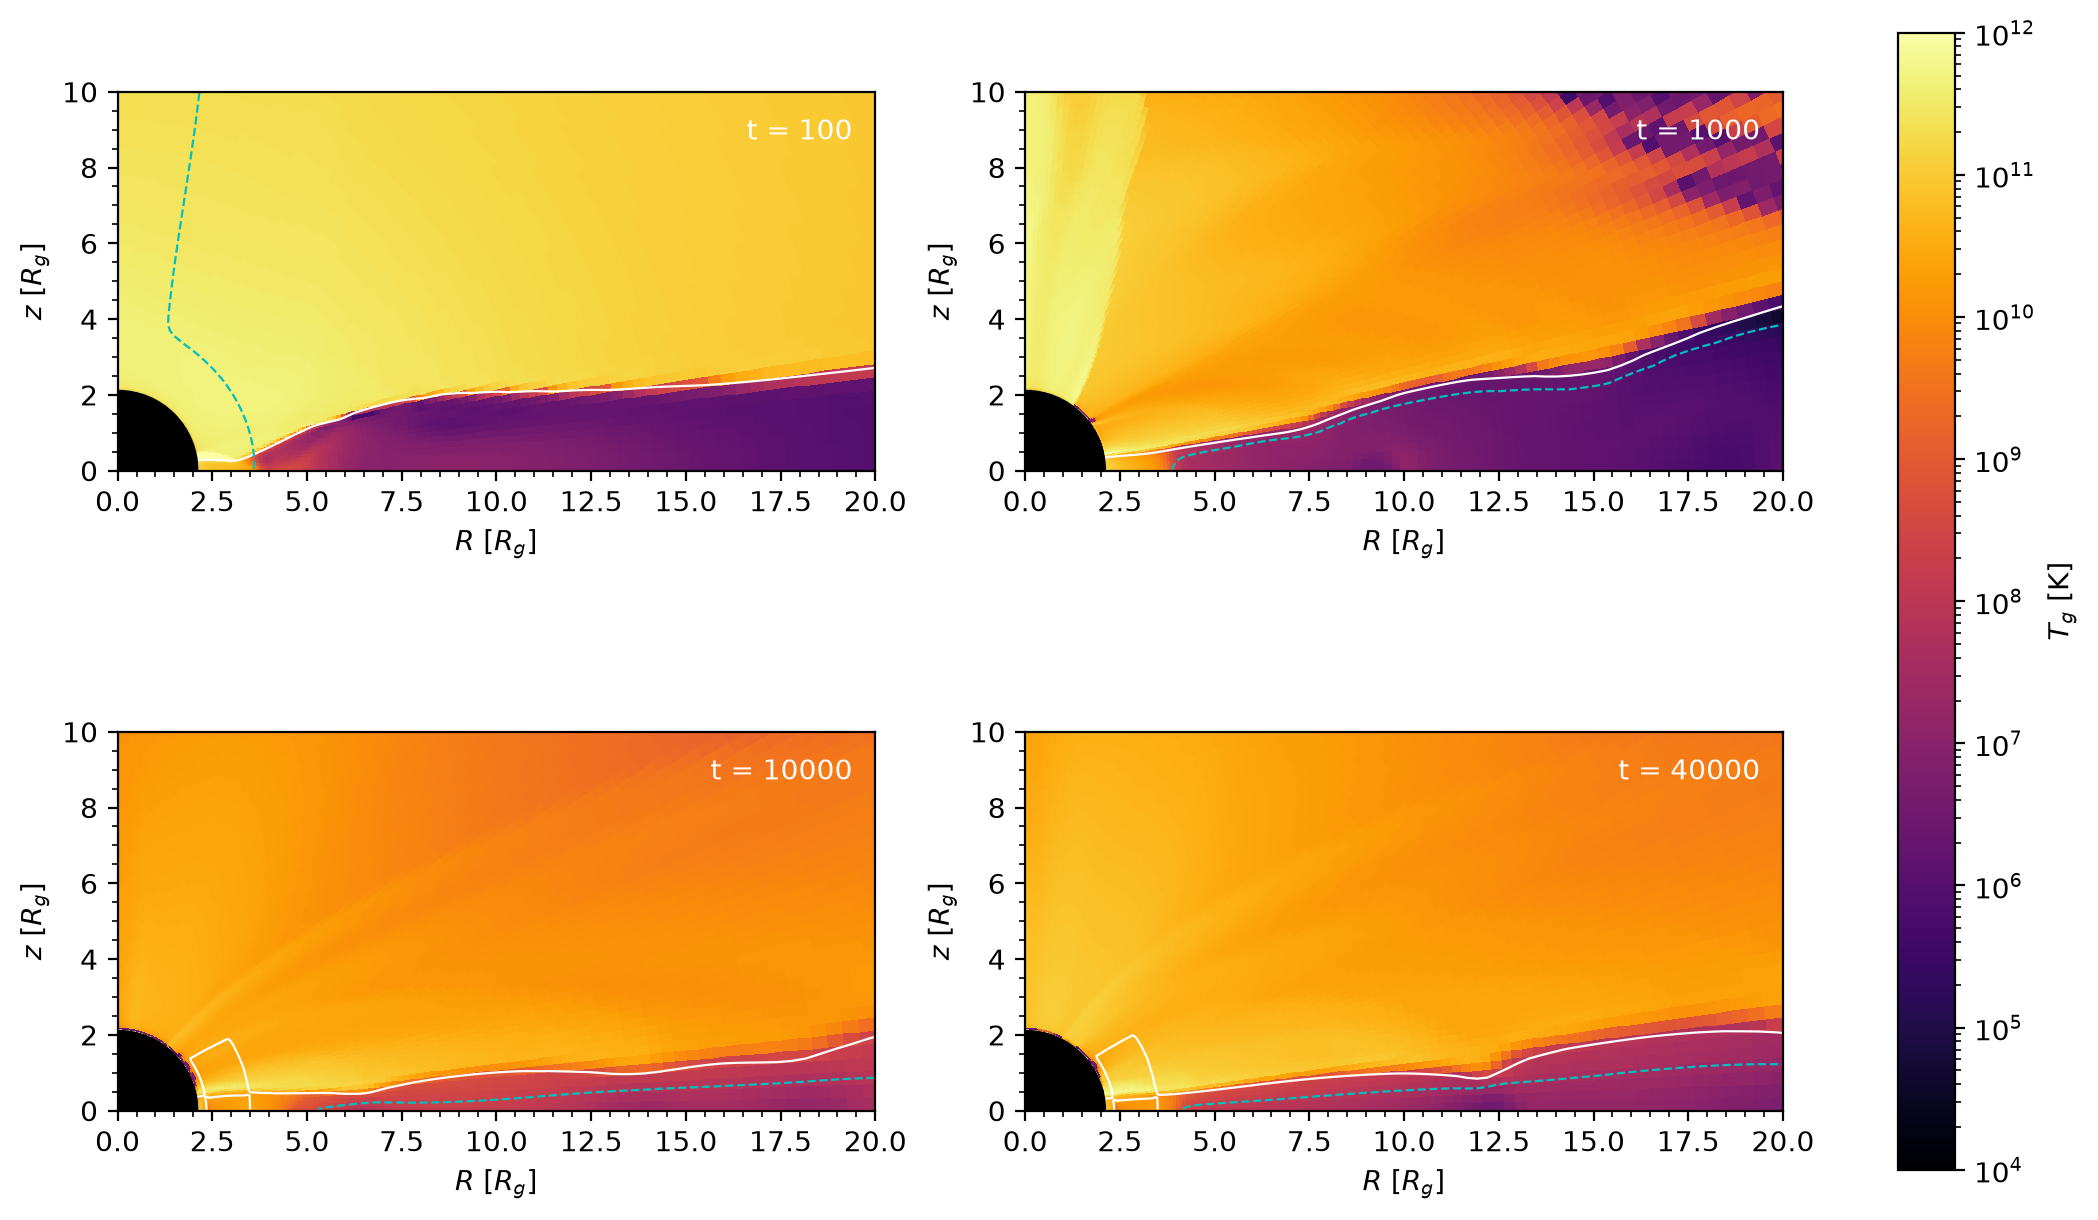

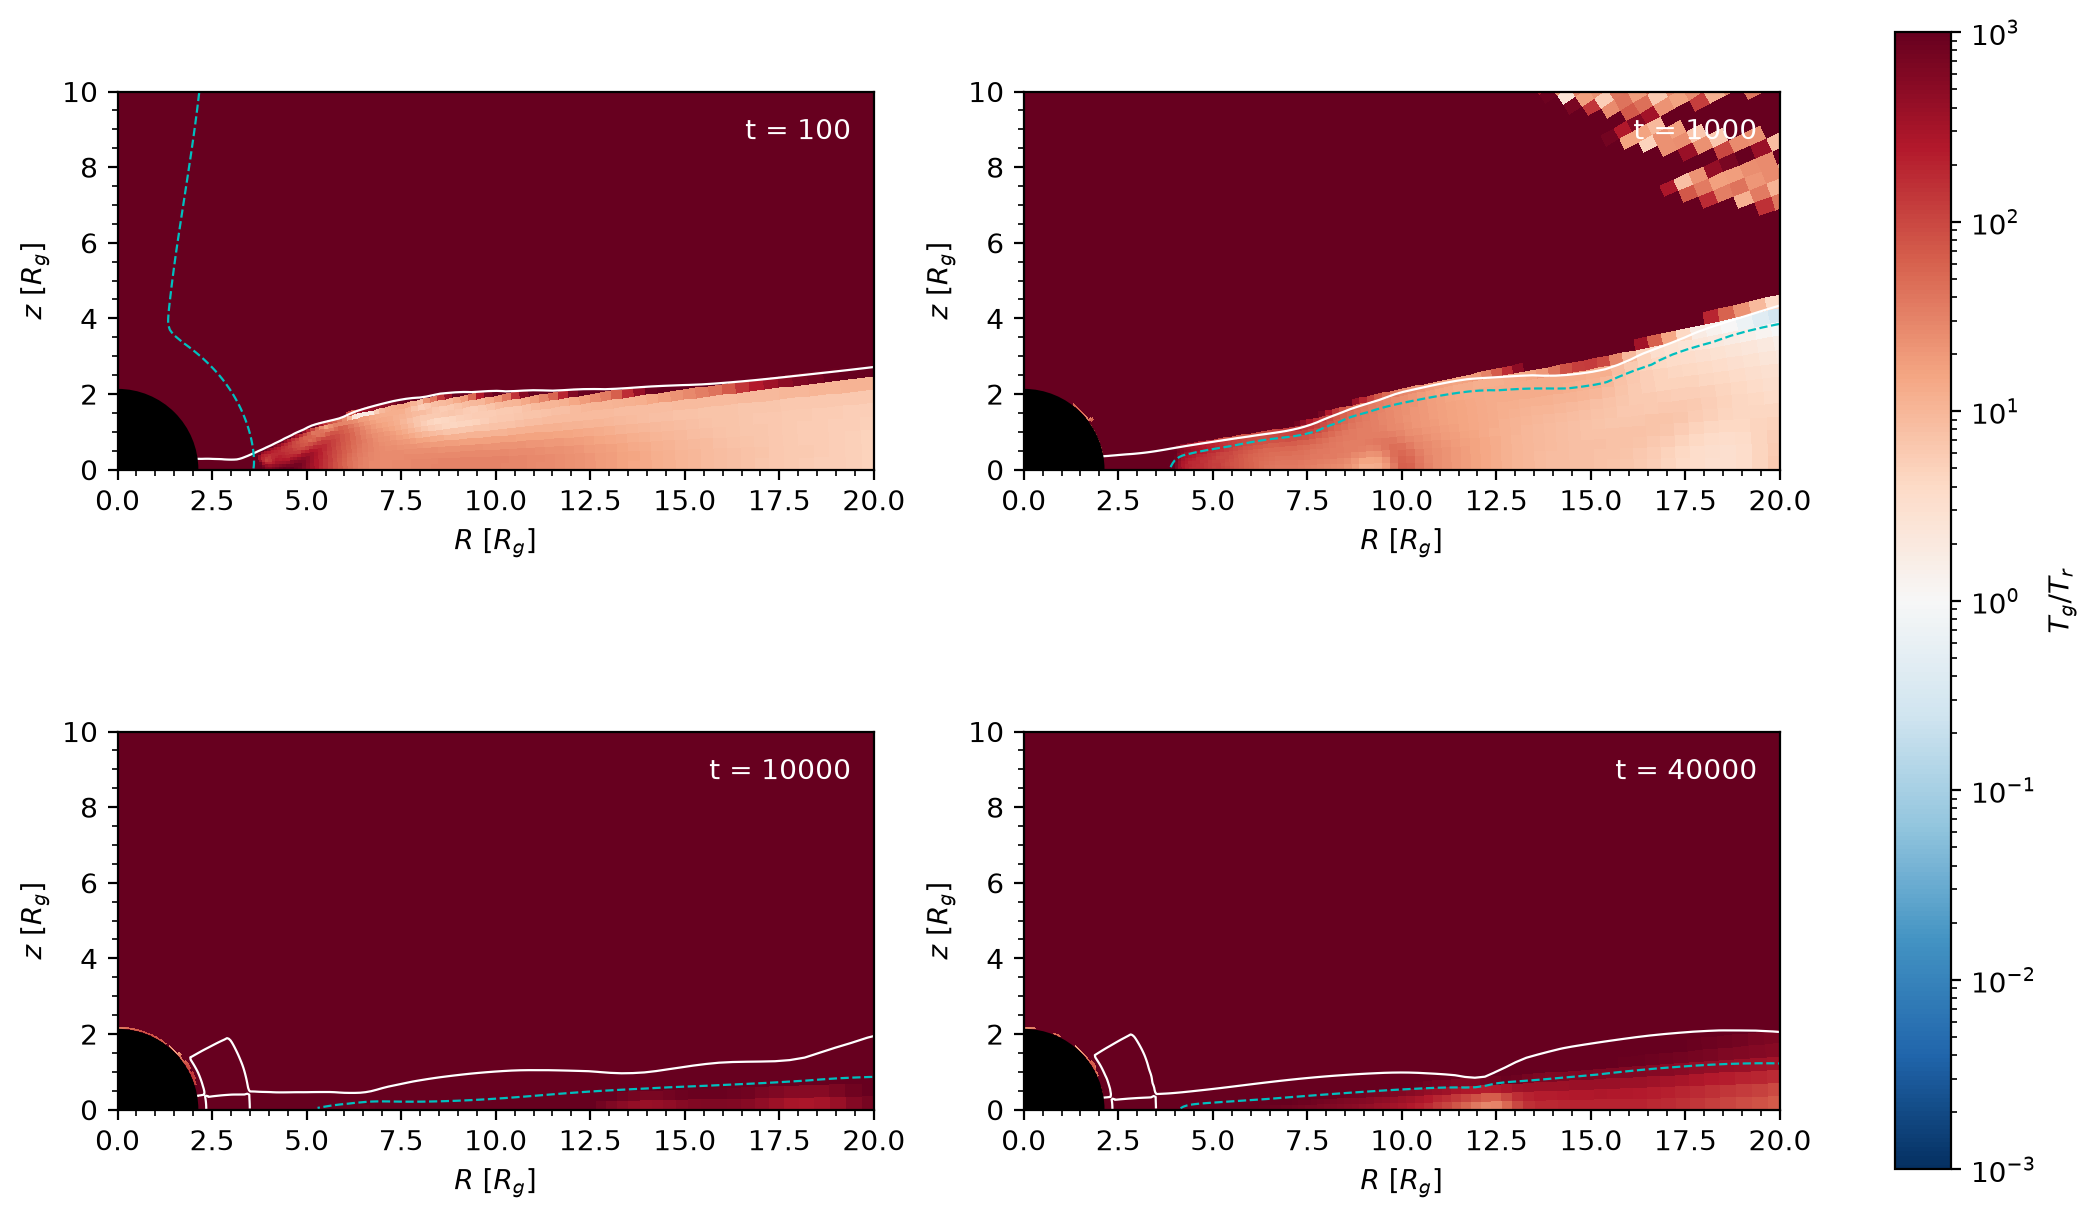

In [13]:
snapshot_row(T_EVOLUTION, field='Tg', norm=LogNorm(vmin=1e4, vmax=1e12), cmap='inferno', label=r'$T_g$ [K]', ncol=2)
snapshot_row(T_EVOLUTION, field='ratio', norm=LogNorm(vmin=1e-3, vmax=1e3), cmap='RdBu_r', label=r'$T_g / T_r$', ncol=2)

### 2. Relaxation Into the Quasi-Steady State

A disk becomes steady from the inside out, on the local viscous time, so relaxation is measured as a function of radius. The
quasi-steady state still contains quasi-periodic density waves, so steadiness means *statistical* stationarity: averages over
windows much longer than the wave period no longer change, within their statistical uncertainty. All of Section 2 uses the long
series.

#### 2.1. Global Time Series

Total, disk and corona mass, radiation, thermal and kinetic energy, the accretion rate through the inner boundary and the luminosity
leaving the outer boundary. The reference run is overlaid as thin dashed lines.

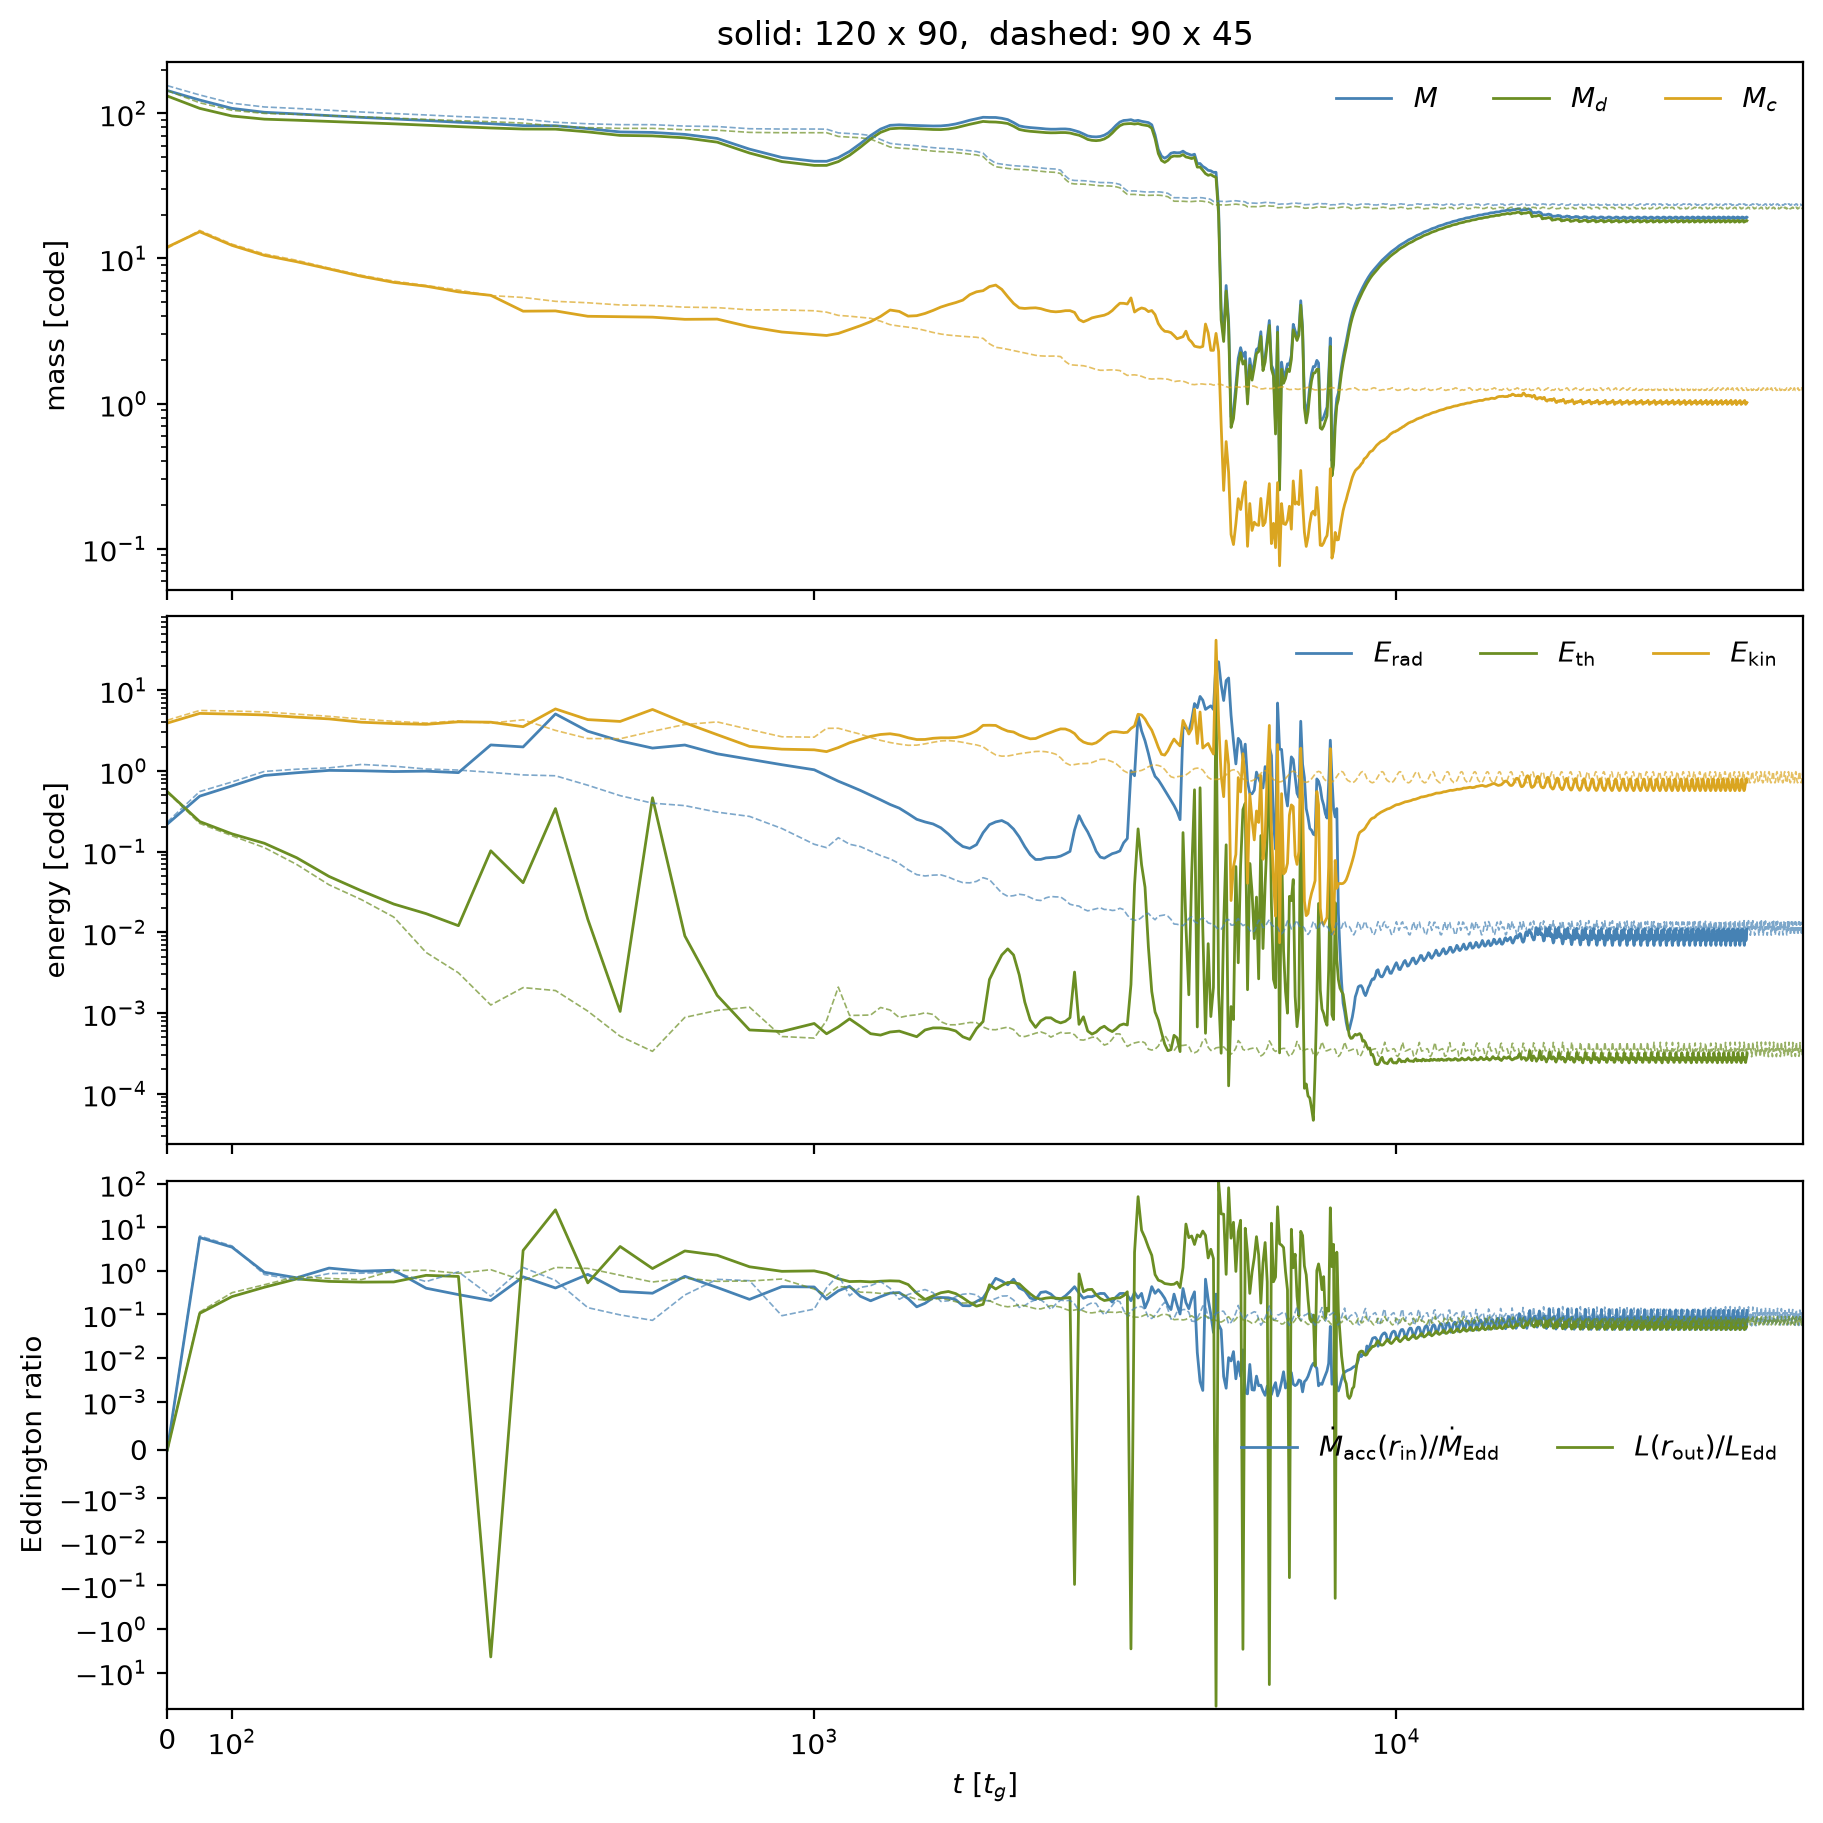

In [14]:
GLOBAL_TEX = {'M_d': r'$M_d$', 'E_rad': r'$E_\mathrm{rad}$', 'Mdot_acc(r_in)': r'$\dot M_\mathrm{acc}(r_\mathrm{in})$',
              'L(r_out)': r'$L(r_\mathrm{out})$'}

def global_series(Cx):
    return {'M_d': Cx['M_d'], 'E_rad': Cx['E_rad'], 'Mdot_acc(r_in)': -Cx['mdot'][:, 0], 'L(r_out)': Cx['L_out']}

mdot_acc_in = -C['mdot'][:, 0]
scale = MDOT0 / MDOT_EDD

fig, axs = plt.subplots(3, 1, figsize=[9, 9], sharex=True)
for run in RUNS:
    Cx, t = run['C'], run['t']
    lw, al = (1.0, 1.0) if run is RUN else (0.6, 0.7)
    lab = (lambda s: s) if run is RUN else (lambda s: None)
    for k, (key, name) in enumerate([('M', r'$M$'), ('M_d', r'$M_d$'), ('M_c', r'$M_c$')]):
        axs[0].plot(t, Cx[key], color=f"C{k}", ls=run['ls'], lw=lw, alpha=al, label=lab(name))
    for k, (key, name) in enumerate([('E_rad', r'$E_\mathrm{rad}$'), ('E_th', r'$E_\mathrm{th}$'), ('E_kin', r'$E_\mathrm{kin}$')]):
        axs[1].plot(t, Cx[key], color=f"C{k}", ls=run['ls'], lw=lw, alpha=al, label=lab(name))
    axs[2].plot(t, -Cx['mdot'][:, 0] * scale, color='C0', ls=run['ls'], lw=lw, alpha=al,
                label=lab(r'$\dot M_\mathrm{acc}(r_\mathrm{in}) / \dot M_\mathrm{Edd}$'))
    axs[2].plot(t, Cx['L_out'] * L0 / L_EDD, color='C1', ls=run['ls'], lw=lw, alpha=al,
                label=lab(r'$L(r_\mathrm{out}) / L_\mathrm{Edd}$'))
axs[0].set_yscale('log'); axs[0].set_ylabel('mass [code]'); axs[0].legend(ncol=3)
axs[1].set_yscale('log'); axs[1].set_ylabel('energy [code]'); axs[1].legend(ncol=3)
axs[2].set_yscale('symlog', linthresh=1e-3); axs[2].set_ylabel('Eddington ratio'); axs[2].legend(ncol=2)
axs[2].set_xlabel(r'$t\ [t_g]$')
for ax in axs:
    ax.set_xscale('symlog', linthresh=1000)
    ax.set_xlim(0, max(run['t'][-1] for run in RUNS))
axs[0].set_title(f"solid: {RUN['label']}" + (f",  dashed: {REF['label']}" if REF is not None else ''))
plt.show()

#### 2.2. Window Statistics

For a quantity $X(t)$ sampled at the cadence $\Delta t$, the sliding window mean over $N_W = W/\Delta t$ frames centred on $t_c$ is

$$
\langle X \rangle_W(t_c) = \frac{1}{N_W}\sum_{|t_k - t_c| \leq W/2} X(t_k) .
$$

The reference state is the mean over the last fraction `REF_FRAC` of the run, $\langle X\rangle_\mathrm{ref}$, starting at
$t_\mathrm{ref}$. Consecutive frames are correlated, so standard errors come from block averaging: an interval is split into $N_b$
blocks of length `BLOCK`, about three wave periods and longer than the correlation time, with block means $\bar X_b$, and

$$
\mathrm{SE} = \frac{\mathrm{std}\left(\bar X_b\right)}{\sqrt{N_b}} .
$$

If an interval holds fewer than four blocks, the block length is shortened to a quarter of it. Assuming the same fluctuation
statistics in a window of $N_W$ frames as in the reference interval of $N_\mathrm{ref}$ frames, the standard error of the difference
is $\sigma = \mathrm{SE}_\mathrm{ref}\sqrt{1 + N_\mathrm{ref}/N_W}$, and the normalized distance is

$$
D(t_c) = \frac{\left|\langle X\rangle_W(t_c) - \langle X\rangle_\mathrm{ref}\right|}{\sigma} .
$$

Windows that overlap the reference interval share frames with it and agree with it by construction, so only windows with
$t_c + W/2 \leq t_\mathrm{ref}$ are judged. The relaxation time is the first of them after which all window means stay consistent
with the reference,

$$
t_\mathrm{relax} = \min\left\{ t_c : D(t_c') < Z_\mathrm{crit}\ \ \forall\, t_c' \geq t_c,\ t_c' + W/2 \leq t_\mathrm{ref} \right\}, \qquad Z_\mathrm{crit} = 2 .
$$

If even the last judged window is inconsistent, $X$ has not demonstrably relaxed before $t_\mathrm{ref}$, and $t_\mathrm{ref}$ is
used as its relaxation time.

window 50 frames,  block 20 frames,  reference t > 32050


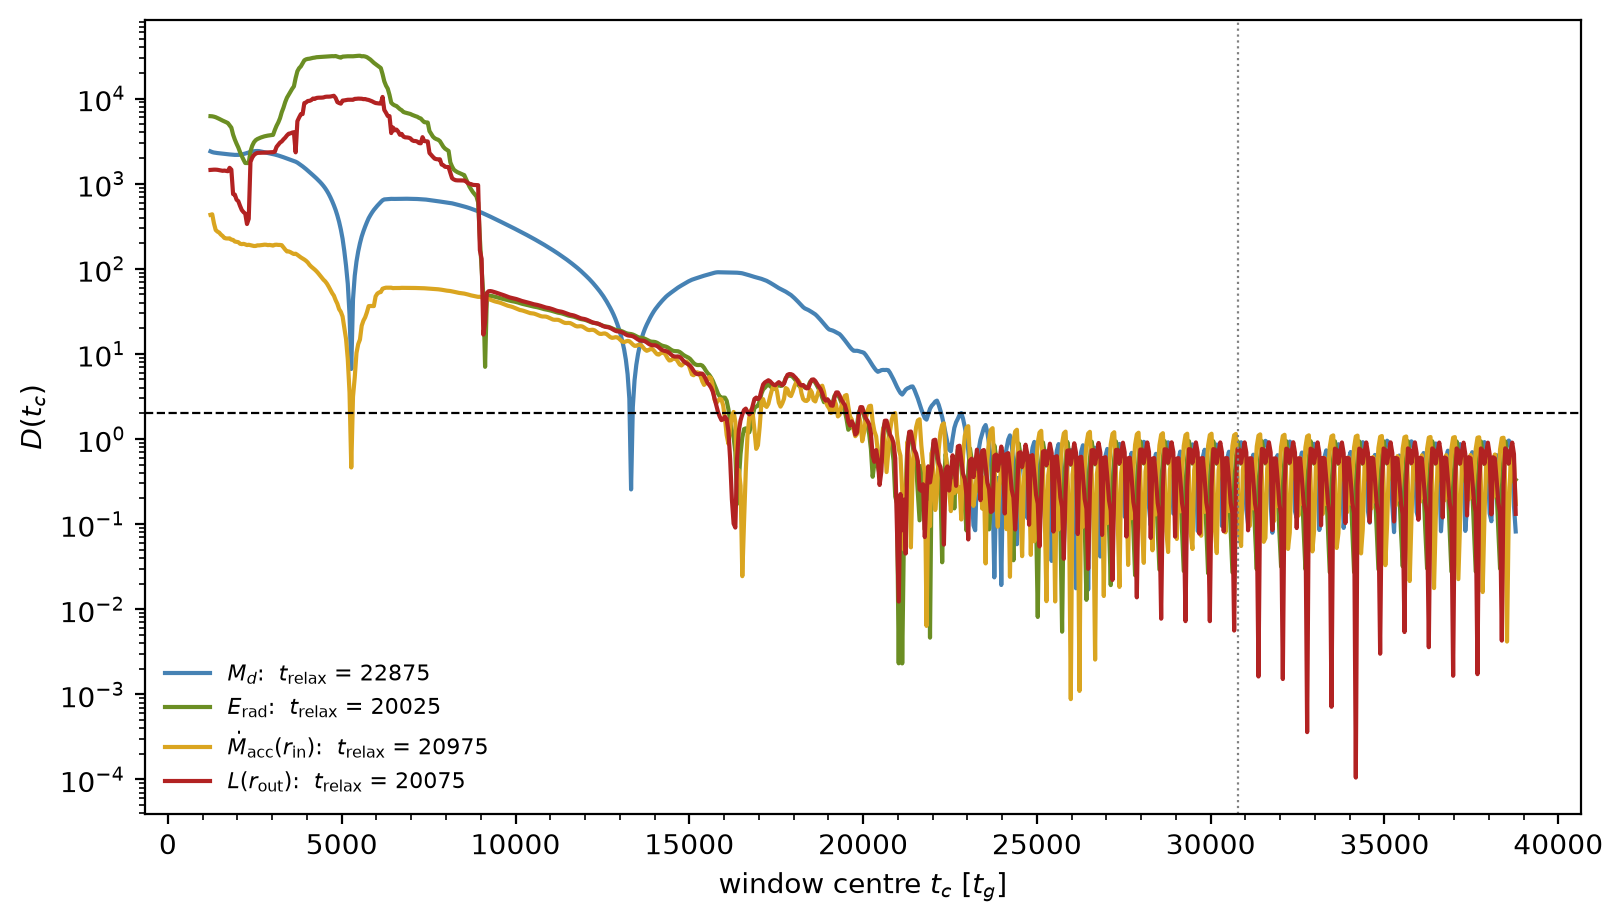

In [15]:
def frames(span, dt):
    return max(int(round(span / dt)), 1)

def mean_se(X, dt):
    # mean along axis 0 and block standard error, with at least four blocks
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    size = min(frames(BLOCK, dt), max(n // 4, 1))
    nb = n // size
    blocks = X[:nb * size].reshape((nb, size) + X.shape[1:]).mean(axis=1)
    return X.mean(axis=0), blocks.std(axis=0, ddof=1) / np.sqrt(nb)

def window_means(t, X, dt):
    # sliding means over W_WINDOW along axis 0, with their centre times
    X = np.asarray(X, dtype=float)
    n_w = min(frames(W_WINDOW, dt), X.shape[0])
    cs = np.cumsum(np.concatenate([np.zeros((1,) + X.shape[1:]), X]), axis=0)
    means = (cs[n_w:] - cs[:-n_w]) / n_w
    centres = 0.5 * (t[n_w - 1:] + t[:t.size - n_w + 1])
    return centres, means, n_w

def relaxation(t, X, dt):
    # relaxation time of X, for a time series or for every column of a (time, radius) array
    X = np.asarray(X, dtype=float)
    n_ref = max(int(round(REF_FRAC * t.size)), 8)
    tc, m, n_w = window_means(t, X, dt)
    ref, se = mean_se(X[-n_ref:], dt)
    sigma = np.maximum(se * np.sqrt(1.0 + n_ref / n_w), 1e-300)
    D = np.abs(m - ref) / sigma
    t_ref = t[-n_ref]
    judged = tc + 0.5 * W_WINDOW <= t_ref
    if not judged.any():
        return np.full(X.shape[1:], np.nan), tc, D, t_ref
    ok = D[judged] < Z_CRIT
    tail_ok = np.flip(np.logical_and.accumulate(np.flip(ok, axis=0), axis=0), axis=0)
    first = np.argmax(tail_ok, axis=0)
    t_relax = np.where(tail_ok.any(axis=0), tc[judged][first], np.nan)
    return t_relax, tc, D, t_ref

def steady_start(run, override=None):
    # latest relaxation time of the global quantities, t_ref for those that have not relaxed before t_ref
    times, curves = {}, {}
    for label, X in global_series(run['C']).items():
        tr, tc, D, t_ref = relaxation(run['t'], X, run['dt'])
        times[label] = float(tr)
        curves[label] = (tc, D)
    t_steady = override if override is not None else max(v if np.isfinite(v) else t_ref for v in times.values())
    return t_steady, times, curves, t_ref

for run, override in [(RUN, T_STEADY_OVERRIDE), (REF, REF_T_STEADY)]:
    if run is None:
        continue
    run['t_steady'], run['t_relax'], run['D_curves'], run['t_ref'] = steady_start(run, override)

print(f"window {frames(W_WINDOW, DT_OUT)} frames,  block {frames(BLOCK, DT_OUT)} frames,  reference t > {RUN['t_ref']:.0f}")
fig, ax = plt.subplots(figsize=[8, 4.5])
for k, (label, (tc, D)) in enumerate(RUN['D_curves'].items()):
    tr = RUN['t_relax'][label]
    txt = f"{tr:.0f}" if np.isfinite(tr) else "not before $t_\\mathrm{ref}$"
    ax.plot(tc, D, color=f"C{k}", label=f"{GLOBAL_TEX[label]}:  $t_\\mathrm{{relax}}$ = {txt}")
ax.axhline(Z_CRIT, color='k', lw=0.8, ls='--')
ax.axvline(RUN['t_ref'] - 0.5 * W_WINDOW, color='gray', lw=0.8, ls=':')
ax.text(RUN['t_ref'] - 0.5 * W_WINDOW, ax.get_ylim()[0], ' overlaps reference', color='gray', fontsize=8, va='bottom')
ax.set_yscale('log'); ax.set_xlabel(r'window centre $t_c\ [t_g]$'); ax.set_ylabel(r'$D(t_c)$')
ax.legend(fontsize=8)
plt.show()

#### 2.3. Relaxation as a Function of Radius

The same statistic applied to $\log_{10}\Sigma(r)$ and to $\dot M_\mathrm{acc}(r)$ at every radius gives $t_\mathrm{relax}(r)$, which
is compared with the viscous time $t_\nu(r)$.

The inflow equilibrium radius $R_\mathrm{eq}(t_c)$ is the largest radius out to which the window averaged accretion rate is
constant. The waves are strongly nonlinear, so single radii scatter, and the criterion uses the window mean smoothed over $5$
radial cells, $\overline{\dot M}_W(r)$, and a relative tolerance,

$$
R_\mathrm{eq}(t_c) = \max\left\{ r_k : \left|\frac{\overline{\dot M}_W(r_j)}{\dot M_{W,\mathrm{in}}} - 1\right| < \mathrm{TOL_{EQ}}\ \ \forall\, j \leq k \right\},
\qquad \dot M_{W,\mathrm{in}} = \left\langle \langle\dot M_\mathrm{acc}\rangle_W(r) \right\rangle_{r_\mathrm{in} < r < 6},
$$

where the reference averages the plunging region without the boundary cell. The two cells next to the outer boundary are not
judged, since their cell centred flux is biased by the boundary, see Section 3.2. $R_\mathrm{eq}$ is compared with $R_\nu(t)$, where
$t_\nu(R_\nu) = t$, and summarized by its median and $16$–$84\,\%$ range over the steady window.

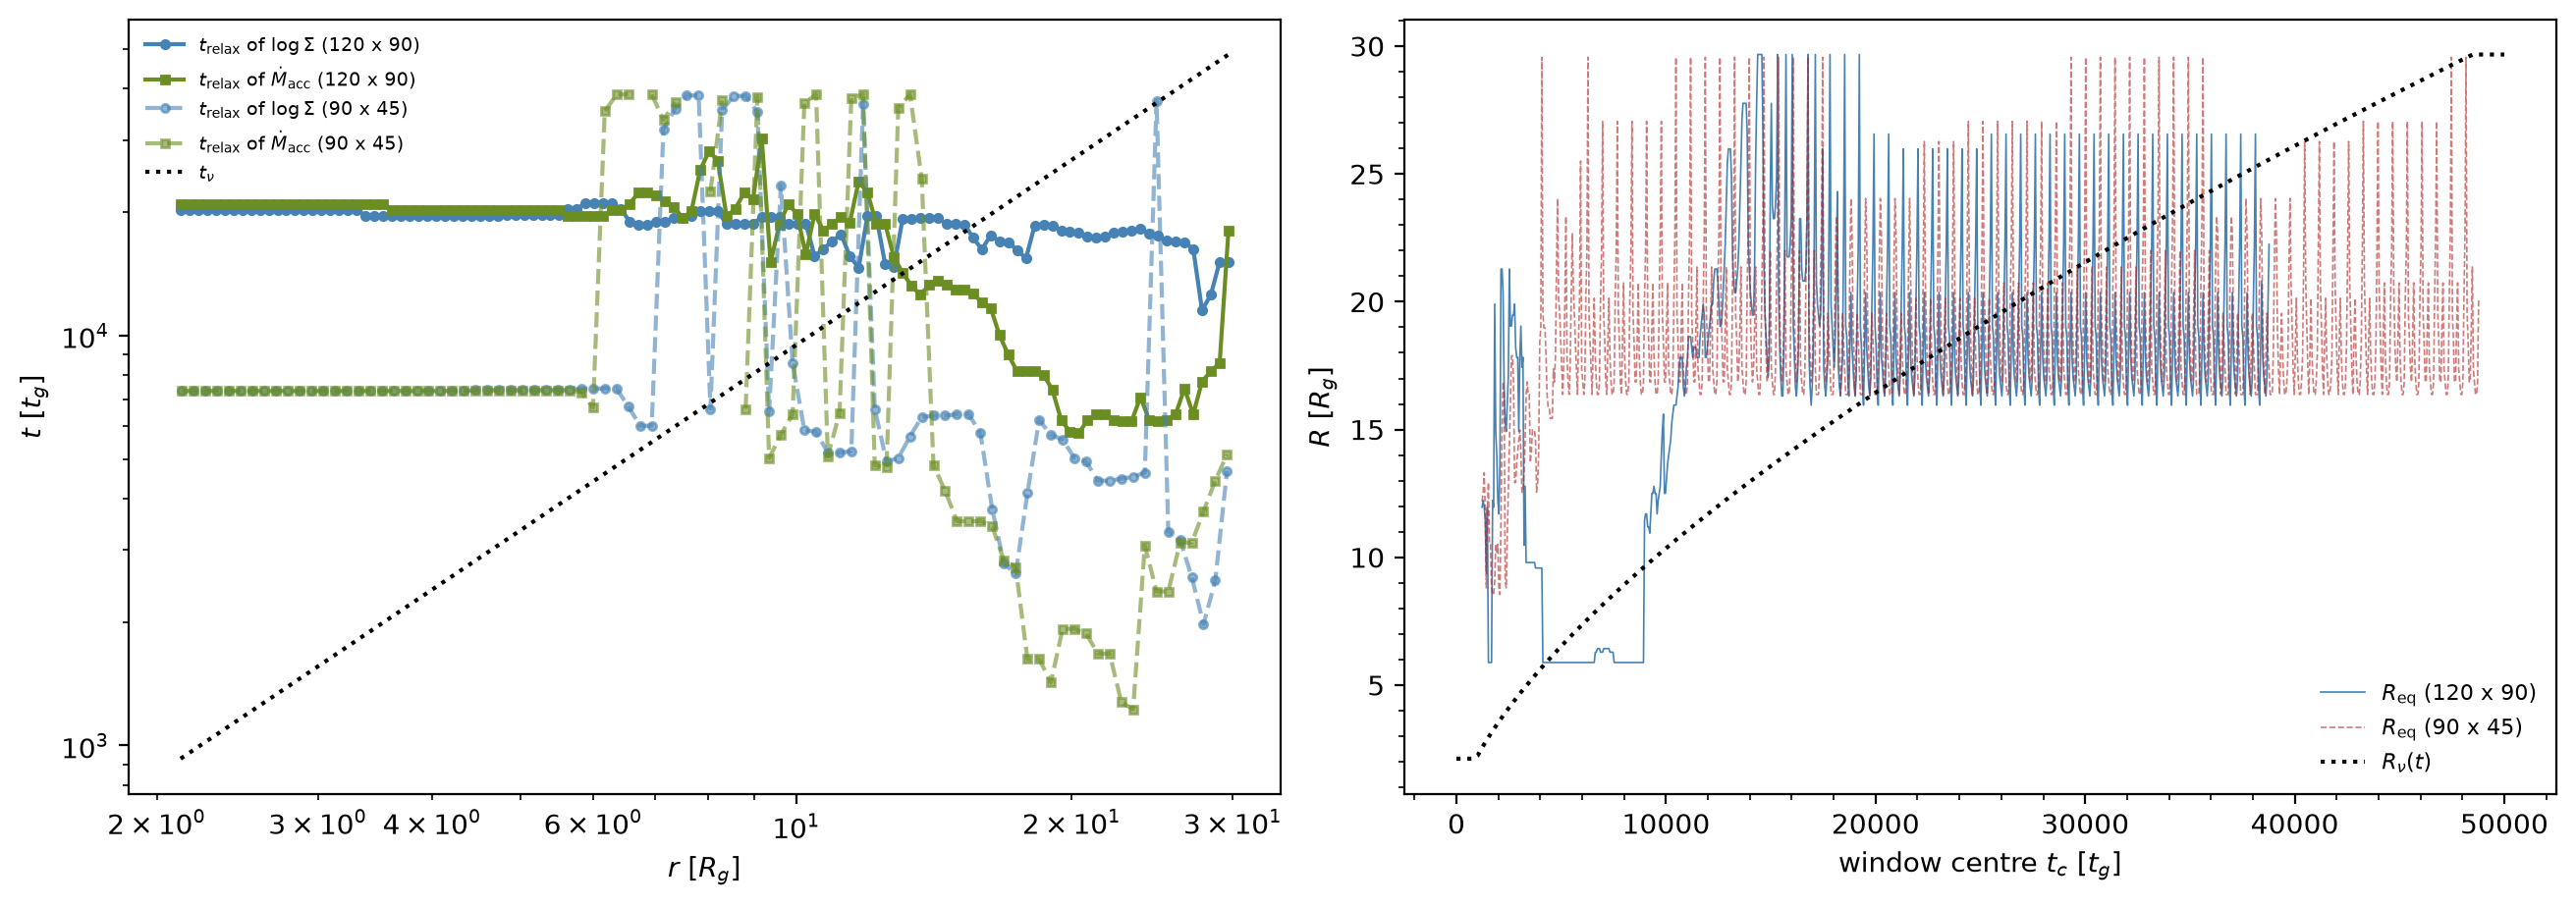

In [16]:
def inflow_equilibrium(run):
    t, r, dt = run['t'], run['r'], run['dt']
    tc, wm, _ = window_means(t, -run['C']['mdot'], dt)
    inner = (r > r[0]) & (r < 6.0)
    ref = wm[:, inner].mean(axis=1)
    smooth = uniform_filter1d(wm, 5, axis=1, mode='nearest')
    ok = np.abs(smooth / ref[:, None] - 1.0) < TOL_EQ
    ok[:, r < 6.0] = True
    ok[:, -2:] = True
    flat = np.logical_and.accumulate(ok, axis=1)
    r_eq = np.array([r[np.nonzero(row)[0][-1]] if row.any() else np.nan for row in flat])
    steady = tc - 0.5 * W_WINDOW >= run['t_steady']
    stats = np.nanpercentile(r_eq[steady], [16, 50, 84]) if steady.any() else np.full(3, np.nan)
    return tc, r_eq, stats

for run in RUNS:
    run['t_relax_sigma'] = relaxation(run['t'], np.log10(np.maximum(run['C']['sigma'], 1e-300)), run['dt'])[0]
    run['t_relax_mdot'] = relaxation(run['t'], -run['C']['mdot'], run['dt'])[0]
    run['tc_eq'], run['R_eq'], run['R_eq_stats'] = inflow_equilibrium(run)

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
for run in RUNS:
    a = 1.0 if run is RUN else 0.6
    axs[0].plot(run['r'], run['t_relax_sigma'], 'o', ls=run['ls'], ms=3, color='C0', alpha=a,
                label=r'$t_\mathrm{relax}$ of $\log\Sigma$' + f" ({run['label']})")
    axs[0].plot(run['r'], run['t_relax_mdot'], 's', ls=run['ls'], ms=3, color='C1', alpha=a,
                label=r'$t_\mathrm{relax}$ of $\dot M_\mathrm{acc}$' + f" ({run['label']})")
    axs[1].plot(run['tc_eq'], run['R_eq'], ls=run['ls'], lw=0.6, color=run['color'], alpha=a, label=r'$R_\mathrm{eq}$' + f" ({run['label']})")
axs[0].plot(R_C, t_viscous(R_C), 'k:', label=r'$t_\nu$')
axs[0].set_xscale('log'); axs[0].set_yscale('log')
axs[0].set_xlabel(r'$r\ [R_g]$'); axs[0].set_ylabel(r'$t\ [t_g]$'); axs[0].legend(fontsize=7)
tc_all = np.linspace(0, max(run['t'][-1] for run in RUNS), 200)
axs[1].plot(tc_all, np.clip(r_viscous(tc_all), R_C[0], R_C[-1]), 'k:', label=r'$R_\nu(t)$')
axs[1].set_xlabel(r'window centre $t_c\ [t_g]$'); axs[1].set_ylabel(r'$R\ [R_g]$'); axs[1].legend(fontsize=8)
plt.show()

#### 2.4. Start of the Steady Window

The steady window used by all following sections starts at the latest of the global relaxation times, unless it is set by hand with
`T_STEADY_OVERRIDE`. The reference run gets its own steady window by the same criterion, or `REF_T_STEADY`.

In [17]:
for run in RUNS:
    run['sel'] = run['t'] >= run['t_steady']
    # the series for spectra and the mass budget: the dense segment if there is one, otherwise the steady long series
    if run['D'] is not None:
        idx = np.nonzero(run['D']['t'] >= run['t_steady'])[0]
        run['S'], run['dt_s'] = slice_cache(run['D'], idx), run['dt_d']
    else:
        run['S'], run['dt_s'] = slice_cache(run['C'], np.nonzero(run['sel'])[0]), run['dt']
    run['ts'] = run['S']['t']
    lo, med, hi = run['R_eq_stats']
    print(f"{run['label']}:")
    print("   relaxation times:", {k: (round(v) if np.isfinite(v) else 'not before t_ref') for k, v in run['t_relax'].items()})
    print(f"   steady window t in [{run['t_steady']:.0f}, {run['t'][-1]:.0f}],  {run['sel'].sum()} long frames;"
          f"  spectral series {run['ts'].size} frames at cadence {run['dt_s']:g}")
    print(f"   inflow equilibrium radius R_eq = {med:.1f} ({lo:.1f} - {hi:.1f}),  viscous estimate R_nu = {r_viscous(run['t'][-1]):.1f}")

T_STEADY, SEL, TS = RUN['t_steady'], RUN['sel'], RUN['t'][RUN['sel']]

120 x 90:
   relaxation times: {'M_d': 22875, 'E_rad': 20025, 'Mdot_acc(r_in)': 20975, 'L(r_out)': 20075}
   steady window t in [22875, 40000],  343 long frames;  spectral series 2001 frames at cadence 5
   inflow equilibrium radius R_eq = 17.8 (16.7 - 20.4),  viscous estimate R_nu = 26.1
90 x 45:
   relaxation times: {'M_d': 9225, 'E_rad': 7125, 'Mdot_acc(r_in)': 7325, 'L(r_out)': 7125}
   steady window t in [9225, 50000],  816 long frames;  spectral series 816 frames at cadence 50
   inflow equilibrium radius R_eq = 17.9 (16.4 - 21.4),  viscous estimate R_nu = 30.3


#### 2.5. Residual Drift

A steady window should show no trend beyond the fluctuations. The block means $\bar X_b$ at block centres $t_b$, normalized by the
window mean, are fitted with a straight line,

$$
\frac{\bar X_b}{\langle X\rangle} = a + b\,\frac{t_b - \bar t}{10^4\,t_g},
$$

and the slope $b$, the relative change per $10^4\,t_g$, is tested against zero with heteroskedasticity and autocorrelation consistent
standard errors (Newey–West, one lag), which accounts for correlated neighbouring blocks. $|b|/\sigma_b > 2$ flags a significant
drift. This replaces stationarity tests such as KPSS or ADF, which are dominated by the periodic waves and only compare against a
single alternative.

In [18]:
def drift(t, X, dt):
    size = frames(BLOCK, dt)
    nb = X.size // size
    if nb < 4:
        return np.nan, np.nan
    xb = X[:nb * size].reshape(nb, size).mean(axis=1)
    tb = t[:nb * size].reshape(nb, size).mean(axis=1)
    fit = sm.OLS(xb / xb.mean(), sm.add_constant((tb - tb.mean()) / 1e4)).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    return fit.params[1], fit.bse[1]

print(f"{'':28s}" + ''.join(f"{run['label']:>30s}" for run in RUNS))
for label in global_series(C):
    line = f"{label:28s}"
    for run in RUNS:
        X = global_series(run['C'])[label][run['sel']]
        b, eb = drift(run['t'][run['sel']], X, run['dt'])
        line += f"{b * 100:+10.2f} +- {eb * 100:5.2f} %  (z = {b / eb:+5.1f})" if np.isfinite(b) else f"{'too short':>30s}"
    print(line)
print("relative change per 1e4 t_g over each steady window")

                                                  120 x 90                       90 x 45
M_d                              -0.07 +-  0.04 %  (z =  -1.7)     -0.01 +-  0.01 %  (z =  -1.2)
E_rad                            -0.45 +-  0.39 %  (z =  -1.2)     -0.09 +-  0.10 %  (z =  -0.9)
Mdot_acc(r_in)                   -0.27 +-  0.82 %  (z =  -0.3)     -0.02 +-  0.22 %  (z =  -0.1)
L(r_out)                         -0.36 +-  0.41 %  (z =  -0.9)     -0.08 +-  0.10 %  (z =  -0.8)
relative change per 1e4 t_g over each steady window


### 3. Accretion

#### 3.1. Space–Time Diagram of the Mass Flux

$\dot M_\mathrm{acc}(r, t) = -\dot M(r,t)$ in units of $\dot M_\mathrm{Edd}$, positive for inflow, from the long series. Disk and
corona are separated with the DiskFraction weights.

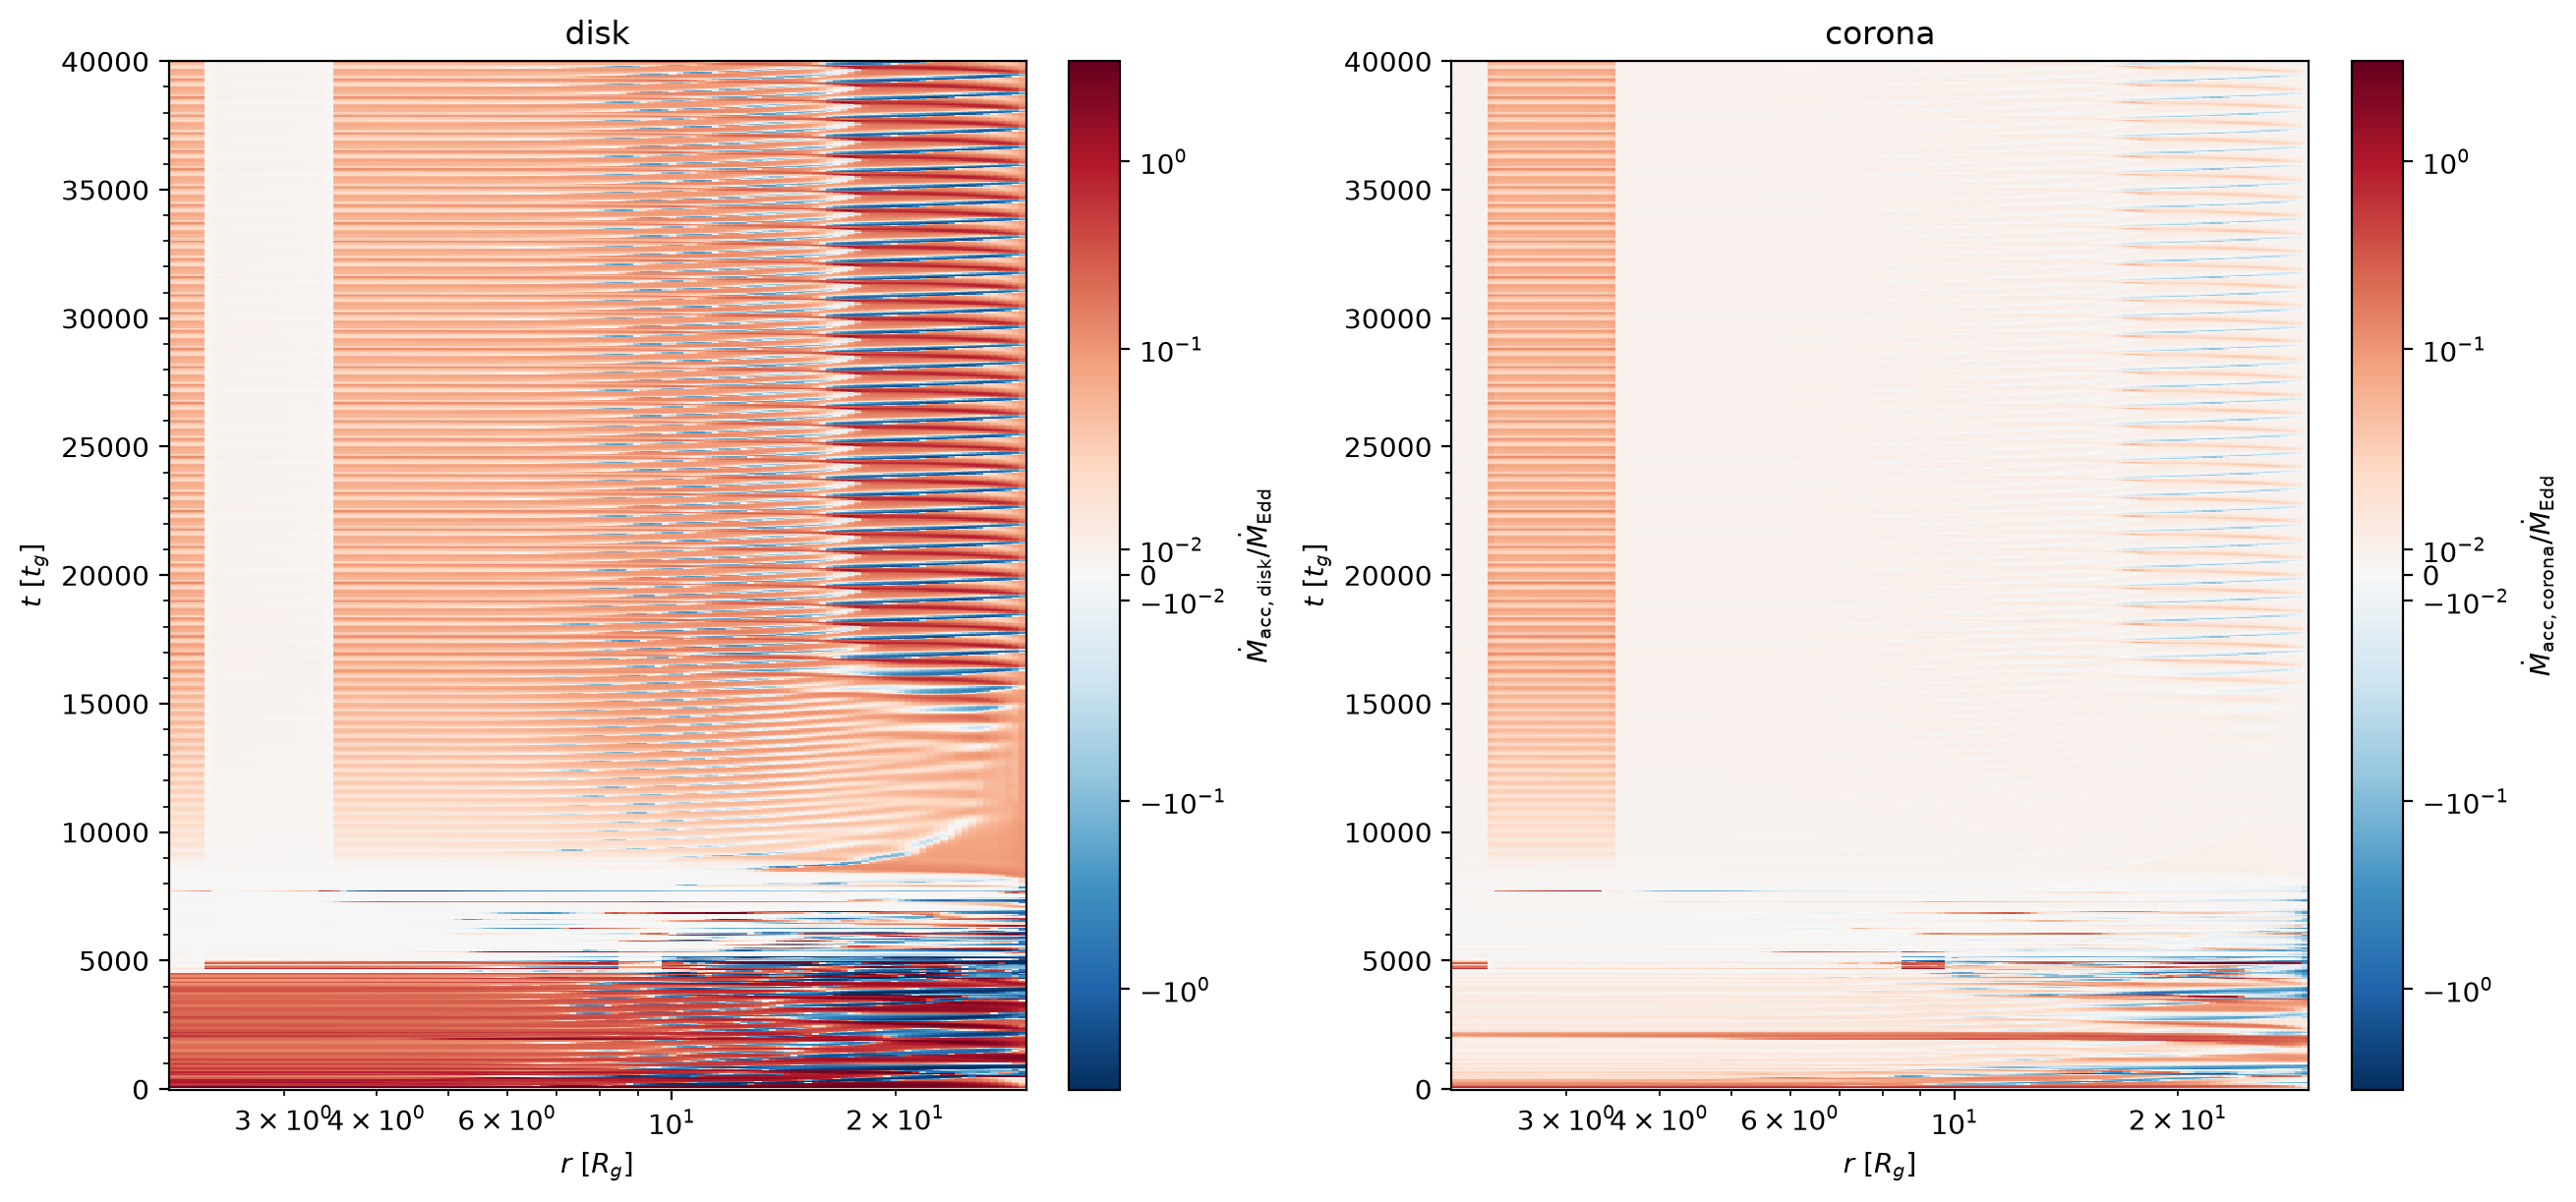

In [19]:
def spacetime(ax, t, data, norm, cmap, label, tlim=None, r=R_C):
    im = ax.pcolormesh(r, t, data, norm=norm, cmap=cmap, shading='nearest', rasterized=True)
    ax.set_xscale('log'); ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$t\ [t_g]$')
    if tlim is not None:
        ax.set_ylim(*tlim)
    plt.colorbar(im, ax=ax, label=label)

mdot_acc = -C['mdot']
lin = np.nanpercentile(np.abs(mdot_acc[SEL]) * scale, 50)
vmax = np.nanpercentile(np.abs(mdot_acc) * scale, 99.5)
norm = SymLogNorm(linthresh=max(lin, 1e-6), vmin=-vmax, vmax=vmax)
fig, axs = plt.subplots(1, 2, figsize=[13, 6])
spacetime(axs[0], T, -C['mdot_d'] * scale, norm, 'RdBu_r', r'$\dot M_\mathrm{acc,disk} / \dot M_\mathrm{Edd}$')
spacetime(axs[1], T, -C['mdot_c'] * scale, norm, 'RdBu_r', r'$\dot M_\mathrm{acc,corona} / \dot M_\mathrm{Edd}$')
axs[0].set_title('disk'); axs[1].set_title('corona')
plt.show()

#### 3.2. Mean Accretion Profile and the Steady Disk

Over the steady window the time averaged accretion rate with its block standard error should be independent of radius inside
$R_\mathrm{eq}$. A steady $\alpha$-disk with zero torque at $R_\mathrm{isco}$ then has the surface density

$$
\Sigma_\mathrm{ss}(R) = \frac{\langle\dot M_\mathrm{acc}\rangle}{3\pi\,\nu(R)}\left(1 - \sqrt{\frac{R_\mathrm{isco}}{R}}\right), \qquad R > R_\mathrm{isco},
$$

evaluated with the measured mean accretion rate at the inner boundary and the kinematic viscosity $\nu(R)$ of the model.

The printed check compares the mean flux in the cells next to the boundaries with the median over the interior. The flux is
evaluated at cell centres, $\rho v_r$ of the cell, not as the conservative interface flux of the solver, and next to a boundary the
two can differ because the ghost cells impose their own state. A deviation there is a property of the diagnostic, not a mass
source.

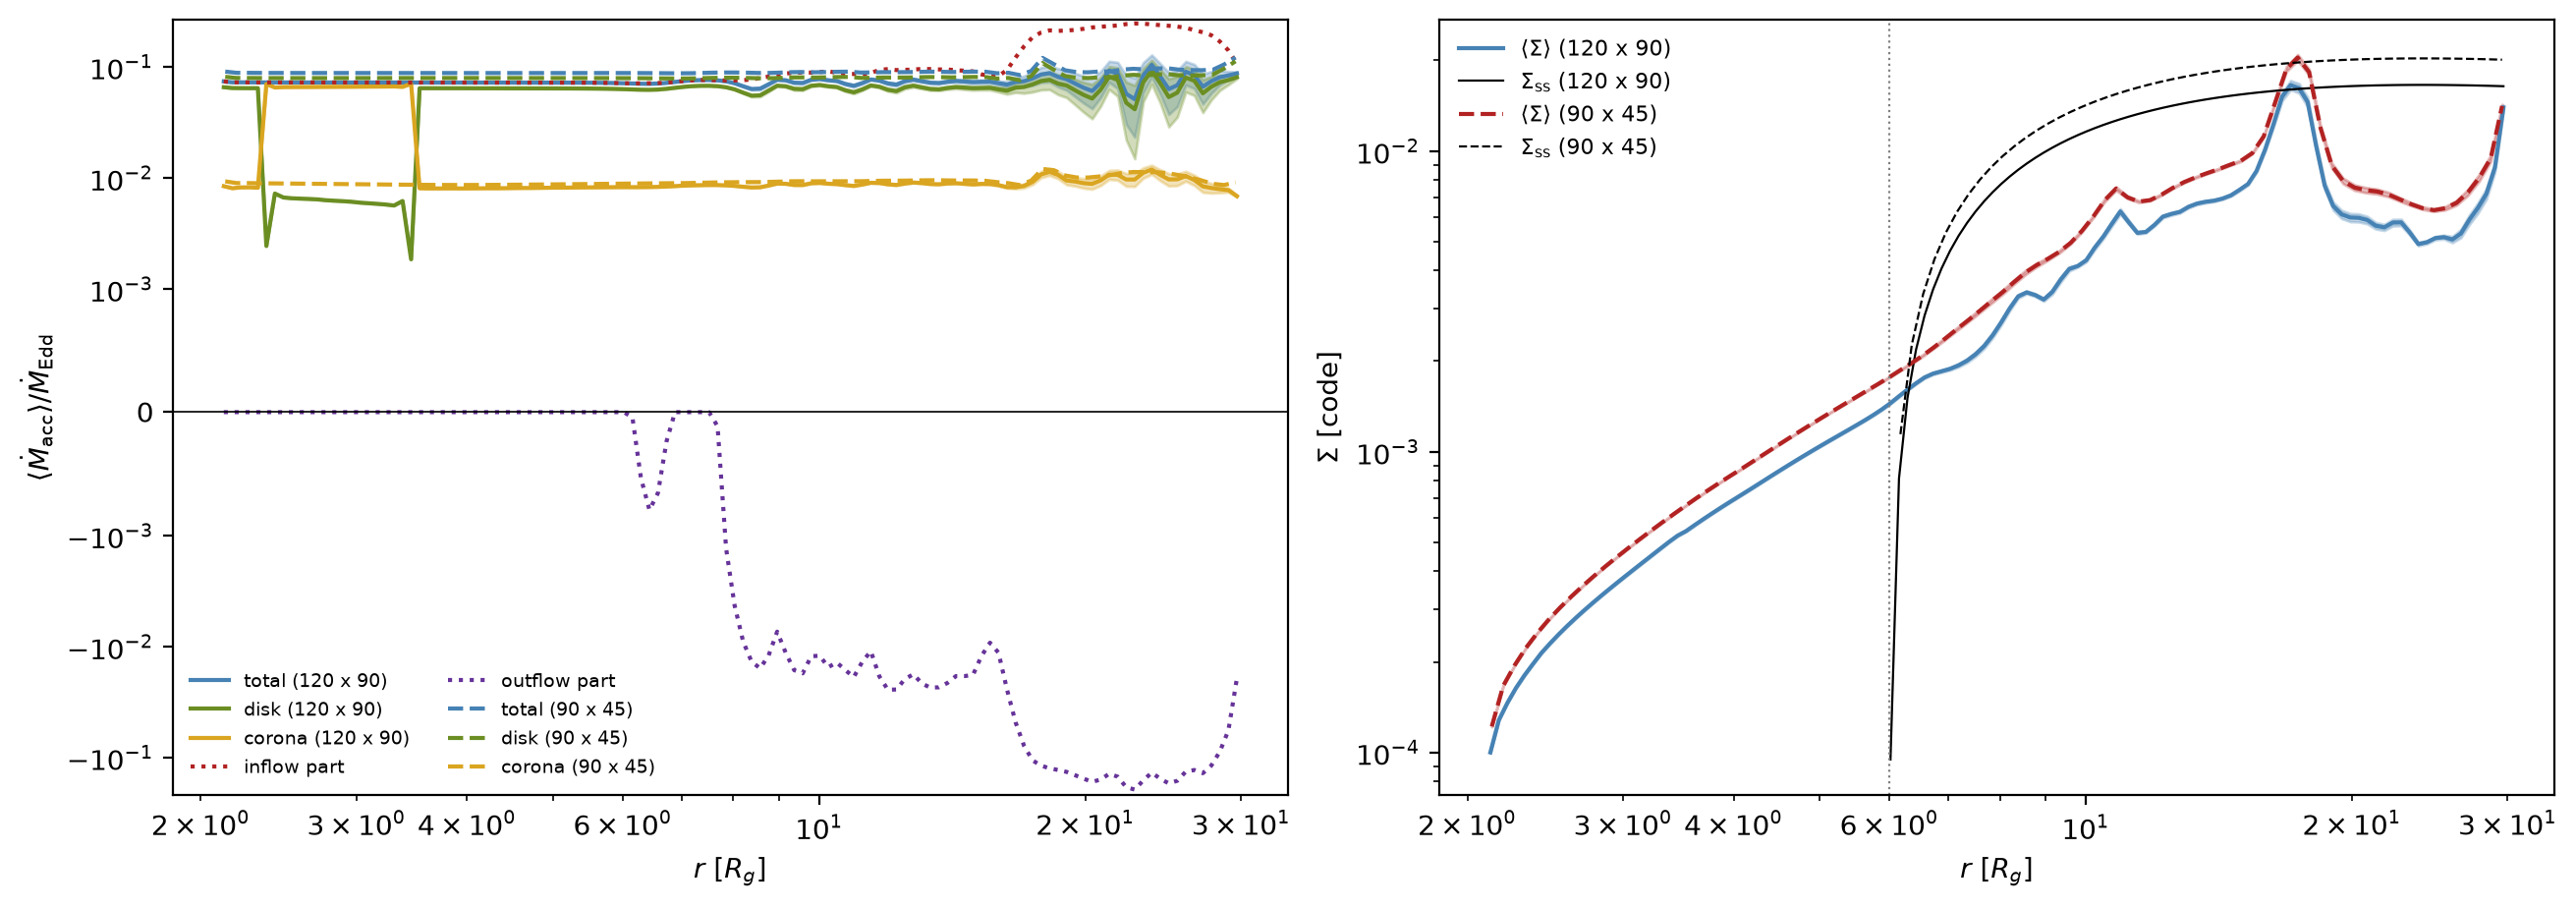

120 x 90:  <Mdot_acc(r_in)> = 0.0739 +- 0.0004 Mdot_Edd = 0.307 Msun/yr
   boundary cells relative to the interior median: r = 2.12: +2.4%, r = 2.17: +0.5%, r = 29.02: +15.9%, r = 29.67: +21.0%
90 x 45:  <Mdot_acc(r_in)> = 0.0905 +- 0.0003 Mdot_Edd = 0.376 Msun/yr
   boundary cells relative to the interior median: r = 2.13: +2.4%, r = 2.20: -0.1%, r = 28.70: +18.8%, r = 29.56: +37.1%


In [20]:
for run in RUNS:
    Cx, s, dt = run['C'], run['sel'], run['dt']
    run['mdot_in_mean'], run['mdot_in_se'] = mean_se(-Cx['mdot'][s, 0], dt)
    run['mdot_prof'], run['mdot_prof_se'] = mean_se(-Cx['mdot'][s], dt)
    run['sig_mean'], run['sig_se'] = mean_se(Cx['sigma'][s], dt)

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
ax = axs[0]
for run in RUNS:
    Cx, s, dt, r = run['C'], run['sel'], run['dt'], run['r']
    for k, (key, lab) in enumerate([('mdot', 'total'), ('mdot_d', 'disk'), ('mdot_c', 'corona')]):
        m, e = mean_se(-Cx[key][s] * scale, dt)
        ax.plot(r, m, color=f"C{k}", ls=run['ls'], label=f"{lab} ({run['label']})")
        if run is RUN:
            ax.fill_between(r, m - e, m + e, color=f"C{k}", alpha=0.3)
    if run is RUN:
        for k, (key, lab) in enumerate([('mdot_in', 'inflow part'), ('mdot_out', 'outflow part')]):
            ax.plot(r, mean_se(-Cx[key][s] * scale, dt)[0], color=f"C{k + 3}", ls=':', label=lab)
ax.axhline(0, color='k', lw=0.6)
ax.set_xscale('log'); ax.set_yscale('symlog', linthresh=1e-3)
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\langle\dot M_\mathrm{acc}\rangle / \dot M_\mathrm{Edd}$'); ax.legend(fontsize=7, ncol=2)

ax = axs[1]
for run in RUNS:
    r = run['r']
    ax.plot(r, run['sig_mean'], color=run['color'], ls=run['ls'], label=r'$\langle\Sigma\rangle$' + f" ({run['label']})")
    ax.fill_between(r, run['sig_mean'] - run['sig_se'], run['sig_mean'] + run['sig_se'], color=run['color'], alpha=0.3)
    R_ss = r[r > 6.0]
    if run['mdot_in_mean'] > 0:
        ax.plot(R_ss, run['mdot_in_mean'] / (3.0 * np.pi * nu_kin(R_ss)) * (1.0 - np.sqrt(6.0 / R_ss)), color='k', ls=run['ls'],
                lw=0.8, label=r'$\Sigma_\mathrm{ss}$' + f" ({run['label']})")
ax.axvline(6.0, color='gray', lw=0.8, ls=':')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\Sigma$ [code]'); ax.legend(fontsize=8)
plt.show()

for run in RUNS:
    m, r = run['mdot_prof'], run['r']
    interior = np.median(m[(r > 3.0) & (r < 25.0)])
    cells = ', '.join(f"r = {r[i]:.2f}: {m[i] / interior - 1:+.1%}" for i in [0, 1, -2, -1])
    print(f"{run['label']}:  <Mdot_acc(r_in)> = {run['mdot_in_mean'] * scale:.4f} +- {run['mdot_in_se'] * scale:.4f} Mdot_Edd"
          f" = {run['mdot_in_mean'] * MDOT0 * YEAR / CONST_Msun:.3f} Msun/yr")
    print(f"   boundary cells relative to the interior median: {cells}")

#### 3.3. Effective Viscosity

In a steady disk the mean accretion rate and surface density fix the effective kinematic viscosity, whatever transports the angular
momentum, through the same relation as $\Sigma_\mathrm{ss}$. Written as an effective $\alpha$ with the viscosity law of the model,

$$
\nu_\mathrm{eff}(R) = \frac{\langle\dot M_\mathrm{acc}\rangle}{3\pi\,\langle\Sigma\rangle}\left(1 - \sqrt{\frac{R_\mathrm{isco}}{R}}\right), \qquad
\alpha_\mathrm{eff}(R) = \frac{\nu_\mathrm{eff}(R)}{\tfrac{2}{3}\,\epsilon^2 R^{1/2}} ,
$$

so $\alpha_\mathrm{eff}/\alpha = 1$ means that the explicit viscosity carries the accretion, and $\alpha_\mathrm{eff}/\alpha > 1$ that
an additional transport acts: the waves, Reynolds stresses of the mean flow, or numerical viscosity. Numerical viscosity decreases
with resolution, so a ratio that is the same in both runs points to a physical transport. The mass weighted inflow speed
$\bar v_r = \langle\dot M_\mathrm{acc}\rangle / (2\pi R\langle\Sigma\rangle)$ is compared with the steady $\alpha$-disk value
$\tfrac{3\nu}{2R}\left(1 - \sqrt{R_\mathrm{isco}/R}\right)^{-1}$. The uncertainty combines the standard errors of
$\langle\dot M_\mathrm{acc}\rangle$ and $\langle\Sigma\rangle$, and is meaningful only inside $R_\mathrm{eq}$.

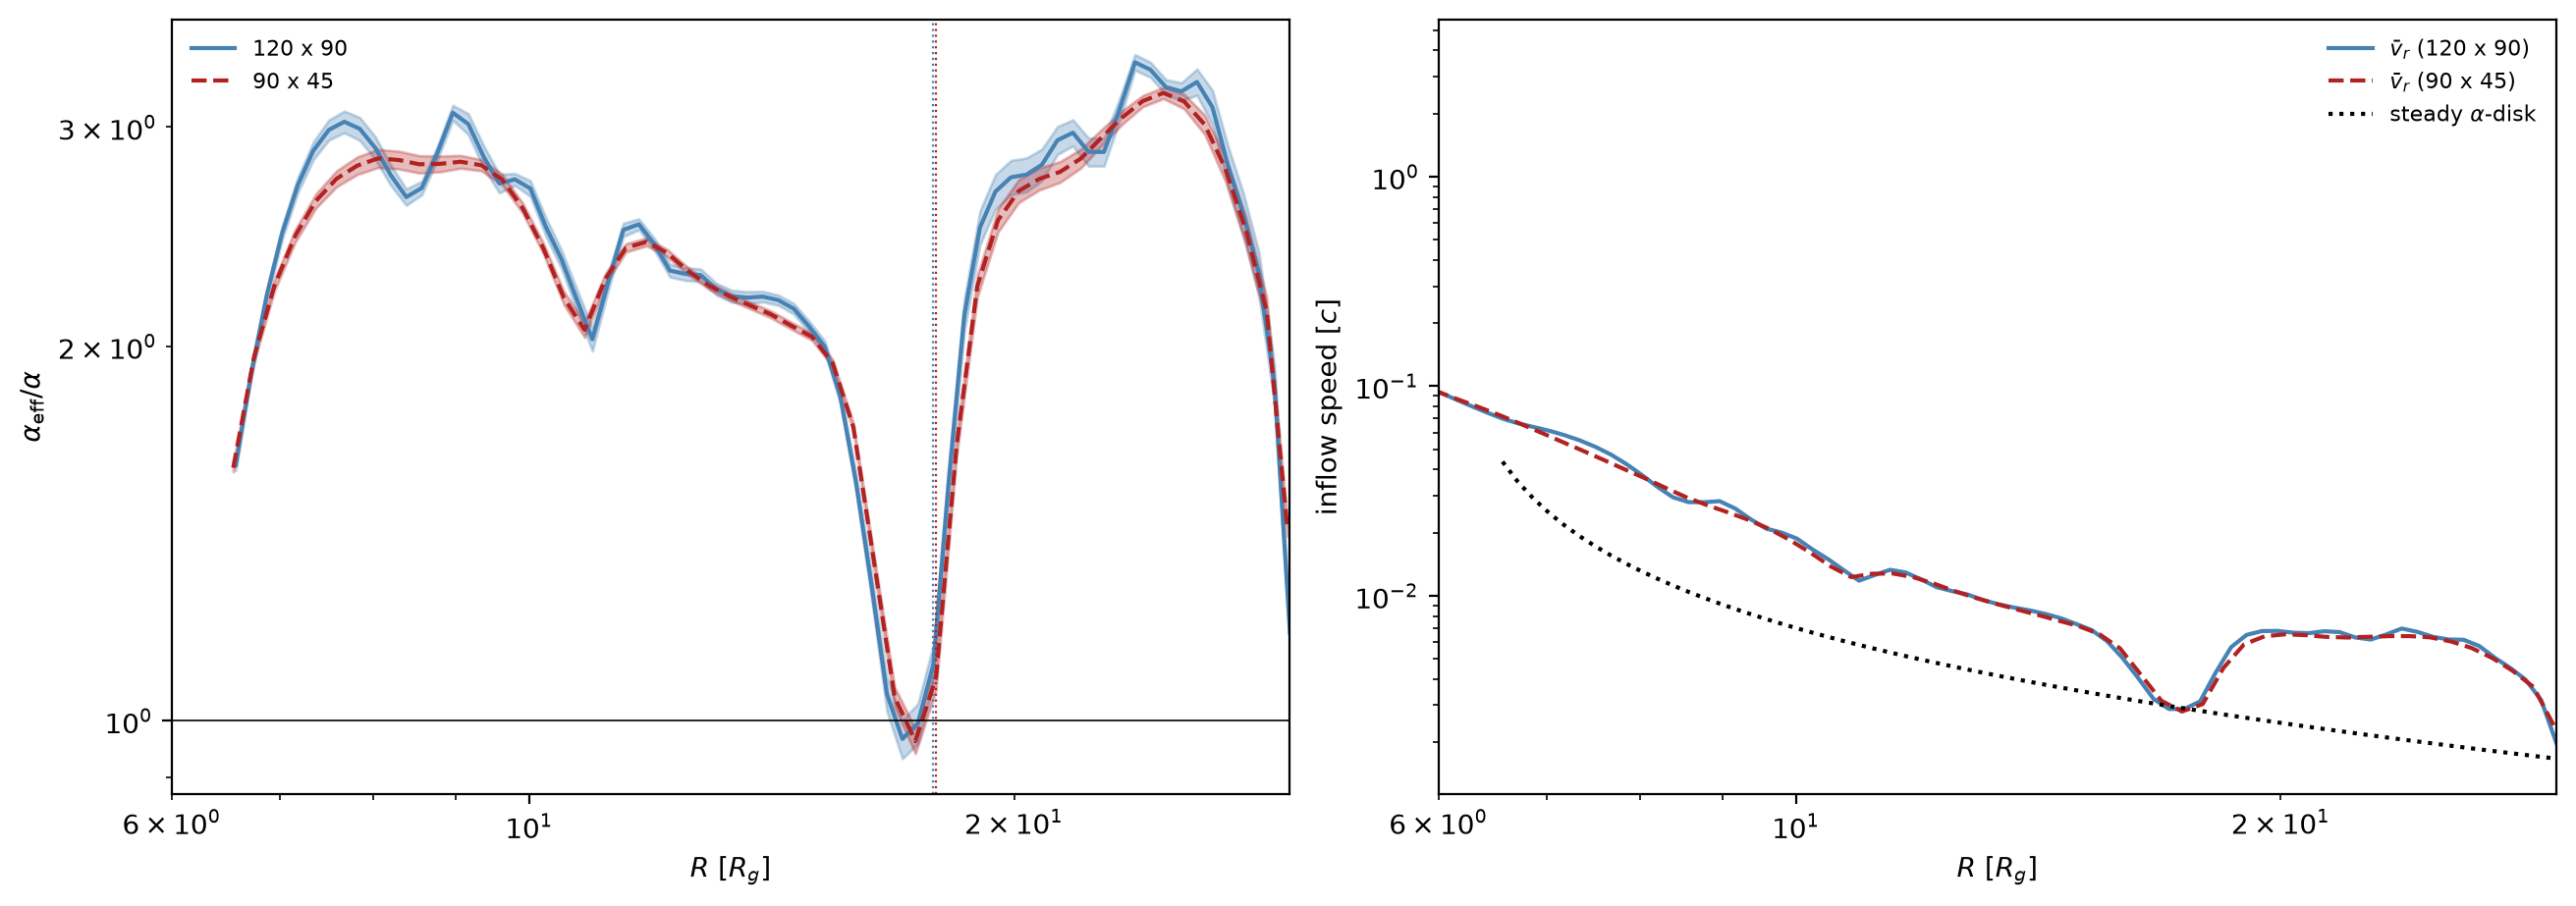

R = 10.0:  120 x 90: alpha_eff / alpha = 2.68 +- 0.04,   90 x 45: alpha_eff / alpha = 2.53 +- 0.02
R = 15.0:  120 x 90: alpha_eff / alpha = 2.06 +- 0.02,   90 x 45: alpha_eff / alpha = 2.03 +- 0.01
R = 20.0:  120 x 90: alpha_eff / alpha = 2.74 +- 0.09,   90 x 45: alpha_eff / alpha = 2.63 +- 0.06


In [21]:
def effective_alpha(run):
    r = run['r']
    w = 1.0 - np.sqrt(6.0 / np.maximum(r, 6.0))
    nu_eff = run['mdot_in_mean'] * w / (3.0 * np.pi * run['sig_mean'])
    a_eff = nu_eff / (2.0 / 3.0 * EPS**2 * np.sqrt(r))
    rel = np.sqrt((run['mdot_in_se'] / run['mdot_in_mean'])**2 + (run['sig_se'] / run['sig_mean'])**2)
    v_mass = run['mdot_in_mean'] / (2.0 * np.pi * r * run['sig_mean'])
    return np.where(r > 6.5, a_eff / ALPHA, np.nan), rel, v_mass

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
for run in RUNS:
    r = run['r']
    ratio, rel, v_mass = effective_alpha(run)
    run['alpha_ratio'], run['alpha_ratio_rel'] = ratio, rel
    axs[0].plot(r, ratio, color=run['color'], ls=run['ls'], label=run['label'])
    axs[0].fill_between(r, ratio * (1 - rel), ratio * (1 + rel), color=run['color'], alpha=0.3)
    axs[0].axvline(run['R_eq_stats'][1], color=run['color'], ls=':', lw=0.8)
    axs[1].plot(r, v_mass, color=run['color'], ls=run['ls'], label=r'$\bar v_r$' + f" ({run['label']})")
R_ss = R_C[R_C > 6.5]
axs[1].plot(R_ss, 1.5 * nu_kin(R_ss) / R_ss / (1.0 - np.sqrt(6.0 / R_ss)), 'k:', label=r'steady $\alpha$-disk')
axs[0].axhline(1.0, color='k', lw=0.6)
axs[0].set_xscale('log'); axs[0].set_yscale('log'); axs[0].set_xlim(6, R_C[-1])
axs[0].set_xlabel(r'$R\ [R_g]$'); axs[0].set_ylabel(r'$\alpha_\mathrm{eff} / \alpha$'); axs[0].legend(fontsize=8)
axs[1].set_xscale('log'); axs[1].set_yscale('log'); axs[1].set_xlim(6, R_C[-1])
axs[1].set_xlabel(r'$R\ [R_g]$'); axs[1].set_ylabel(r'inflow speed $[c]$'); axs[1].legend(fontsize=8)
plt.show()

for R0 in [10.0, 15.0, 20.0]:
    print(f"R = {R0:4.1f}:  " + ',   '.join(
        f"{run['label']}: alpha_eff / alpha = {np.interp(R0, run['r'], run['alpha_ratio']):.2f}"
        f" +- {np.interp(R0, run['r'], run['alpha_ratio'] * run['alpha_ratio_rel']):.2f}" for run in RUNS))

#### 3.4. Variability at the Inner Boundary

The power spectral density of the accretion rate through the inner boundary, from the spectral series of each run, estimated with
Welch's method (Hann window, $50\%$ overlap, linear trend removed per segment),

$$
P(\nu_f) = \frac{2\,\Delta t}{N_\mathrm{seg}\, U}\sum_{s}\left|\sum_{k} w_k\, x_{s,k}\, e^{-2\pi i \nu_f t_k}\right|^2, \qquad U = \sum_k w_k^2 ,
$$

with frequencies in $t_g^{-1}$ and in $\mathrm{day}^{-1}$, $1\,t_g^{-1} = 86400/t_g$ per day. The segment length is chosen so that
there are at least `WELCH_SEG` segments, and at most `WELCH_TSEG` long. The Nyquist frequency is $\nu_\mathrm{Ny} = 1/(2\Delta t)$.
The peak frequency is refined by a parabola through the logarithm of the three highest bins.

120 x 90: peak 2.863e-03 / t_g (bin 4.0e-04),  period 349 t_g = 1.99 days,  Nyquist 1.000e-01 / t_g
90 x 45: peak 2.870e-03 / t_g (bin 4.0e-04),  period 348 t_g = 1.99 days,  Nyquist 1.000e-02 / t_g


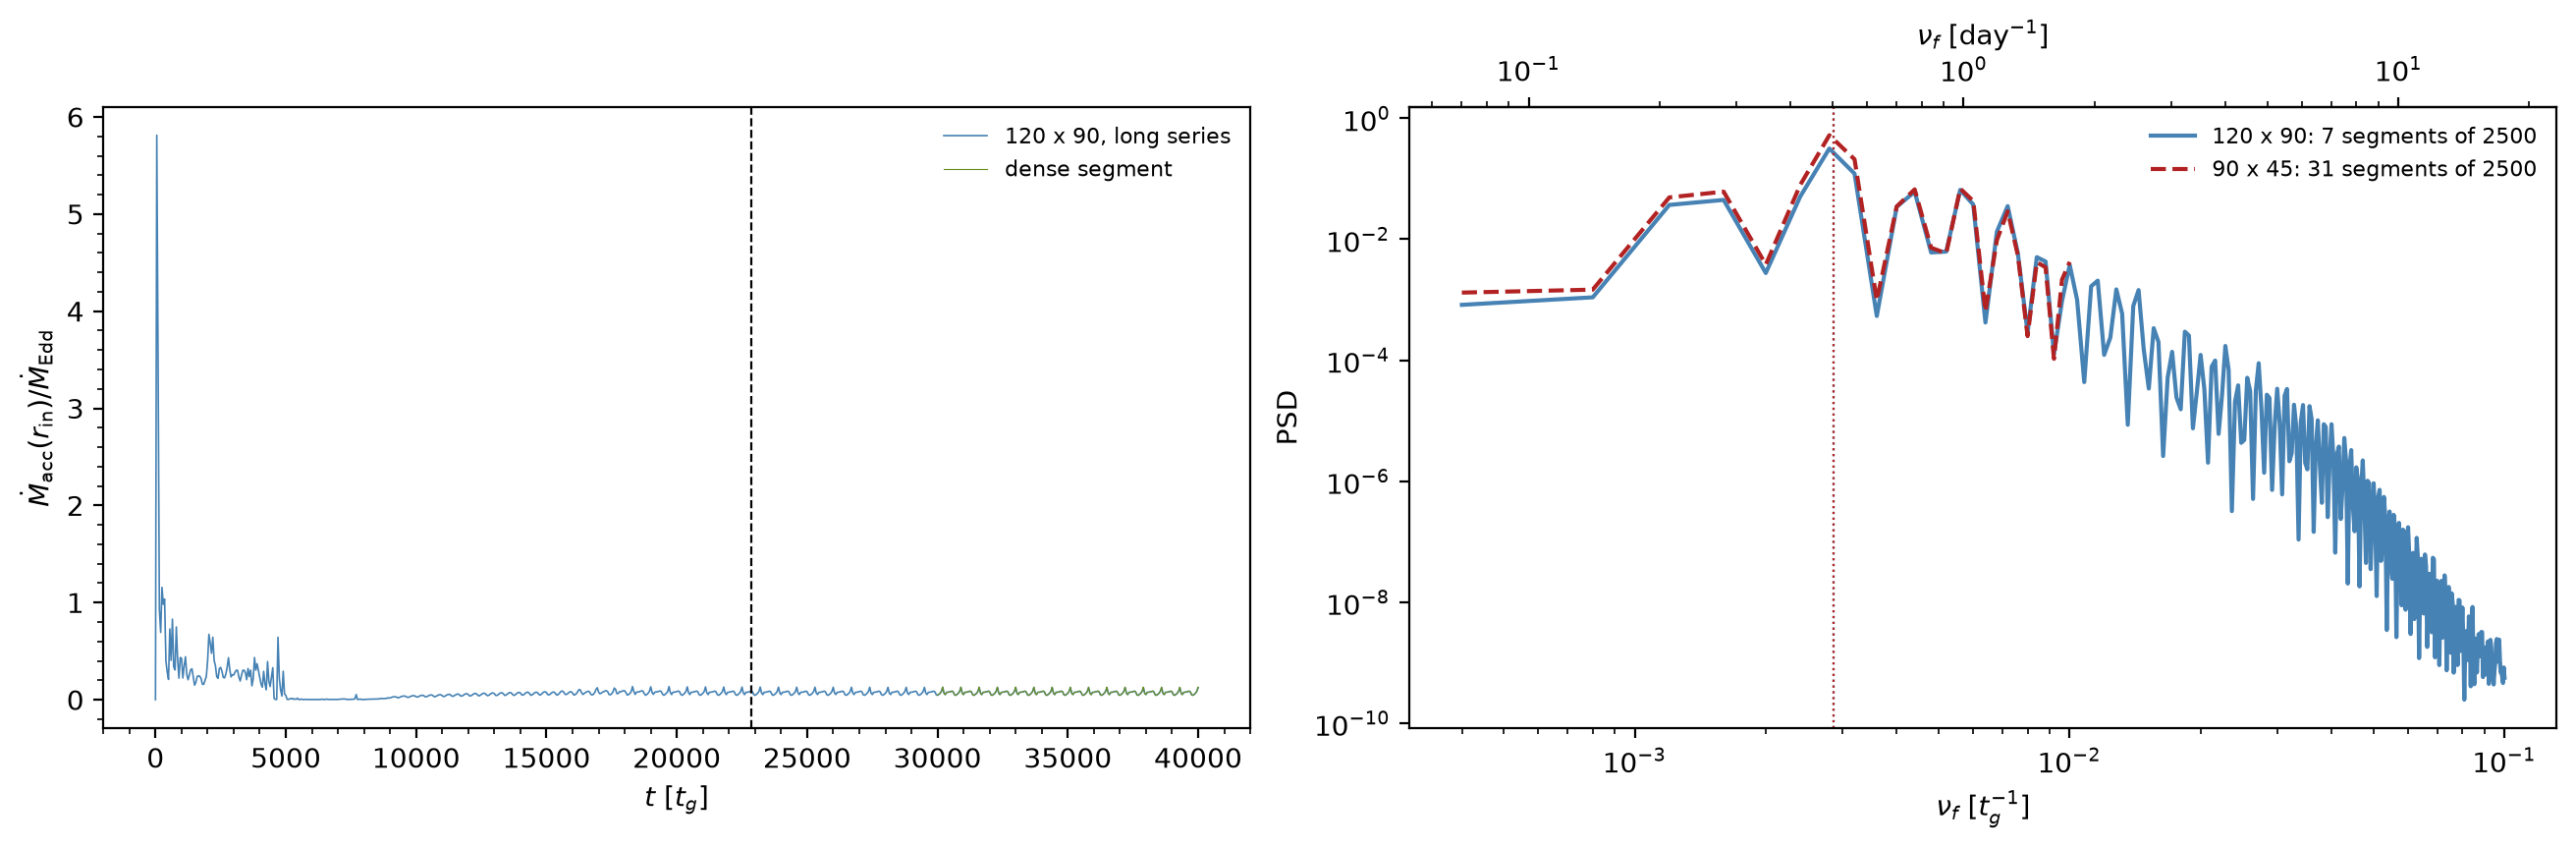

In [22]:
def welch_len(n, dt):
    # segment length, number of overlapping segments and number of independent segments
    nper = max(min(int(2 * n / (WELCH_SEG + 1)), frames(WELCH_TSEG, dt)), 8)
    nper = min(nper, n)
    return nper, (n - nper) // (nper // 2) + 1, max(n // nper, 1)

def welch(x, dt):
    nper = welch_len(x.shape[0], dt)[0]
    return signal.welch(x, fs=1.0 / dt, window='hann', nperseg=nper, noverlap=nper // 2, detrend='linear', axis=0)

def peak_frequency(f, P):
    # frequency of the maximum above f = 0, refined by a parabola in log P
    k = int(np.argmax(P[1:])) + 1
    if 1 < k < f.size - 1 and np.all(P[k - 1:k + 2] > 0):
        y = np.log(P[k - 1:k + 2])
        den = y[0] - 2.0 * y[1] + y[2]
        shift = 0.5 * (y[0] - y[2]) / den if den != 0 else 0.0
        return f[k] + np.clip(shift, -0.5, 0.5) * (f[1] - f[0]), f[1] - f[0]
    return f[k], f[1] - f[0]

fig, axs = plt.subplots(1, 2, figsize=[13, 4.2])
axs[0].plot(T, mdot_acc_in * scale, lw=0.6, label=f"{RUN['label']}, long series")
if RUN['D'] is not None:
    axs[0].plot(RUN['D']['t'], -RUN['D']['mdot'][:, 0] * scale, lw=0.4, label='dense segment')
axs[0].axvline(T_STEADY, color='k', ls='--', lw=0.8)
axs[0].set_xlabel(r'$t\ [t_g]$'); axs[0].set_ylabel(r'$\dot M_\mathrm{acc}(r_\mathrm{in}) / \dot M_\mathrm{Edd}$'); axs[0].legend(fontsize=8)
for run in RUNS:
    x = -run['S']['mdot'][:, 0] * scale
    f_in, P_in = welch(x, run['dt_s'])
    f_pk, df = peak_frequency(f_in, P_in)
    run['f_peak_in'] = f_pk
    nper, nseg, _ = welch_len(x.size, run['dt_s'])
    axs[1].loglog(f_in[1:], P_in[1:], color=run['color'], ls=run['ls'], label=f"{run['label']}: {nseg} segments of {nper * run['dt_s']:.0f}")
    axs[1].axvline(f_pk, color=run['color'], ls=':', lw=0.8)
    print(f"{run['label']}: peak {f_pk:.3e} / t_g (bin {df:.1e}),  period {1 / f_pk:.0f} t_g = {T_G / f_pk / DAY:.2f} days,"
          f"  Nyquist {0.5 / run['dt_s']:.3e} / t_g")
axs[1].set_xlabel(r'$\nu_f\ [t_g^{-1}]$'); axs[1].set_ylabel('PSD'); axs[1].legend(fontsize=8)
sec = axs[1].secondary_xaxis('top', functions=(lambda x: x * DAY / T_G, lambda x: x * T_G / DAY))
sec.set_xlabel(r'$\nu_f$ [day$^{-1}$]')
plt.show()

#### 3.5. Mass Budget

For the mass $M_{ab}$ between the cell centres $r_a$ and $r_b$ closest to `R_BUDGET`, continuity gives

$$
\frac{\mathrm{d}M_{ab}}{\mathrm{d}t} = \dot M(r_a) - \dot M(r_b) + \dot M_\mathrm{floor},
$$

with $\dot M$ positive outward. Integrated in time from $t_0$,

$$
\Delta M_\mathrm{floor}(t) = \left[M_{ab}(t) - M_{ab}(t_0)\right] - \int_{t_0}^t \left[\dot M(r_a) - \dot M(r_b)\right]\mathrm{d}t' .
$$

The control volume stays away from the boundary cells, whose cell centred fluxes are biased (Section 3.2). For comparison the
budget is also evaluated between the first and the last cell centre.

The fluxes are only sampled at the output cadence, so the integral carries a sampling error. It is estimated by evaluating the
same trapezoidal integral with only the even and only the odd samples, $I_\mathrm{even}$ and $I_\mathrm{odd}$, at twice the
cadence,

$$
\sigma_I = \max\left(\left|I - I_\mathrm{even}\right|, \left|I - I_\mathrm{odd}\right|\right) .
$$

For a flux that varies faster than the cadence the samples are nearly independent, and this difference equals the random sampling
error of $I$. For a well resolved flux it is the truncation error at twice the cadence, which overestimates the error of $I$. The
lag-one autocorrelation of the net flux tells which case applies: close to one the flux is resolved, far below one it is not. The
budget is evaluated on the spectral series, i.e. the dense segment if there is one, and the band in the plots grows linearly in
time to the final $\sigma_I$. The floors can only add mass, so a negative residual beyond its error means the fluxes are not
representative.

r = 2.48 to 24.85:  residual -1.698e+00 +- 3.2e-02  (z = -53.7),  -3.4% of the mass accreted through r_a,  lag-one autocorrelation 0.99
r = 2.12 to 29.67 (boundary cells):  residual -9.234e+00 +- 1.2e-03  (z = -7674.8),  -18.2% of the mass accreted through r_a,  lag-one autocorrelation 0.99


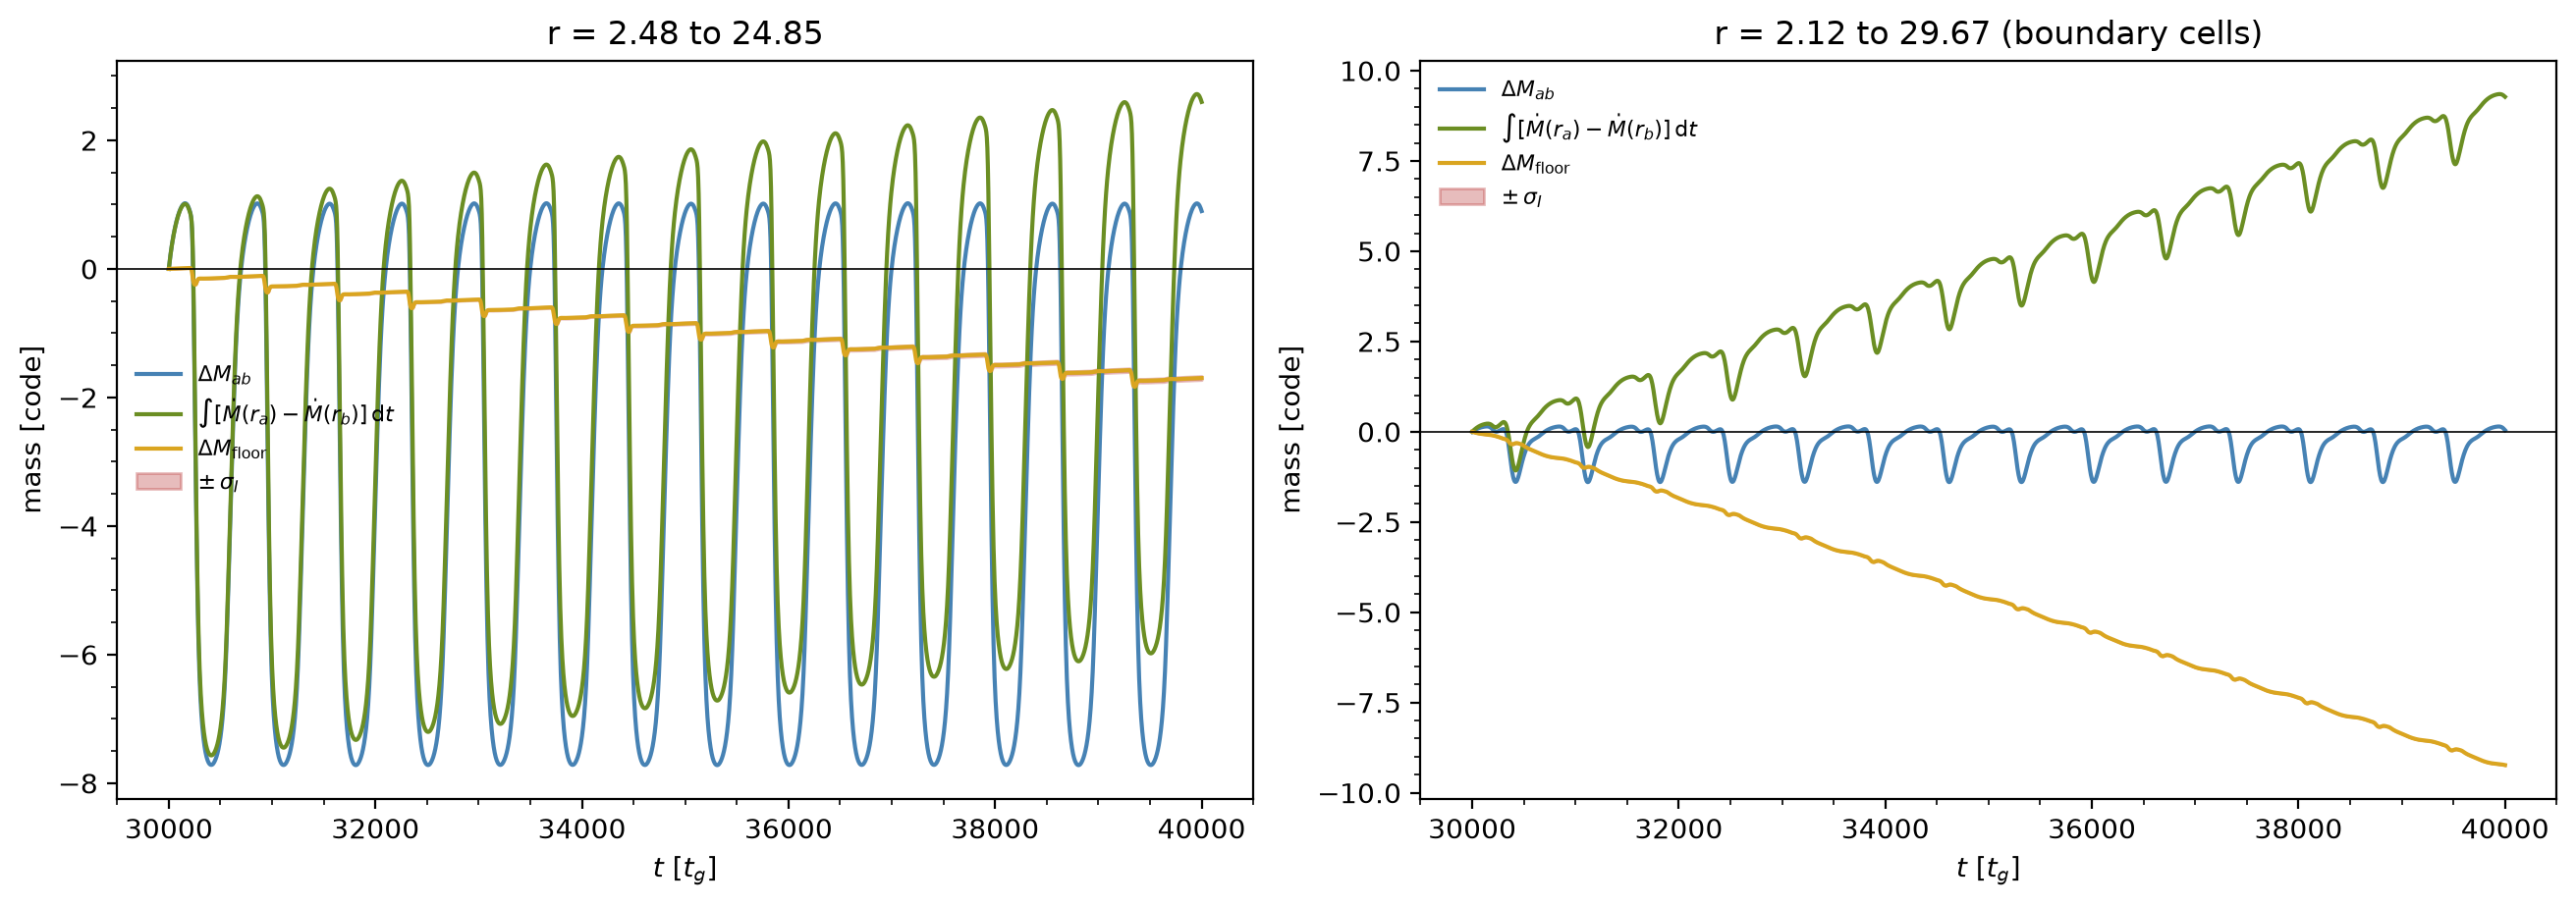

In [23]:
def shell_mass(Cx, a, b):
    # mass between the cell centres a < b
    return Cx['m_hi'][:, a] + Cx['m_lo'][:, b] + np.sum(Cx['m_lo'][:, a + 1:b] + Cx['m_hi'][:, a + 1:b], axis=1)

def cumulative_trapezoid(t, y):
    return np.concatenate([[0.0], np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(t))])

def mass_budget(Cx, a, b):
    t = Cx['t']
    net = Cx['mdot'][:, a] - Cx['mdot'][:, b]
    flux_int = cumulative_trapezoid(t, net)
    # sampling error from the integrals over the even and the odd samples, evaluated over their common range
    t_e, t_o = t[0::2], t[1::2]
    I_full_e = np.interp(t_e[-1], t, flux_int) - np.interp(t_e[0], t, flux_int)
    I_full_o = np.interp(t_o[-1], t, flux_int) - np.interp(t_o[0], t, flux_int)
    err = max(abs(I_full_e - cumulative_trapezoid(t_e, net[0::2])[-1]), abs(I_full_o - cumulative_trapezoid(t_o, net[1::2])[-1]))
    M_ab = shell_mass(Cx, a, b)
    dM = M_ab - M_ab[0]
    x = net - net.mean()
    ac1 = np.sum(x[1:] * x[:-1]) / np.sum(x * x)
    return dict(t=t, dM=dM, flux=flux_int, floor=dM - flux_int, err=(t - t[0]) / (t[-1] - t[0]) * err, ac1=ac1,
                inflow=-Cx['mdot'][:, a].mean())

S, dt_s = RUN['S'], RUN['dt_s']
IA = int(np.argmin(np.abs(R_C - R_BUDGET[0])))
IB = int(np.argmin(np.abs(R_C - R_BUDGET[1])))
budgets = [(f"r = {R_C[IA]:.2f} to {R_C[IB]:.2f}", mass_budget(S, IA, IB)),
           (f"r = {R_C[0]:.2f} to {R_C[-1]:.2f} (boundary cells)", mass_budget(S, 0, NR - 1))]

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
for ax, (title, B) in zip(axs, budgets):
    ax.plot(B['t'], B['dM'], label=r'$\Delta M_{ab}$')
    ax.plot(B['t'], B['flux'], label=r'$\int [\dot M(r_a) - \dot M(r_b)]\,\mathrm{d}t$')
    ax.plot(B['t'], B['floor'], label=r'$\Delta M_\mathrm{floor}$')
    ax.fill_between(B['t'], B['floor'] - B['err'], B['floor'] + B['err'], alpha=0.3, color='firebrick', label=r'$\pm\,\sigma_I$')
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(title); ax.set_xlabel(r'$t\ [t_g]$'); ax.set_ylabel('mass [code]'); ax.legend(fontsize=8)
    tau = B['t'][-1] - B['t'][0]
    print(f"{title}:  residual {B['floor'][-1]:+.3e} +- {B['err'][-1]:.1e}  (z = {B['floor'][-1] / B['err'][-1]:+.1f}),"
          f"  {B['floor'][-1] / (B['inflow'] * tau):+.1%} of the mass accreted through r_a,  lag-one autocorrelation {B['ac1']:.2f}")
plt.show()
B_MAIN = budgets[0][1]
FLOOR_FRAC = B_MAIN['floor'][-1] / (B_MAIN['inflow'] * (B_MAIN['t'][-1] - B_MAIN['t'][0]))
FLOOR_Z = B_MAIN['floor'][-1] / B_MAIN['err'][-1]

### 4. Density Waves

The quasi-steady disk carries quasi-periodic density enhancements that travel outward. All wave diagnostics use the relative
perturbation of the surface density in the spectral series,

$$
\delta(r, t) = \frac{\Sigma(r,t)}{\langle\Sigma\rangle_t(r)} - 1 .
$$

A cadence of $50\,t_g$ resolves periods above $100\,t_g$, but only about seven samples per wave period; the dense segment, if
present, resolves the pulse shape and the short travel times between neighbouring cells.

#### 4.1. Space–Time Diagram

Outward travelling waves appear as ridges tilted towards larger $r$ with time. The left panel shows the steady window of the long
series, the right panel the last $3000\,t_g$ of the spectral series.

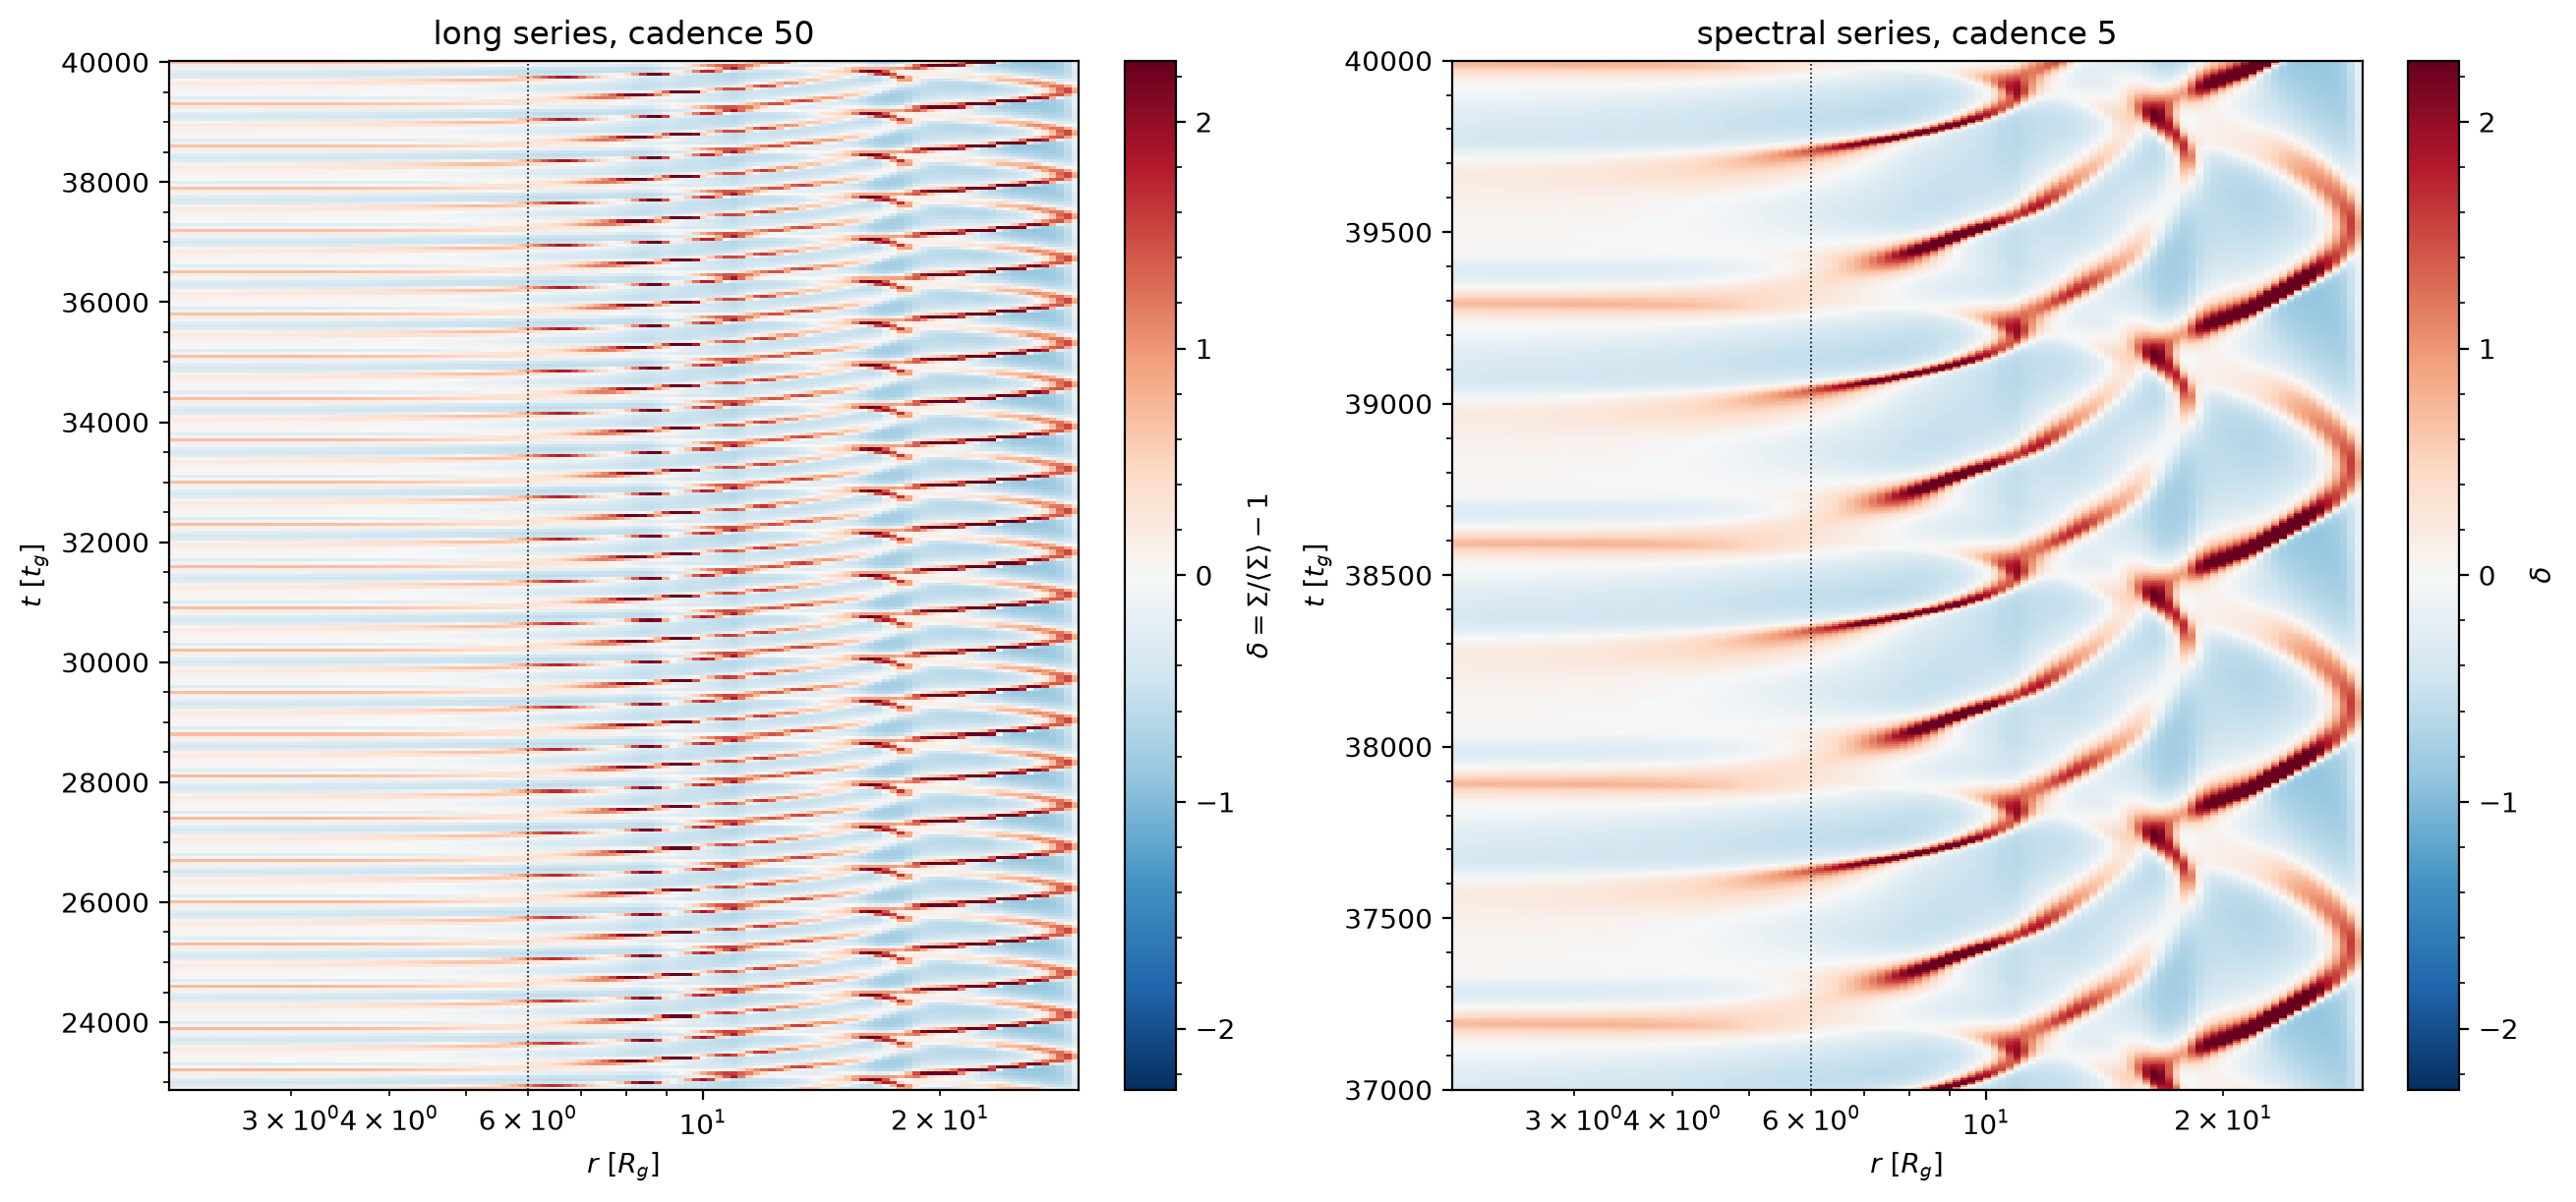

In [24]:
for run in RUNS:
    run['delta'] = run['S']['sigma'] / run['S']['sigma'].mean(axis=0)[None, :] - 1.0

DELTA_LONG = C['sigma'][SEL] / C['sigma'][SEL].mean(axis=0)[None, :] - 1.0
amp = np.nanpercentile(np.abs(DELTA_LONG), 99)
dnorm = TwoSlopeNorm(vmin=-amp, vcenter=0.0, vmax=amp)
fig, axs = plt.subplots(1, 2, figsize=[13, 6])
spacetime(axs[0], TS, DELTA_LONG, dnorm, 'RdBu_r', r'$\delta = \Sigma / \langle\Sigma\rangle - 1$')
spacetime(axs[1], RUN['ts'], RUN['delta'], dnorm, 'RdBu_r', r'$\delta$', tlim=(max(RUN['ts'][0], RUN['ts'][-1] - 3000), RUN['ts'][-1]))
axs[0].set_title(f"long series, cadence {DT_OUT:g}"); axs[1].set_title(f"spectral series, cadence {RUN['dt_s']:g}")
for ax in axs:
    ax.axvline(6.0, color='k', lw=0.6, ls=':')
plt.show()

#### 4.2. Frequency–Radius Diagram

The power spectrum $P(r, \nu_f)$ of $\delta(r,t)$ at every radius, with the characteristic local frequencies of the disk overlaid:
orbital $\Omega/2\pi$, epicyclic $\kappa/2\pi$, thermal $\alpha\Omega_N/2\pi$ and viscous $1/t_\nu$. A mode launched at one radius
and travelling through the disk appears at the same frequency at all radii, while locally excited oscillations follow one of the
local frequencies.

The radius averaged spectrum normalizes each radius to unit total power first, $\langle P\rangle_r = \langle P(r,\nu_f)/\sum_{\nu_f}
P(r,\nu_f)\rangle_r$, so that it compares the spectral shape of both runs independently of the wave amplitude. The dominant
frequency $\nu_\mathrm{peak}$ is its maximum, with an uncertainty of about half a frequency bin.

120 x 90: dominant frequency 2.862e-03 +- 2.0e-04 / t_g,  period 349 t_g = 1.99 days
90 x 45: dominant frequency 2.869e-03 +- 2.0e-04 / t_g,  period 349 t_g = 1.99 days


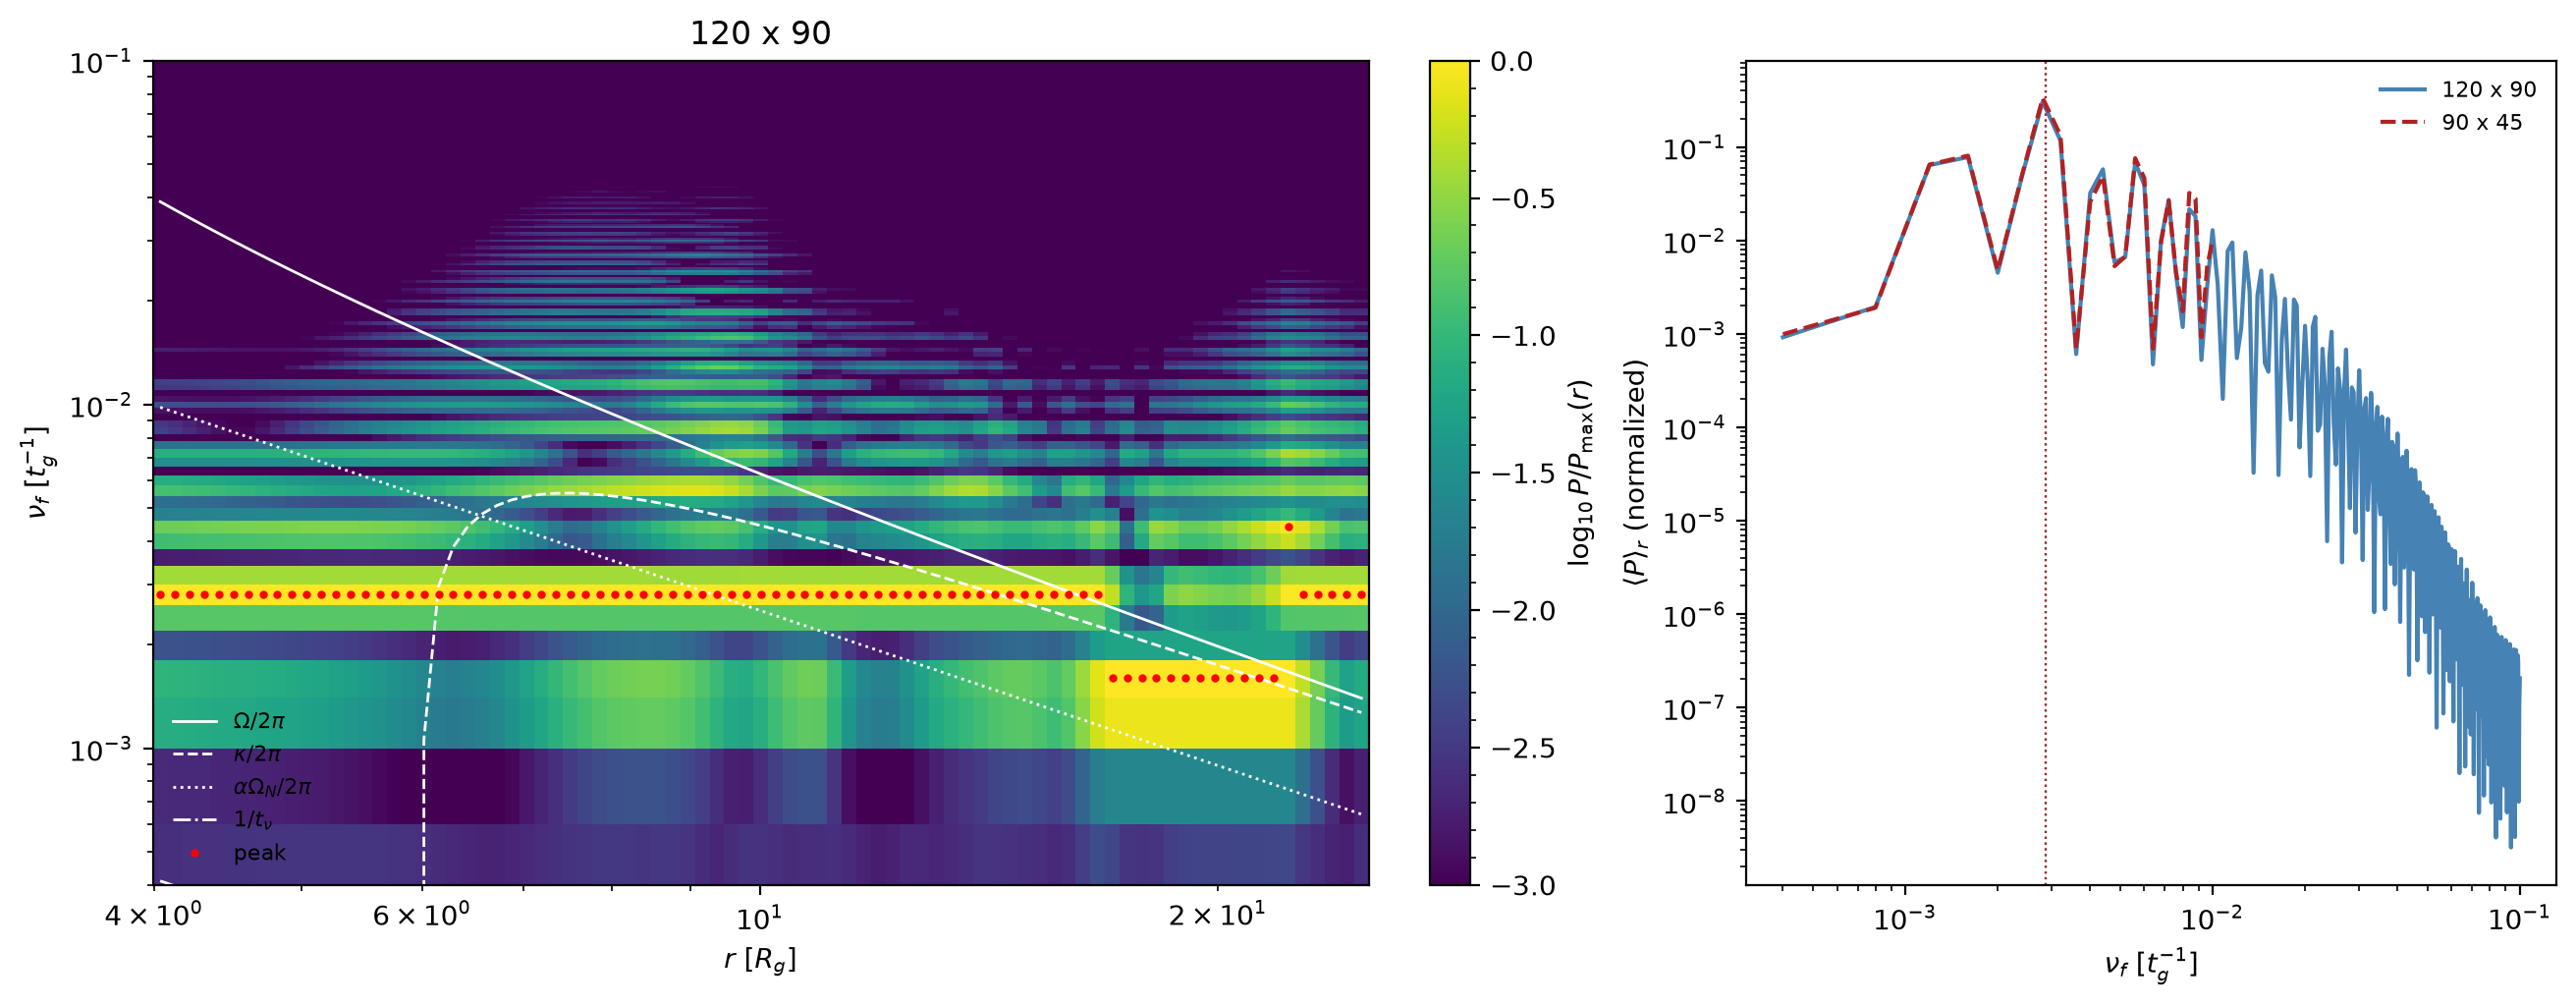

In [25]:
def wave_spectrum(run):
    r = run['r']
    w = (r >= R_WAVE[0]) & (r <= R_WAVE[1])
    f, P = welch(run['delta'][:, w], run['dt_s'])
    glob = np.concatenate([[0.0], (P[1:] / P[1:].sum(axis=0, keepdims=True)).mean(axis=1)])
    f_pk, df = peak_frequency(f, glob)
    return f, P, w, glob, f_pk, df

for run in RUNS:
    run['f_w'], run['P_w'], run['wave'], run['P_glob'], run['f_peak'], run['df_peak'] = wave_spectrum(run)
F_PEAK = RUN['f_peak']

fig, axs = plt.subplots(1, 2, figsize=[13, 5], gridspec_kw={'width_ratios': [3, 2]})
ax = axs[0]
f_w, P_w, WAVE = RUN['f_w'], RUN['P_w'], RUN['wave']
Rw = R_C[WAVE]
im = ax.pcolormesh(Rw, f_w[1:], np.log10(P_w[1:] / P_w[1:].max(axis=0, keepdims=True)), cmap='viridis',
                   vmin=-3, vmax=0, shading='nearest', rasterized=True)
plt.colorbar(im, ax=ax, label=r'$\log_{10} P / P_\max(r)$')
ax.plot(Rw, omega_pw(Rw) / (2 * np.pi), 'w-', lw=1, label=r'$\Omega/2\pi$')
ax.plot(Rw, kappa_epi(Rw) / (2 * np.pi), 'w--', lw=1, label=r'$\kappa/2\pi$')
ax.plot(Rw, ALPHA * omega_newton(Rw) / (2 * np.pi), 'w:', lw=1, label=r'$\alpha\Omega_N/2\pi$')
ax.plot(Rw, 1 / t_viscous(Rw), 'w-.', lw=1, label=r'$1/t_\nu$')
ax.plot(Rw, f_w[1:][np.argmax(P_w[1:], axis=0)], 'r.', ms=4, label='peak')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(f_w[1], f_w[-1])
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\nu_f\ [t_g^{-1}]$'); ax.legend(fontsize=8, loc='lower left')
ax.set_title(RUN['label'])

ax = axs[1]
for run in RUNS:
    ax.loglog(run['f_w'][1:], run['P_glob'][1:], color=run['color'], ls=run['ls'], label=run['label'])
    ax.axvline(run['f_peak'], color=run['color'], ls=':', lw=0.8)
    print(f"{run['label']}: dominant frequency {run['f_peak']:.3e} +- {0.5 * run['df_peak']:.1e} / t_g,"
          f"  period {1 / run['f_peak']:.0f} t_g = {T_G / run['f_peak'] / DAY:.2f} days")
ax.set_xlabel(r'$\nu_f\ [t_g^{-1}]$'); ax.set_ylabel(r'$\langle P\rangle_r$ (normalized)'); ax.legend(fontsize=8)
plt.show()

#### 4.3. Phase Speed

The phase speed follows from the cross spectral density of $\delta$ at each radius $r$ with $\delta$ at the reference radius
$r_0 =$ `R_PHASE_REF`, at the dominant frequency $\nu_\mathrm{peak}$. A wave that reaches $r$ a time $\Delta t(r)$ after $r_0$ has
the phase lag

$$
\varphi(r) = -\arg P_{0r}(\nu_\mathrm{peak}) = 2\pi\nu_\mathrm{peak}\,\Delta t(r), \qquad P_{0r} = \langle \hat\delta_0^*\, \hat\delta_r \rangle ,
$$

unwrapped from $r_0$ outward and inward, cell by cell. The local phase speed is the inverse slope of $\varphi(r)$,

$$
v_p(r) = 2\pi\nu_\mathrm{peak}\left(\frac{\mathrm{d}\varphi}{\mathrm{d}r}\right)^{-1},
$$

from a straight line fit over $r(1 \pm$ `FIT_FRAC`$)$, and a mean phase speed from one fit over $r_0 \leq r \leq 15$.

Phases are trusted where the magnitude squared coherence $\gamma^2 = |P_{0r}|^2/(P_{00} P_{rr})$ exceeds its $95\%$ significance
level for $n_d$ independent segments, $\gamma^2_\mathrm{crit} = 1 - 0.05^{1/(n_d - 1)}$, and where the fundamental still carries at
least `P_FUND_MIN` of the peak power of the local spectrum. Further out, pairs of pulses merge and the spectrum moves to the
subharmonic, so the phase at $\nu_\mathrm{peak}$ loses its meaning. Only the contiguous trusted region around $r_0$ is used. The
phase error is $\sigma_\varphi = \sqrt{(1 - \gamma^2)/(2 n_d \gamma^2)}$, and the fit error is the larger of the one from
$\sigma_\varphi$ and the one from the scatter of the residuals. Note that with a single segment the coherence is identically one,
which is why the spectra use at least `WELCH_SEG` segments.

The phase speed is compared with the sound speeds in the midplane: the adiabatic speed of the gas–radiation mixture and the
isothermal one,

$$
c_\mathrm{ad}^2 = \frac{\gamma\, p + \tfrac{4}{3}\, p_r}{\rho}, \qquad c_\mathrm{iso}^2 = \frac{p + p_r}{\rho}, \qquad p_r = \frac{E_r}{3},
$$

and the gas sound speed $c_\mathrm{gas}^2 = \gamma p/\rho$. Without the $v/c$ terms (Section 0.4) compression does no work on the
radiation, so the effective stiffness on the wave time lies between $c_\mathrm{gas}$ and $c_\mathrm{iso}$ rather than at
$c_\mathrm{ad}$. Also shown are the mean radial velocity $\langle v_r\rangle$ and the viscous speed $\nu/R$.

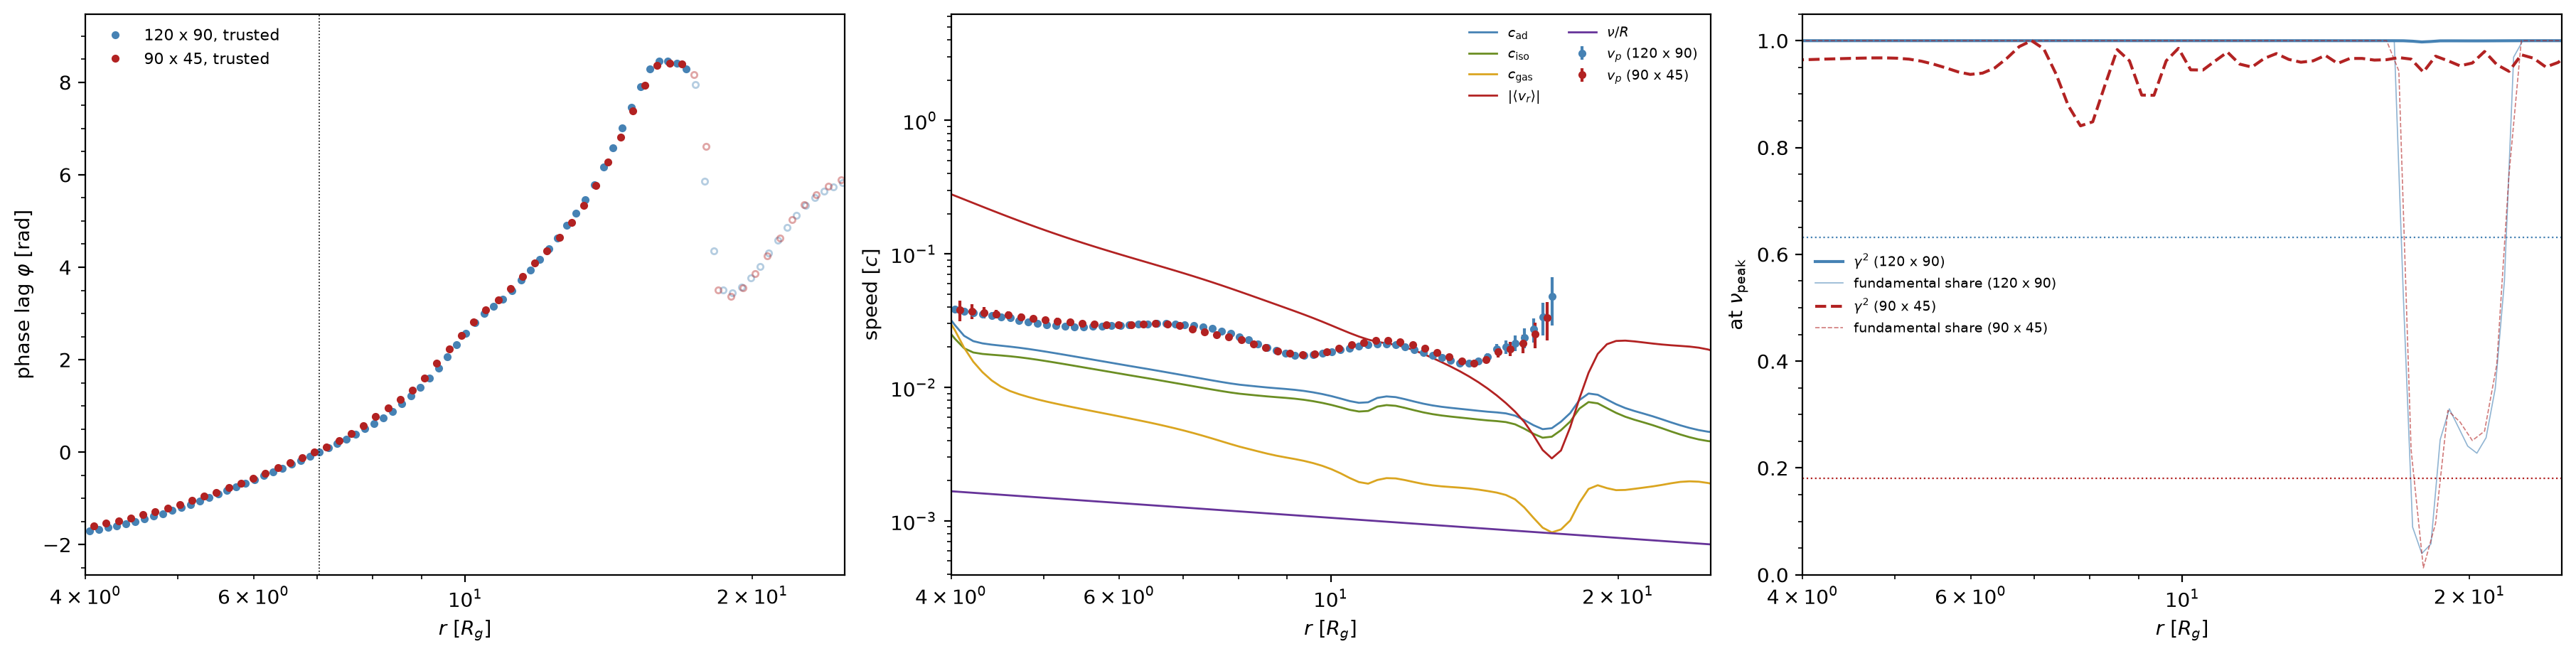

120 x 90: 7 segments (4 independent), gamma^2_crit = 0.63,  trusted r in [4.0, 17.1],  mean phase speed for r in [7, 15] = 0.0190 +- 0.0002 c
90 x 45: 31 segments (16 independent), gamma^2_crit = 0.18,  trusted r in [4.1, 16.9],  mean phase speed for r in [7, 15] = 0.0195 +- 0.0002 c
120 x 90: median ratios over the trusted region  v_p / c_ad = 2.22,  v_p / c_iso = 2.58,  v_p / c_gas = 6.44


In [26]:
def contiguous(good, i0):
    out = np.zeros_like(good)
    if not good[i0]:
        return out
    i = i0
    while i < good.size and good[i]:
        out[i] = True; i += 1
    i = i0 - 1
    while i >= 0 and good[i]:
        out[i] = True; i -= 1
    return out

def phase_profile(run):
    d, r, dt, f0 = run['delta'], run['r'], run['dt_s'], run['f_peak']
    nper, nseg, nind = welch_len(d.shape[0], dt)
    kw = dict(fs=1.0 / dt, window='hann', nperseg=nper, noverlap=nper // 2, detrend='linear', axis=0)
    i0 = int(np.argmin(np.abs(r - R_PHASE_REF)))
    f, P0r = signal.csd(d[:, [i0]], d, **kw)
    _, g2 = signal.coherence(d[:, [i0]], d, **kw)
    _, Prr = signal.welch(d, **kw)
    k = int(np.argmin(np.abs(f - f0)))
    lag = -np.angle(P0r[k])
    ph = np.empty_like(lag)
    ph[i0:] = np.unwrap(lag[i0:])
    ph[:i0 + 1] = np.unwrap(lag[:i0 + 1][::-1])[::-1]
    g2k = np.clip(g2[k], 1e-9, 1.0)
    sig = np.sqrt((1.0 - g2k) / (2.0 * nind * g2k))
    share = Prr[k] / Prr[1:].max(axis=0)
    g2_crit = 1.0 - 0.05**(1.0 / (nind - 1)) if nind > 1 else 1.0
    good = (g2k >= g2_crit) & (share >= P_FUND_MIN) & (r >= R_WAVE[0]) & (r <= R_WAVE[1])
    return dict(ph=ph - ph[i0], sig=sig, g2=g2k, share=share, g2_crit=g2_crit, valid=contiguous(good, i0), f=f[k],
                nseg=nseg, nind=nind, i0=i0)

def line_fit(x, y, s):
    # slope of a straight line and the larger of its weighted and residual errors
    xm = x - x.mean()
    slope = np.sum(xm * y) / np.sum(xm**2)
    resid = y - y.mean() - slope * xm
    se_res = np.sqrt(np.sum(resid**2) / max(x.size - 2, 1) / np.sum(xm**2))
    se_w = np.sqrt(1.0 / np.sum(xm**2 / np.maximum(s, 1e-6)**2))
    return slope, max(se_res, se_w)

def phase_speed(r, Ph, rmin=None, rmax=None):
    # local phase speeds, or one mean speed over [rmin, rmax]
    om = 2.0 * np.pi * Ph['f']
    if rmin is not None:
        m = Ph['valid'] & (r >= rmin) & (r <= rmax)
        if m.sum() < 4:
            return np.nan, np.nan
        b, eb = line_fit(r[m], Ph['ph'][m], Ph['sig'][m])
        return om / b, om / b * eb / abs(b)
    v, ev = np.full(r.size, np.nan), np.full(r.size, np.nan)
    for i in np.nonzero(Ph['valid'])[0]:
        m = Ph['valid'] & (np.abs(np.log(r / r[i])) <= np.log1p(FIT_FRAC))
        if m.sum() >= 4:
            b, eb = line_fit(r[m], Ph['ph'][m], Ph['sig'][m])
            v[i], ev[i] = om / b, abs(om / b) * eb / abs(b)
    return v, ev

for run in RUNS:
    run['Ph'] = phase_profile(run)
    run['v_p'], run['v_p_err'] = phase_speed(run['r'], run['Ph'])
    run['v_mean'], run['v_mean_err'] = phase_speed(run['r'], run['Ph'], R_PHASE_REF, 15.0)

S = RUN['S']
rho_m = S['rho_mid'].mean(axis=0)
prs_m = S['prs_mid'].mean(axis=0)
pr_m = S['enr_mid'].mean(axis=0) / 3.0
c_ad = np.sqrt((GAMMA * prs_m + 4.0 / 3.0 * pr_m) / rho_m)
c_iso = np.sqrt((prs_m + pr_m) / rho_m)
c_gas = np.sqrt(GAMMA * prs_m / rho_m)
vr_m = S['vr_mid'].mean(axis=0)

fig, axs = plt.subplots(1, 3, figsize=[18, 4.5])
for run in RUNS:
    r, Ph = run['r'], run['Ph']
    v = Ph['valid']
    axs[0].plot(r[v], Ph['ph'][v], 'o', ms=3, color=run['color'], label=f"{run['label']}, trusted")
    axs[0].plot(r[~v], Ph['ph'][~v], 'o', ms=3, mfc='none', color=run['color'], alpha=0.4)
    axs[1].errorbar(r, run['v_p'], yerr=run['v_p_err'], fmt='o', ms=3, color=run['color'], ls='none', label=r'$v_p$' + f" ({run['label']})")
    axs[2].plot(r, Ph['g2'], color=run['color'], ls=run['ls'], label=r'$\gamma^2$' + f" ({run['label']})")
    axs[2].axhline(Ph['g2_crit'], color=run['color'], ls=':', lw=0.8)
    axs[2].plot(r, Ph['share'], color=run['color'], ls=run['ls'], lw=0.6, alpha=0.6, label=f"fundamental share ({run['label']})")
axs[0].axvline(R_C[RUN['Ph']['i0']], color='k', lw=0.6, ls=':')
axs[0].set_xscale('log'); axs[0].set_xlim(*R_WAVE)
axs[0].set_xlabel(r'$r\ [R_g]$'); axs[0].set_ylabel(r'phase lag $\varphi$ [rad]'); axs[0].legend(fontsize=8)
for y, lab in [(c_ad, r'$c_\mathrm{ad}$'), (c_iso, r'$c_\mathrm{iso}$'), (c_gas, r'$c_\mathrm{gas}$'), (np.abs(vr_m), r'$|\langle v_r\rangle|$'),
               (nu_kin(R_C) / R_C, r'$\nu/R$')]:
    axs[1].plot(R_C, y, lw=1, label=lab)
axs[1].set_xscale('log'); axs[1].set_yscale('log'); axs[1].set_xlim(*R_WAVE)
axs[1].set_xlabel(r'$r\ [R_g]$'); axs[1].set_ylabel(r'speed $[c]$'); axs[1].legend(fontsize=7, ncol=2)
axs[2].set_xscale('log'); axs[2].set_xlim(*R_WAVE); axs[2].set_ylim(0, 1.05)
axs[2].set_xlabel(r'$r\ [R_g]$'); axs[2].set_ylabel(r'at $\nu_\mathrm{peak}$'); axs[2].legend(fontsize=7)
plt.show()

for run in RUNS:
    Ph, r = run['Ph'], run['r']
    rv = r[Ph['valid']]
    print(f"{run['label']}: {Ph['nseg']} segments ({Ph['nind']} independent), gamma^2_crit = {Ph['g2_crit']:.2f},"
          f"  trusted r in [{rv.min():.1f}, {rv.max():.1f}],"
          f"  mean phase speed for r in [{R_PHASE_REF:g}, 15] = {run['v_mean']:.4f} +- {run['v_mean_err']:.4f} c")
m = RUN['Ph']['valid'] & np.isfinite(RUN['v_p'])
if m.any():
    print(f"{RUN['label']}: median ratios over the trusted region  v_p / c_ad = {np.median(RUN['v_p'][m] / c_ad[m]):.2f},"
          f"  v_p / c_iso = {np.median(RUN['v_p'][m] / c_iso[m]):.2f},  v_p / c_gas = {np.median(RUN['v_p'][m] / c_gas[m]):.2f}")

#### 4.4. Amplitude and Wave Character

The rms amplitude $\delta_\mathrm{rms}(r) = \langle\delta^2\rangle_t^{1/2}$ shows where the waves are launched and whether they grow
or decay on the way out.

The phase between the midplane density and radial velocity perturbations at $\nu_\mathrm{peak}$ characterizes the wave. For an
outward travelling sound wave $\delta v_r / c_s = \delta\rho / \rho$, so density and velocity are in phase, $\varphi = 0$. A standing
wave or an evanescent oscillation shows $\varphi \approx \pm\pi/2$. The same is done for the radiation energy density. An adiabatic
wave with radiation work would vary in phase with the density, $\delta E_r / E_r = \tfrac{4}{3}\,\delta\rho/\rho$; without the work
term $E_r$ responds only through the heating of the gas and diffusion, so a lag is expected. Only phases above the coherence
threshold of Section 4.3 are shown.

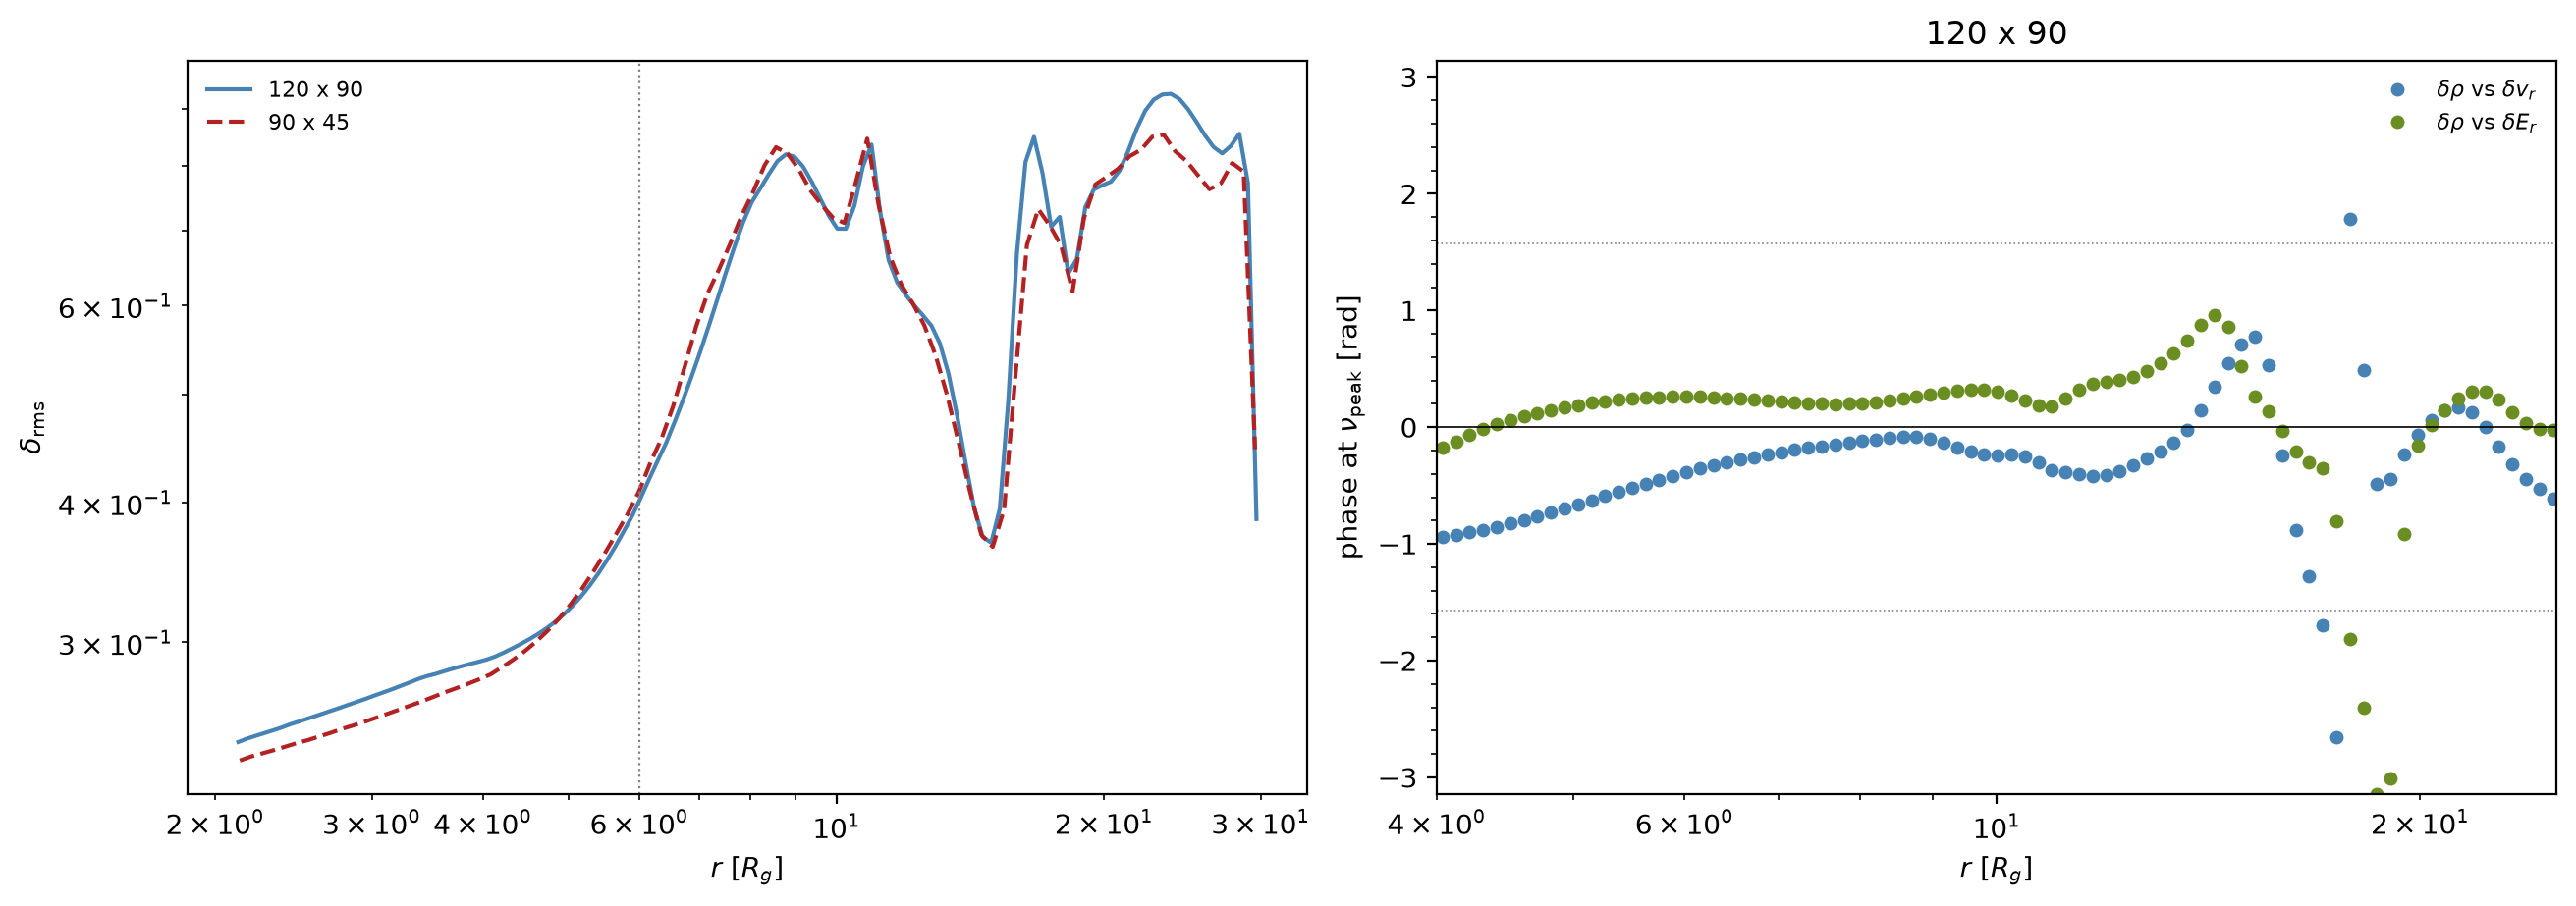

In [27]:
def cross_phase(a, b, dt, f0):
    nper, _, nind = welch_len(a.shape[0], dt)
    kw = dict(fs=1.0 / dt, window='hann', nperseg=nper, noverlap=nper // 2, detrend='linear', axis=0)
    f_c, P = signal.csd(a, b, **kw)
    _, g2 = signal.coherence(a, b, **kw)
    k = int(np.argmin(np.abs(f_c - f0)))
    return np.angle(P[k]), g2[k]

for run in RUNS:
    run['d_rms'] = np.sqrt(np.mean(run['delta']**2, axis=0))

drho = S['rho_mid'] / rho_m[None, :] - 1.0
dvr = S['vr_mid'] - vr_m[None, :]
dE = S['enr_mid'] / (3.0 * pr_m[None, :]) - 1.0
ph_v, g_v = cross_phase(drho, dvr, RUN['dt_s'], F_PEAK)
ph_E, g_E = cross_phase(drho, dE, RUN['dt_s'], F_PEAK)

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
for run in RUNS:
    axs[0].plot(run['r'], run['d_rms'], color=run['color'], ls=run['ls'], label=run['label'])
axs[0].axvline(6.0, color='gray', lw=0.8, ls=':')
axs[0].set_xscale('log'); axs[0].set_yscale('log')
axs[0].set_xlabel(r'$r\ [R_g]$'); axs[0].set_ylabel(r'$\delta_\mathrm{rms}$'); axs[0].legend(fontsize=8)

for ph, g2, lab in [(ph_v, g_v, r'$\delta\rho$ vs $\delta v_r$'), (ph_E, g_E, r'$\delta\rho$ vs $\delta E_r$')]:
    m = g2 >= RUN['Ph']['g2_crit']
    axs[1].plot(R_C[m], ph[m], 'o', ms=4, label=lab)
axs[1].axhline(0, color='k', lw=0.6)
for y in [-np.pi / 2, np.pi / 2]:
    axs[1].axhline(y, color='gray', lw=0.6, ls=':')
axs[1].set_xscale('log'); axs[1].set_ylim(-np.pi, np.pi); axs[1].set_xlim(*R_WAVE)
axs[1].set_xlabel(r'$r\ [R_g]$'); axs[1].set_ylabel(r'phase at $\nu_\mathrm{peak}$ [rad]'); axs[1].legend(fontsize=8)
axs[1].set_title(RUN['label'])
plt.show()

### 5. Steady State Structure

#### 5.1. Luminosity and Radiative Efficiency

The radiative luminosity through a sphere of radius $r$, with the flux in code units, $L(r) = 2\,r^2\sum_j F_{r,j}\,\Delta\Omega_j$,
is evaluated at the outer boundary and at $r = 20$. The radiative efficiency compares the mean luminosity with the mean rest mass
accretion rate through the inner boundary,

$$
\eta_\mathrm{rad} = \frac{\langle L\rangle}{\langle\dot M_\mathrm{acc}(r_\mathrm{in})\rangle\, c^2},
$$

to be compared with $\eta = 1/16$ for a disk radiating its full binding energy down to $R_\mathrm{isco}$. Radiation that is advected
into the hole or still stored in the disk lowers $\eta_\mathrm{rad}$. Its error combines the relative standard errors of $L$ and
$\dot M_\mathrm{acc}$.

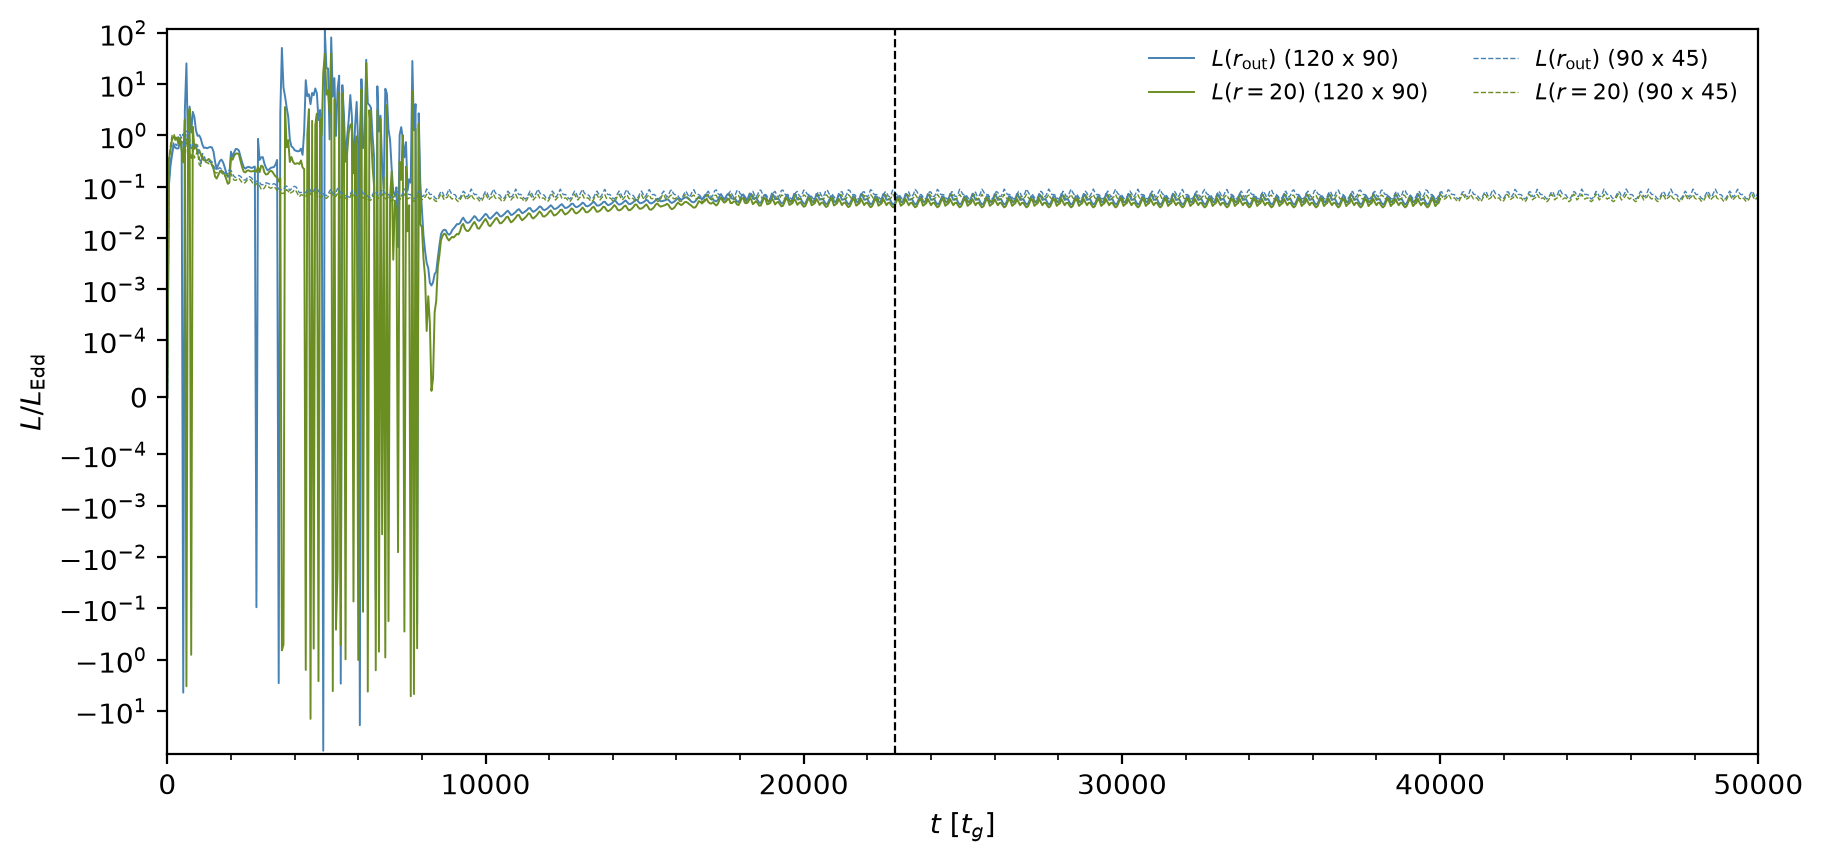

120 x 90:  <L(r_out)> = 8.259e+44 +- 3.2e+42 erg/s = 0.0562 L_Edd,   <L(r=20)> = 0.0475 L_Edd,   eta_rad = 0.0475 +- 0.0003   (eta_isco = 0.0625)
90 x 45:  <L(r_out)> = 1.034e+45 +- 2.6e+42 erg/s = 0.0703 L_Edd,   <L(r=20)> = 0.0601 L_Edd,   eta_rad = 0.0486 +- 0.0002   (eta_isco = 0.0625)


In [28]:
for run in RUNS:
    Cx, s, dt = run['C'], run['sel'], run['dt']
    run['L_out_mean'], run['L_out_se'] = mean_se(Cx['L_out'][s], dt)
    run['L_20_mean'], _ = mean_se(Cx['L_20'][s], dt)
    run['M_d_mean'], run['M_d_se'] = mean_se(Cx['M_d'][s], dt)
    m, em = run['mdot_in_mean'], run['mdot_in_se']
    run['eta'] = run['L_out_mean'] / m if m > 0 else np.nan
    run['eta_se'] = run['eta'] * np.sqrt((run['L_out_se'] / run['L_out_mean'])**2 + (em / m)**2) if m > 0 else np.nan

fig, ax = plt.subplots(figsize=[9, 4.2])
for run in RUNS:
    lw = 0.7 if run is RUN else 0.5
    ax.plot(run['t'], run['C']['L_out'] * L0 / L_EDD, color='C0', ls=run['ls'], lw=lw, label=r'$L(r_\mathrm{out})$' + f" ({run['label']})")
    ax.plot(run['t'], run['C']['L_20'] * L0 / L_EDD, color='C1', ls=run['ls'], lw=lw, label=r'$L(r = 20)$' + f" ({run['label']})")
ax.axvline(T_STEADY, color='k', ls='--', lw=0.8)
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_xlim(0, max(run['t'][-1] for run in RUNS))
ax.set_xlabel(r'$t\ [t_g]$'); ax.set_ylabel(r'$L / L_\mathrm{Edd}$'); ax.legend(fontsize=8, ncol=2)
plt.show()

for run in RUNS:
    print(f"{run['label']}:  <L(r_out)> = {run['L_out_mean'] * L0:.3e} +- {run['L_out_se'] * L0:.1e} erg/s"
          f" = {run['L_out_mean'] * L0 / L_EDD:.4f} L_Edd,   <L(r=20)> = {run['L_20_mean'] * L0 / L_EDD:.4f} L_Edd,"
          f"   eta_rad = {run['eta']:.4f} +- {run['eta_se']:.4f}   (eta_isco = {ETA:.4f})")

#### 5.2. Time Averaged Fields Over the Steady Window

A second pass reloads every `PROFILE_STRIDE`-th frame of the steady window of the long series and accumulates time averages of the
2D fields, of vertical profiles at fixed cylindrical radii, and of the column heating and cooling rates. This needs the `.dbl` files
and is done for the main run only.

**Vertical force balance.** The radiation force per unit mass $\kappa F$, with $\kappa = \kappa_a + \kappa_s$ in code units, is
compared with the vertical component of gravity in the Paczyński–Wiita potential,

$$
F_z = F_r\cos\theta - F_\theta\sin\theta, \qquad g_z = \frac{\cos\theta}{(r - 2)^2}, \qquad \Gamma_z = \frac{\kappa\,F_z}{g_z},
$$

so $\Gamma_z = 1$ marks local vertical radiative support, $\Gamma_z > 1$ net upward and $\Gamma_z < 1$ net downward acceleration
when gas pressure is negligible. Profiles at fixed $R$ are interpolated linearly in $\log r$ along each ray $\theta_j$, at
$r = R/\sin\theta_j$.

**Thermal balance.** Per unit area of one disk face, the viscous heating integrated over the column and the radiative cooling through
the photosphere are

$$
Q^+(r) = \sum_j \nu_1\left(r\,\frac{\partial\Omega}{\partial r}\right)^2 r\,\Delta\theta_j, \qquad \Omega = \frac{v_\phi}{r\sin\theta}, \qquad
Q^-(r) = F_z\big|_{\tau = 1},
$$

where $r\,\partial/\partial r$ at fixed $\theta$ equals $R\,\partial/\partial R$. In thermal equilibrium $Q^+ = Q^-$. Since Thomson
scattering acts in the corona as well, the photosphere can lie above the disk surface where the corona is optically thick, and $Q^-$
is then the flux leaving the corona. $Q^+$ contains only the explicit viscosity; if $\alpha_\mathrm{eff} > \alpha$ (Section 3.3), the
additional transport dissipates energy too, e.g. in the shocks of the waves, which $Q^+$ misses. The radiative diffusion time
through the disk is estimated from the mean surface density and aspect ratio,

$$
t_\mathrm{diff} = \frac{\tau_\mathrm{mid}\, H}{c}, \qquad \tau_\mathrm{mid} = \frac{\kappa_\mathrm{es}\,\langle\Sigma\rangle}{2}, \qquad H = \left\langle\frac{H}{R}\right\rangle R .
$$

In [29]:
def vertical_profile(field, R0):
    # field (NR, NTH) along the vertical line at cylindrical radius R0, as a function of z/R = cot(theta)
    r_line = R0 / np.sin(TH_C)
    inside = (r_line >= R_C[0]) & (r_line <= R_C[-1])
    out = np.full(NTH, np.nan)
    lr = np.log(R_C)
    for j in np.nonzero(inside)[0]:
        out[j] = np.interp(np.log(r_line[j]), lr, field[:, j])
    return out

def structure_fields(F):
    Tg, Tr = gas_temperature(F), rad_temperature(F)
    st, ct = np.sin(TH_C)[None, :], np.cos(TH_C)[None, :]
    Fz = F['fr1'] * ct - F['fr2'] * st
    gz = ct / (R_C[:, None] - 2.0)**2
    kap = F['kappa_abs'] + F['kappa_scat']
    gamma_z = np.where(gz > 0, kap * Fz / np.maximum(gz, 1e-300), np.nan)
    vz = F['vx1'] * ct - F['vx2'] * st
    return dict(rho=F['rho'], p_gas=F['prs'], p_rad=F['enr'] / 3.0, T_g=Tg, T_r=Tr, Gamma_z=gamma_z, f=F['diskfrac'], v_z=vz), Fz

def thermal_balance(F, Fz):
    Om = F['vx3'] / (R_C[:, None] * np.sin(TH_C)[None, :])
    shear = R_C[:, None] * np.gradient(Om, R_C, axis=0)
    q_plus = np.sum(F['nu'] * shear**2 * R_C[:, None] * DTH[None, :], axis=1)
    tau = optical_depth_from_pole(F)
    q_minus = np.full(NR, np.nan)
    for i in range(NR):
        j = np.argmax(tau[i] >= 1.0)
        if tau[i, j] >= 1.0:
            q_minus[i] = Fz[i, j]
    return q_plus, q_minus

steady_outs = C['outs'][SEL][::PROFILE_STRIDE]
MEAN2D = {k: np.zeros((NR, NTH)) for k in ['rho', 'T_g', 'T_r', 'f', 'tau']}
PROF = {R0: {} for R0 in R_PROFILES}
QP, QM, NQM = np.zeros(NR), np.zeros(NR), np.zeros(NR)
n_used = 0
for n in steady_outs:
    F = load(n)
    S2, Fz = structure_fields(F)
    MEAN2D['rho'] += F['rho']; MEAN2D['T_g'] += S2['T_g']; MEAN2D['T_r'] += S2['T_r']
    MEAN2D['f'] += F['diskfrac']; MEAN2D['tau'] += optical_depth_from_pole(F)
    for R0 in R_PROFILES:
        for key, field in S2.items():
            PROF[R0][key] = PROF[R0].get(key, 0.0) + vertical_profile(field, R0)
    qp, qm = thermal_balance(F, Fz)
    QP += qp
    good_q = np.isfinite(qm)
    QM[good_q] += qm[good_q]; NQM[good_q] += 1
    n_used += 1
for key in MEAN2D:
    MEAN2D[key] /= n_used
for R0 in R_PROFILES:
    for key in PROF[R0]:
        PROF[R0][key] = PROF[R0][key] / n_used
QP /= n_used
QM = np.where(NQM > 0, QM / np.maximum(NQM, 1), np.nan)
print(f"averaged {n_used} frames between t = {TS[0]:.0f} and {TS[-1]:.0f}")

averaged 86 frames between t = 22900 and 40000


#### 5.3. Mean State

Time averaged density, gas temperature and $T_g/T_r$ over the steady window, with the mean disk surface $\langle f\rangle = 0.5$ in
white and the mean photosphere $\langle\tau\rangle = 1$ in dashed cyan.

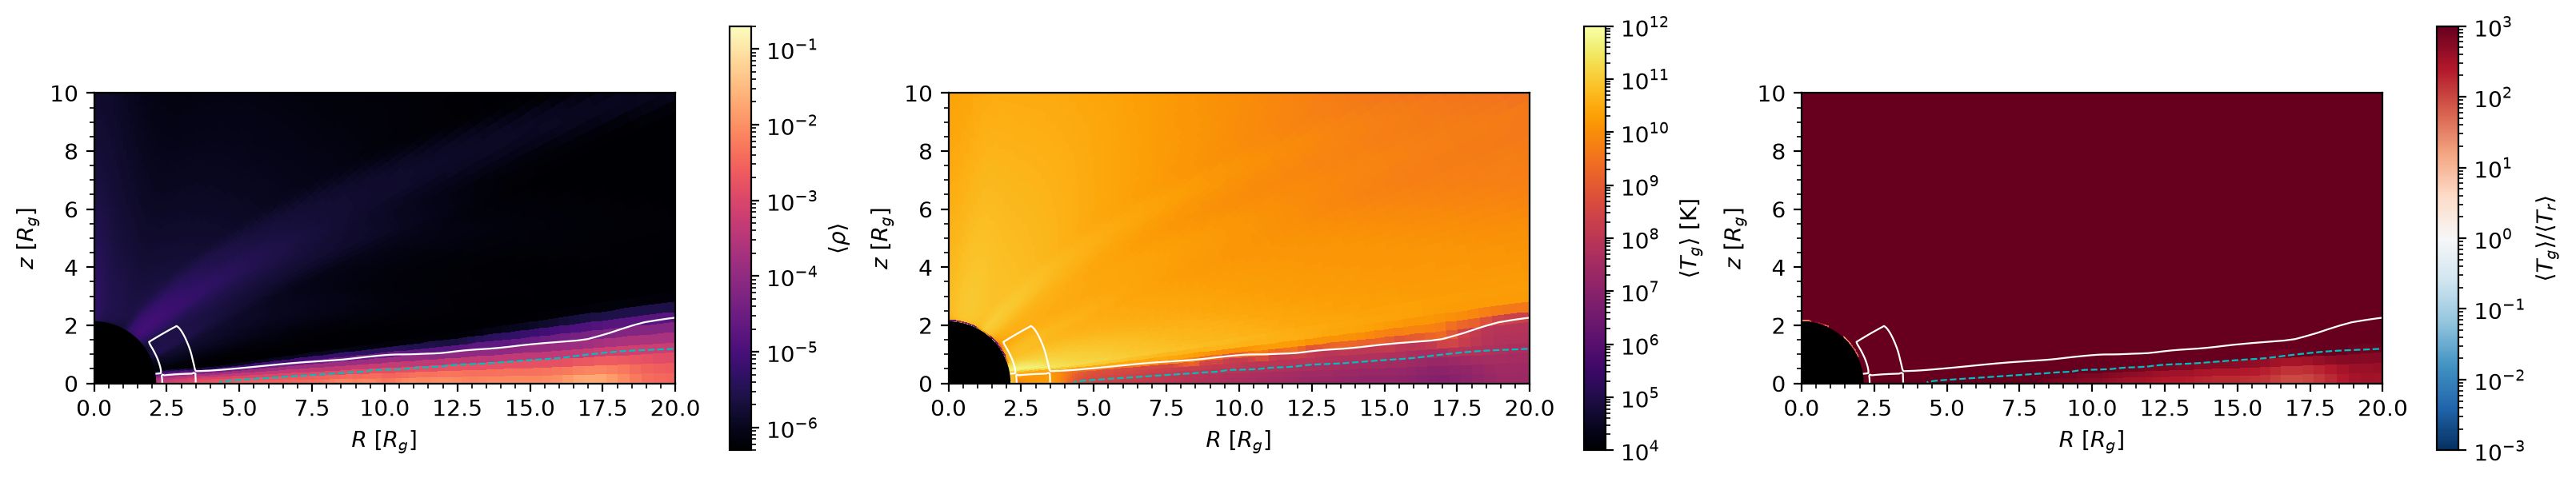

In [30]:
mean_F = dict(diskfrac=MEAN2D['f'], rho=MEAN2D['rho'], kappa_abs=np.zeros((NR, NTH)), kappa_scat=np.zeros((NR, NTH)))
Xc, Zc = centers_mesh()
fig, axs = plt.subplots(1, 3, figsize=[16, 3.4])
panels = [(MEAN2D['rho'], SNAP_NORM, 'magma', r'$\langle\rho\rangle$'),
          (MEAN2D['T_g'], LogNorm(vmin=1e4, vmax=1e12), 'inferno', r'$\langle T_g\rangle$ [K]'),
          (MEAN2D['T_g'] / np.maximum(MEAN2D['T_r'], 1.0), LogNorm(vmin=1e-3, vmax=1e3), 'RdBu_r', r'$\langle T_g\rangle / \langle T_r\rangle$')]
for ax, (data, norm, cmap, lab) in zip(axs, panels):
    im = draw_map(ax, mean_F, data, norm, cmap=cmap, contours=False)
    ax.contour(Xc, Zc, MEAN2D['f'], levels=[0.5], colors='w', linewidths=0.8)
    ax.contour(Xc, Zc, MEAN2D['tau'], levels=[1.0], colors='c', linewidths=0.8, linestyles='--')
    plt.colorbar(im, ax=ax, label=lab, shrink=0.8)
plt.show()

#### 5.4. Vertical Structure

Mean vertical profiles at the radii `R_PROFILES` against $z/R$: density, gas and radiation pressure, gas and radiation temperature,
the radiative support $\Gamma_z$ and the vertical velocity $v_z$. The dotted line marks the mean disk surface $\langle f\rangle = 0.5$.

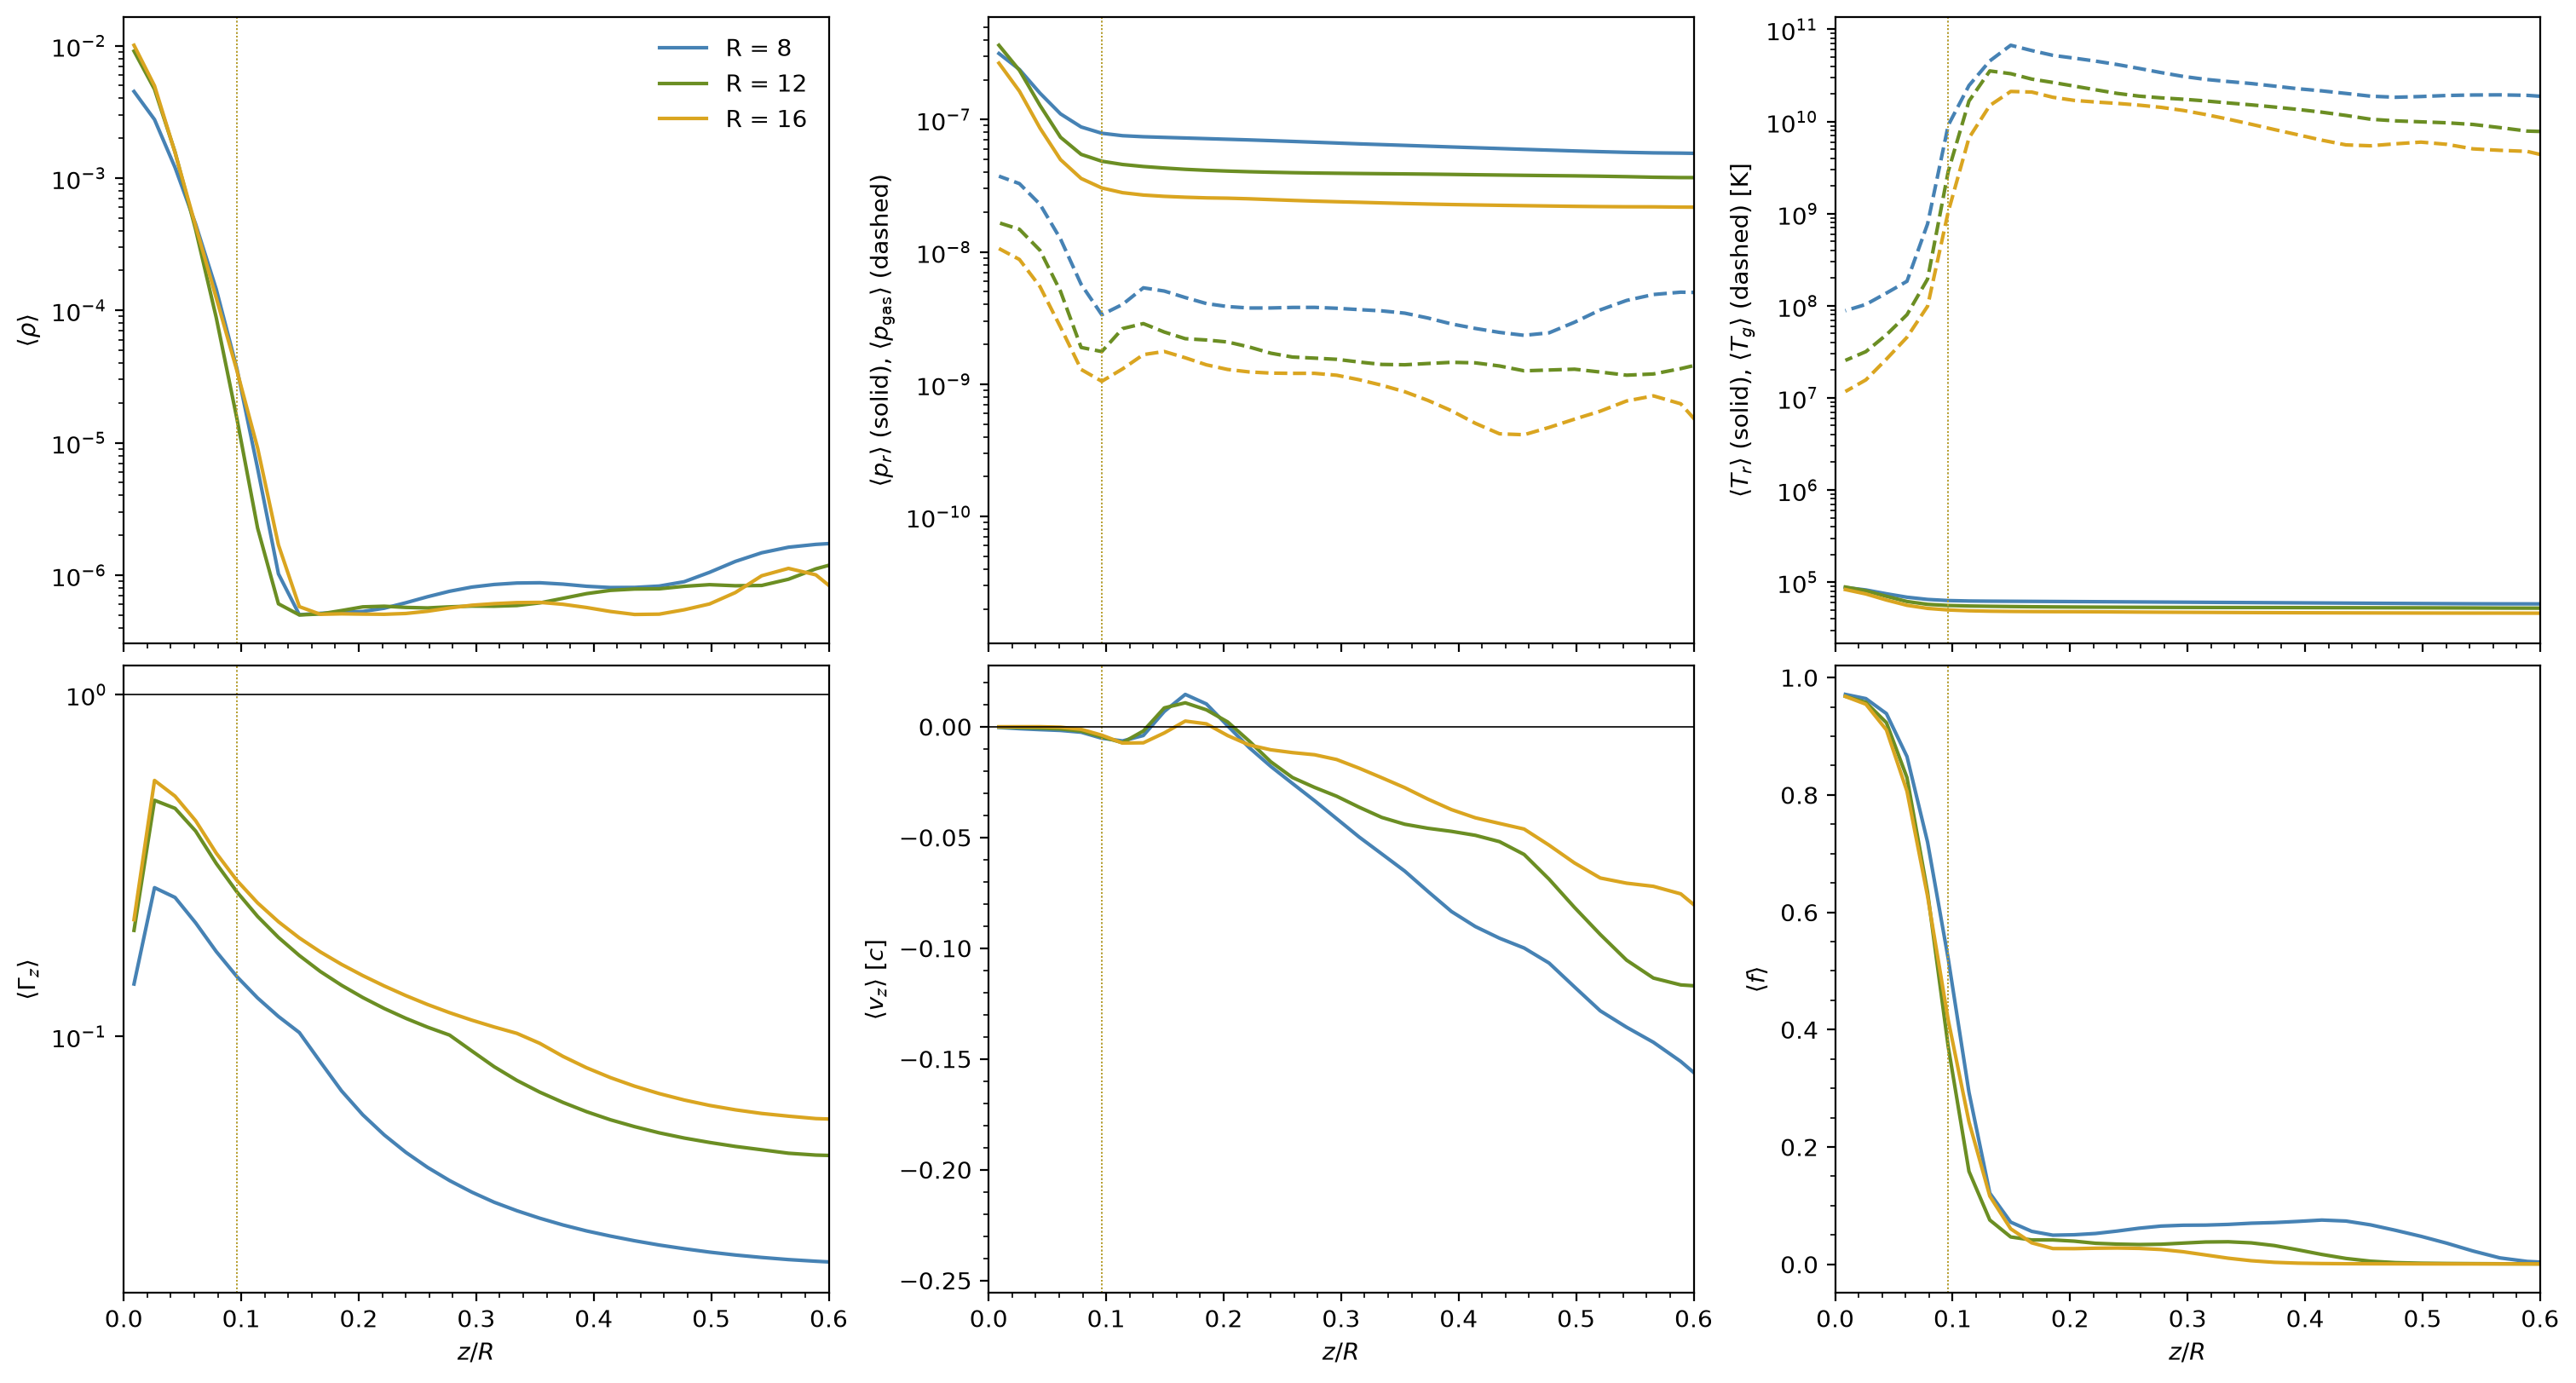

In [31]:
zr = COT
fig, axs = plt.subplots(2, 3, figsize=[15, 8], sharex=True)
for R0 in R_PROFILES:
    P = PROF[R0]
    line, = axs[0, 0].semilogy(zr, P['rho'], label=f"R = {R0:g}")
    c = line.get_color()
    axs[0, 1].semilogy(zr, P['p_rad'], color=c)
    axs[0, 1].semilogy(zr, P['p_gas'], color=c, ls='--')
    axs[0, 2].semilogy(zr, P['T_r'], color=c)
    axs[0, 2].semilogy(zr, P['T_g'], color=c, ls='--')
    axs[1, 0].plot(zr, P['Gamma_z'], color=c)
    axs[1, 1].plot(zr, P['v_z'], color=c)
    axs[1, 2].plot(zr, P['f'], color=c)
    surface = zr[np.nanargmin(np.abs(P['f'] - 0.5))]
    for ax in axs.flat:
        ax.axvline(surface, color=c, lw=0.6, ls=':')
axs[0, 0].set_ylabel(r'$\langle\rho\rangle$'); axs[0, 0].legend()
axs[0, 1].set_ylabel(r'$\langle p_r\rangle$ (solid), $\langle p_\mathrm{gas}\rangle$ (dashed)')
axs[0, 2].set_ylabel(r'$\langle T_r\rangle$ (solid), $\langle T_g\rangle$ (dashed) [K]')
axs[1, 0].set_ylabel(r'$\langle\Gamma_z\rangle$'); axs[1, 0].axhline(1, color='k', lw=0.6)
axs[1, 0].set_yscale('symlog', linthresh=1e-1)
axs[1, 1].set_ylabel(r'$\langle v_z\rangle\ [c]$'); axs[1, 1].axhline(0, color='k', lw=0.6)
axs[1, 2].set_ylabel(r'$\langle f\rangle$')
for ax in axs[1]:
    ax.set_xlabel(r'$z/R$')
axs[0, 0].set_xlim(0, 0.6)
plt.show()

#### 5.5. Thermal Balance, Aspect Ratio, Resolution and Diffusion Time

The vertical resolution of the disk is the number of polar cells per scale height at the midplane, $(H/R)/\Delta\theta_\mathrm{mid}$.
Below a few cells per scale height the vertical structure, and with it the radiative diffusion out of the disk, is not resolved.

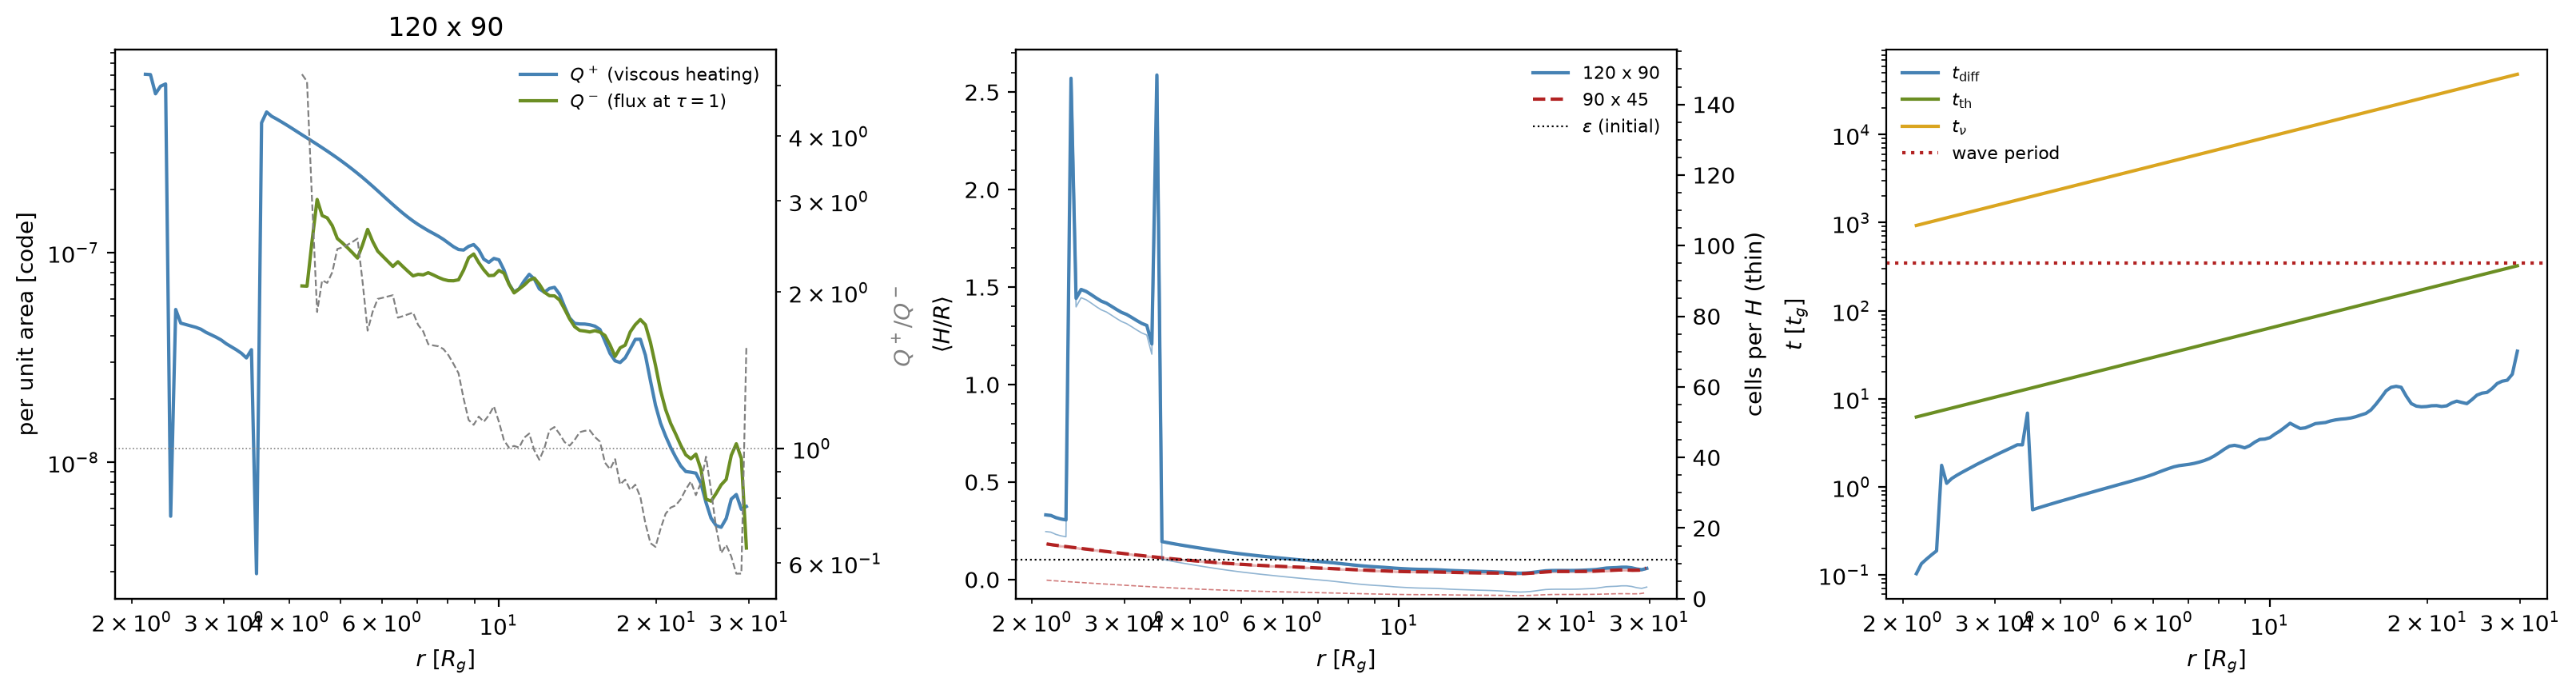

R =  8.0:  120 x 90: H/R = 0.078, 4.5 cells per H,   90 x 45: H/R = 0.052, 1.5 cells per H
R = 12.0:  120 x 90: H/R = 0.050, 2.8 cells per H,   90 x 45: H/R = 0.038, 1.1 cells per H
R = 20.0:  120 x 90: H/R = 0.047, 2.7 cells per H,   90 x 45: H/R = 0.041, 1.2 cells per H


In [32]:
for run in RUNS:
    run['hr_mean'], run['hr_se'] = mean_se(run['C']['hr'][run['sel']], run['dt'])
    run['cells_H'] = run['hr_mean'] / run['dth_mid']
tau_mid = KAPPA_ES * RHO0 * R_G * RUN['sig_mean'] / 2.0
t_diff = tau_mid * RUN['hr_mean'] * R_C

fig, axs = plt.subplots(1, 3, figsize=[16, 4.2])
ax = axs[0]
ax.loglog(R_C, QP, label=r'$Q^+$ (viscous heating)')
ax.loglog(R_C, np.where(QM > 0, QM, np.nan), label=r'$Q^-$ (flux at $\tau = 1$)')
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel('per unit area [code]'); ax.legend(fontsize=8)
ax.set_title(RUN['label'])
ax2 = ax.twinx()
ax2.semilogx(R_C, QP / QM, color='gray', lw=0.8, ls='--')
ax2.axhline(1, color='gray', lw=0.6, ls=':'); ax2.set_ylabel(r'$Q^+/Q^-$', color='gray')
ax2.set_yscale('log')

ax = axs[1]
for run in RUNS:
    ax.plot(run['r'], run['hr_mean'], color=run['color'], ls=run['ls'], label=run['label'])
    ax.fill_between(run['r'], run['hr_mean'] - run['hr_se'], run['hr_mean'] + run['hr_se'], color=run['color'], alpha=0.3)
ax.axhline(EPS, color='k', ls=':', lw=0.8, label=r'$\epsilon$ (initial)')
ax.set_xscale('log'); ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\langle H/R\rangle$'); ax.legend(fontsize=8)
axr = ax.twinx()
for run in RUNS:
    axr.plot(run['r'], run['cells_H'], color=run['color'], ls=run['ls'], lw=0.6, alpha=0.6)
axr.set_ylabel(r'cells per $H$ (thin)')
axr.set_ylim(0, None)

ax = axs[2]
ax.loglog(R_C, t_diff, label=r'$t_\mathrm{diff}$')
ax.loglog(R_C, t_thermal(R_C), label=r'$t_\mathrm{th}$')
ax.loglog(R_C, t_viscous(R_C), label=r'$t_\nu$')
ax.axhline(1 / F_PEAK, color='firebrick', ls=':', label='wave period')
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$t\ [t_g]$'); ax.legend(fontsize=8)
plt.show()

for R0 in [8.0, 12.0, 20.0]:
    print(f"R = {R0:4.1f}:  " + ',   '.join(f"{run['label']}: H/R = {np.interp(R0, run['r'], run['hr_mean']):.3f},"
                                          f" {np.interp(R0, run['r'], run['cells_H']):.1f} cells per H" for run in RUNS))

### 6. Comparison With the Reference Run

The main results of both runs side by side, each with its standard error, and the normalized difference

$$
z = \frac{X_\mathrm{main} - X_\mathrm{ref}}{\sqrt{\mathrm{SE}_\mathrm{main}^2 + \mathrm{SE}_\mathrm{ref}^2}} ,
$$

so $|z| < 2$ counts as consistent. Each run uses its own steady window and spectral series. With only two resolutions, consistency
means that the quantity is insensitive to the resolution step taken, not that it is converged; a systematic difference that is
small compared with the value itself can still be significant when the errors are small. Quantities without a statistical error
are listed without $z$.

In [33]:
def at(run, key, R0):
    return np.interp(R0, run['r'], run[key])

def comparison_rows(run):
    return [
        ("start of the steady window [t_g]", run['t_steady'], np.nan),
        ("<Mdot_acc(r_in)> [Mdot_Edd]", run['mdot_in_mean'] * scale, run['mdot_in_se'] * scale),
        ("<L(r_out)> [L_Edd]", run['L_out_mean'] * L0 / L_EDD, run['L_out_se'] * L0 / L_EDD),
        ("eta_rad", run['eta'], run['eta_se']),
        ("<M_d> [code]", run['M_d_mean'], run['M_d_se']),
        ("dominant frequency [1e-3 / t_g]", run['f_peak'] * 1e3, 0.5 * run['df_peak'] * 1e3),
        (f"mean phase speed r = {R_PHASE_REF:g}-15 [c]", run['v_mean'], run['v_mean_err']),
        ("alpha_eff / alpha at R = 10", at(run, 'alpha_ratio', 10.0), at(run, 'alpha_ratio', 10.0) * at(run, 'alpha_ratio_rel', 10.0)),
        ("alpha_eff / alpha at R = 15", at(run, 'alpha_ratio', 15.0), at(run, 'alpha_ratio', 15.0) * at(run, 'alpha_ratio_rel', 15.0)),
        ("<H/R> at R = 10", at(run, 'hr_mean', 10.0), at(run, 'hr_se', 10.0)),
        ("cells per H at R = 10", at(run, 'cells_H', 10.0), np.nan),
        ("delta_rms at R = 10", at(run, 'd_rms', 10.0), np.nan),
        ("R_eq median [R_g]", run['R_eq_stats'][1], np.nan),
    ]

if REF is None:
    print("no reference run")
else:
    rows_main, rows_ref = comparison_rows(RUN), comparison_rows(REF)
    print(f"{'':42s}{RUN['label']:>24s}{REF['label']:>24s}{'z':>8s}")
    for (name, a, ea), (_, b, eb) in zip(rows_main, rows_ref):
        fa = f"{a:.4g}" + (f" +- {ea:.2g}" if np.isfinite(ea) else "")
        fb = f"{b:.4g}" + (f" +- {eb:.2g}" if np.isfinite(eb) else "")
        z = (a - b) / np.sqrt(ea**2 + eb**2) if np.isfinite(ea) and np.isfinite(eb) and (ea > 0 or eb > 0) else np.nan
        zs = f"{z:+8.1f}" if np.isfinite(z) else f"{'':8s}"
        print(f"{name:42s}{fa:>24s}{fb:>24s}{zs}")

                                                          120 x 90                 90 x 45       z
start of the steady window [t_g]                         2.288e+04                    9225        
<Mdot_acc(r_in)> [Mdot_Edd]                     0.07387 +- 0.00045       0.09049 +- 0.0003   -30.8
<L(r_out)> [L_Edd]                              0.05616 +- 0.00022      0.07031 +- 0.00018   -50.6
eta_rad                                         0.04752 +- 0.00034       0.04856 +- 0.0002    -2.6
<M_d> [code]                                        18.07 +- 0.008         22.26 +- 0.0062  -414.4
dominant frequency [1e-3 / t_g]                       2.862 +- 0.2            2.869 +- 0.2    -0.0
mean phase speed r = 7-15 [c]                   0.01904 +- 0.00022      0.01953 +- 0.00023    -1.5
alpha_eff / alpha at R = 10                         2.681 +- 0.038          2.525 +- 0.024    +3.5
alpha_eff / alpha at R = 15                         2.056 +- 0.021          2.031 +- 0.013    +1.0
<H/R> at R

### 7. Summary

In [34]:
def summary_rows(run):
    period = 1.0 / run['f_peak']
    lo, med, hi = run['R_eq_stats']
    return [
        ("start of the steady window", f"{run['t_steady']:.0f} t_g = {run['t_steady'] * T_G / DAY:.1f} days"),
        ("inflow equilibrium radius", f"{med:.1f} R_g ({lo:.1f} - {hi:.1f}),  viscous estimate {r_viscous(run['t'][-1]):.1f} R_g"),
        ("mean accretion rate through r_in", f"{run['mdot_in_mean'] * MDOT0 * YEAR / CONST_Msun:.3f} Msun/yr = {run['mdot_in_mean'] * scale:.4f} Mdot_Edd"),
        ("mean luminosity through r_out", f"{run['L_out_mean'] * L0:.3e} erg/s = {run['L_out_mean'] * L0 / L_EDD:.4f} L_Edd"),
        ("radiative efficiency", f"{run['eta']:.4f} +- {run['eta_se']:.4f}   (eta_isco = {ETA:.4f})"),
        ("effective viscosity at R = 10", f"alpha_eff / alpha = {at(run, 'alpha_ratio', 10.0):.2f}"),
        ("dominant wave period", f"{period:.0f} t_g = {period * T_G / DAY:.2f} days"),
        ("mean phase speed", f"{run['v_mean']:.4f} +- {run['v_mean_err']:.4f} c  (r = {R_PHASE_REF:g}-15)"),
        ("cells per scale height at R = 10", f"{at(run, 'cells_H', 10.0):.1f}"),
    ]

for run in RUNS:
    rows = summary_rows(run)
    if run is RUN:
        rows.append(("floor residual of the mass budget", f"{FLOOR_FRAC:+.2%} of the mass accreted (z = {FLOOR_Z:+.1f}),"
                                                         f" control volume r = {R_C[IA]:.2f}-{R_C[IB]:.2f}"))
    width = max(len(k) for k, _ in rows)
    print(run['label'])
    for k, v in rows:
        print(f"   {k:<{width}}  {v}")

120 x 90
   start of the steady window         22875 t_g = 130.4 days
   inflow equilibrium radius          17.8 R_g (16.7 - 20.4),  viscous estimate 26.1 R_g
   mean accretion rate through r_in   0.307 Msun/yr = 0.0739 Mdot_Edd
   mean luminosity through r_out      8.259e+44 erg/s = 0.0562 L_Edd
   radiative efficiency               0.0475 +- 0.0003   (eta_isco = 0.0625)
   effective viscosity at R = 10      alpha_eff / alpha = 2.68
   dominant wave period               349 t_g = 1.99 days
   mean phase speed                   0.0190 +- 0.0002 c  (r = 7-15)
   cells per scale height at R = 10   3.3
   floor residual of the mass budget  -3.41% of the mass accreted (z = -53.7), control volume r = 2.48-24.85
90 x 45
   start of the steady window        9225 t_g = 52.6 days
   inflow equilibrium radius         17.9 R_g (16.4 - 21.4),  viscous estimate 30.3 R_g
   mean accretion rate through r_in  0.376 Msun/yr = 0.0905 Mdot_Edd
   mean luminosity through r_out     1.034e+45 erg/s = 0.0703